In [1]:
# # =============================================================================
# # 9.2b 热力图：各季观众投票份额与淘汰结果（精美版 - 支持多淘汰周 + Top-3标记）
# # 【使用保存的 q1_model_results.csv 数据】
# # =============================================================================

# print("\n" + "=" * 70)
# print("热力图：各季观众投票份额 pV vs 实际/预测淘汰（按 placement 排序 + Top-3 标记）")
# import pandas as pd
# print("=" * 70)

# def get_rule_type_display(season):
#     """根据季数判断规则类型（用于显示）"""
#     if season <= 2:
#         return "R1 (Rank)"
#     elif season <= 27:
#         return "R2 (Percent)"
#     else:
#         return "R3 (Bottom-2)"

# # 加载保存的模型结果数据
# df_result = pd.read_csv('../data/q1_model_results.csv')

# # 创建黄红紫色系的自定义 colormap
# from matplotlib.colors import LinearSegmentedColormap
# import matplotlib.patches as mpatches
# from matplotlib.lines import Line2D

# colors_yrp = [
#     '#2E0854',  # 深紫色 (最低 pV = 最高风险)
#     '#5B1A6A',  # 紫色
#     '#891A6A',  # 洋红紫
#     '#B91548',  # 玫红
#     '#DC3545',  # 红色
#     '#E85D04',  # 橙红
#     '#F8961E',  # 橙色
#     '#F9C74F',  # 金黄
#     '#FFEB3B',  # 柠檬黄 (最高 pV = 最低风险)
# ]
# cmap_yrp = LinearSegmentedColormap.from_list('YellowRedPurple', colors_yrp)

# if HAS_TORCH:
#     # 选择几个代表性季进行展示
#     heatmap_seasons = [2, 10, 14, 20, 27, 33]
#     heatmap_seasons = [s for s in heatmap_seasons if s in df_result['season'].unique()]
    
#     n_seasons = len(heatmap_seasons)
#     fig, axes = plt.subplots(2, 3, figsize=(22, 16))
#     axes = axes.flatten()
    
#     plt.rcParams['font.family'] = 'DejaVu Sans'
#     fig.patch.set_facecolor('#FAFAFA')
    
#     for ax, season in zip(axes[:n_seasons], heatmap_seasons):
#         season_df = df_result[df_result['season'] == season].copy()
        
#         # ========== 按真实 placement 排序（冠军在最上方）==========
#         # 获取每个选手的真实 placement
#         celeb_placement = season_df.groupby('celebrity_name')['placement'].min().reset_index()
#         celeb_placement.columns = ['celebrity_name', 'true_placement']
        
#         # 按 placement 升序排序（有 placement 的排在前面，NaN 排在后面）
#         celeb_placement = celeb_placement.sort_values(
#             'true_placement', 
#             ascending=True, 
#             na_position='last'
#         )
#         celebs = celeb_placement['celebrity_name'].tolist()
        
#         # 创建 celeb -> placement 映射
#         celeb_to_placement = dict(zip(celeb_placement['celebrity_name'], celeb_placement['true_placement']))
        
#         # 获取该季的预测 Top-3 映射
#         season_pred_top3 = {}
#         if 'pred_top3_pos' in season_df.columns:
#             pred_top3_df = season_df[season_df['pred_top3_pos'].notna()][['celebrity_name', 'pred_top3_pos']].drop_duplicates()
#             season_pred_top3 = dict(zip(pred_top3_df['celebrity_name'], pred_top3_df['pred_top3_pos'].astype(int)))
        
#         weeks = sorted(season_df['week'].unique())
        
#         # 构建矩阵
#         pV_matrix = np.full((len(celebs), len(weeks)), np.nan)
#         elim_actual_matrix = np.zeros((len(celebs), len(weeks)))  # 实际淘汰
#         elim_pred_matrix = np.zeros((len(celebs), len(weeks)))    # 预测淘汰
        
#         # 填充 pV 矩阵和实际淘汰矩阵
#         for i, celeb in enumerate(celebs):
#             celeb_data = season_df[season_df['celebrity_name'] == celeb]
#             for j, week in enumerate(weeks):
#                 week_data = celeb_data[celeb_data['week'] == week]
#                 if len(week_data) > 0:
#                     pV_matrix[i, j] = week_data['pV_hat'].values[0]
#                     if week_data['eliminated_end_of_week'].values[0]:
#                         elim_actual_matrix[i, j] = 1
        
#         # 根据每周实际淘汰人数来确定预测人数
#         for j, week in enumerate(weeks):
#             week_alive = season_df[season_df['week'] == week]
            
#             if len(week_alive) > 0 and 'elim_prob_hat' in week_alive.columns:
#                 n_elim_actual = week_alive['eliminated_end_of_week'].sum()
                
#                 if n_elim_actual > 0:
#                     top_n_indices = week_alive.nlargest(int(n_elim_actual), 'elim_prob_hat').index
                    
#                     for idx in top_n_indices:
#                         pred_elim_celeb = week_alive.loc[idx, 'celebrity_name']
#                         if pred_elim_celeb in celebs:
#                             i = celebs.index(pred_elim_celeb)
#                             elim_pred_matrix[i, j] = 1
        
#         # 设置子图背景和网格
#         ax.set_facecolor('#F5F5F5')
#         ax.grid(False)
        
#         # 绘制热力图
#         im = ax.imshow(pV_matrix, aspect='auto', cmap=cmap_yrp, vmin=0, vmax=0.3)
        
#         # 在每个格子中标注 pV 值
#         for i in range(len(celebs)):
#             for j in range(len(weeks)):
#                 if not np.isnan(pV_matrix[i, j]):
#                     val = pV_matrix[i, j]
#                     if val < 0.08:
#                         text_color = '#FFFFFF'
#                     elif val < 0.15:
#                         text_color = '#FFEB3B'
#                     else:
#                         text_color = '#2E0854'
                    
#                     ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
#                            fontsize=8.5, fontweight='bold', color=text_color,
#                            fontfamily='monospace')
        
#         # 标记预测淘汰（蓝色圆圈边框）
#         for i in range(len(celebs)):
#             for j in range(len(weeks)):
#                 if elim_pred_matrix[i, j] == 1:
#                     ax.scatter(j, i, marker='o', s=500, facecolors='none', 
#                               edgecolors='#1E90FF', linewidths=3, zorder=4)
        
#         # 标记实际淘汰（* 符号）
#         for i in range(len(celebs)):
#             for j in range(len(weeks)):
#                 if elim_actual_matrix[i, j] == 1:
#                     is_match = elim_pred_matrix[i, j] == 1
#                     star_color = '#32CD32' if is_match else '#FFFFFF'
#                     edge_color = '#006400' if is_match else '#8B0000'
                    
#                     ax.scatter(j, i, marker='*', s=350, c=star_color, 
#                               edgecolors=edge_color, linewidths=1.5, zorder=6)
        
#         # ========== 设置 Y 轴标签："{placement:02.0f}  Name [Px]" ==========
#         ax.set_yticks(range(len(celebs)))
#         celeb_labels = []
#         for celeb in celebs:
#             # 获取真实 placement
#             pl = celeb_to_placement.get(celeb, np.nan)
#             if pd.notna(pl):
#                 pl_str = f"{int(pl):02d}"
#             else:
#                 pl_str = "--"
            
#             # 截取名字
#             name_short = celeb[:12] + '..' if len(celeb) > 12 else celeb
            
#             # 添加预测 Top-3 标记
#             pred_pos = season_pred_top3.get(celeb, None)
#             if pred_pos is not None:
#                 label = f"{pl_str}  {name_short}  [P{pred_pos}]"
#             else:
#                 label = f"{pl_str}  {name_short}"
            
#             celeb_labels.append(label)
        
#         ax.set_yticklabels(celeb_labels, fontsize=9.5, fontfamily='monospace')
        
#         # 设置X轴标签
#         ax.set_xticks(range(len(weeks)))
#         ax.set_xticklabels(weeks, fontsize=12, fontweight='bold')
#         ax.set_xlabel('Week', fontsize=14, fontweight='bold', color='#333')
#         ax.set_ylabel('Placement  Name  [Pred]', fontsize=14, fontweight='bold', color='#333')
        
#         # 计算该季命中率统计
#         total_elim = int(elim_actual_matrix.sum())
#         hit_count = int((elim_actual_matrix * elim_pred_matrix).sum())
#         season_hit_rate = hit_count / total_elim * 100 if total_elim > 0 else 0
        
#         # 统计多淘汰周
#         multi_elim_weeks = []
#         for j, week in enumerate(weeks):
#             n_elim = int(elim_actual_matrix[:, j].sum())
#             if n_elim > 1:
#                 multi_elim_weeks.append(f"W{week}:{n_elim}")
        
#         rule_type = get_rule_type_display(season)
        
#         # 添加命中率和多淘汰周信息
#         hit_text = f'Hit: {season_hit_rate:.0f}% ({hit_count}/{total_elim})'
#         if multi_elim_weeks:
#             hit_text += f'  |  Multi-elim: {", ".join(multi_elim_weeks)}'
#         ax.text(0.5, 1.02, hit_text, 
#                transform=ax.transAxes, ha='center', va='bottom',
#                fontsize=10, color='#006400', fontweight='bold')
        
#         # 处理刻度线和边框
#         ax.tick_params(axis='both', which='both', length=0)
        
#         for spine in ax.spines.values():
#             spine.set_edgecolor('#2E0854')
#             spine.set_linewidth(1.5)
    
#     # 隐藏多余子图
#     for ax in axes[n_seasons:]:
#         ax.axis('off')
    
#     # 添加颜色条
#     cbar_ax = fig.add_axes([0.93, 0.18, 0.018, 0.64])
#     cbar = fig.colorbar(im, cax=cbar_ax)
#     cbar.set_label('Viewer Vote Share (pV)', 
#                    fontsize=14, fontweight='bold', labelpad=12)
#     cbar.ax.tick_params(labelsize=12)
    
#     fig.text(0.96, 0.85, '<- high votes', fontsize=12, color='#F9C74F', 
#              fontweight='bold', rotation=0, va='center')
#     fig.text(0.96, 0.15, '<- low votes', fontsize=12, color='#2E0854', 
#              fontweight='bold', rotation=0, va='center')
    
#     # 添加图例（包含 Top-3 标记说明）
#     legend_elements = [
#         Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
#                markeredgecolor='#1E90FF', markersize=12, markeredgewidth=2.5,
#                label='Predicted Elimination (top-N)'),
#         Line2D([0], [0], marker='*', color='w', markerfacecolor='#32CD32',
#                markeredgecolor='#006400', markersize=14, markeredgewidth=1.5,
#                label='Actual Elimination (Hit)'),
#         Line2D([0], [0], marker='*', color='w', markerfacecolor='#FFFFFF',
#                markeredgecolor='#8B0000', markersize=14, markeredgewidth=1.5,
#                label='Actual Elimination (Miss)'),
#         Line2D([0], [0], marker='', color='w', 
#                label='[P1]/[P2]/[P3] = Predicted Top-3'),
#     ]
    
#     fig.legend(handles=legend_elements, loc='lower center', ncol=4,
#               fontsize=11, frameon=True, facecolor='#FFFACD', edgecolor='#DDD',
#               bbox_to_anchor=(0.45, 0.01))
    
#     # 添加总标题
#     fig.suptitle('Dancing with the Stars: Viewer Vote Share (pV) Heatmap', 
#                 fontsize=24, fontweight='bold', color='#2E0854', y=0.98)
#     fig.text(0.45, 0.95, 'Sorted by Placement (Champion at Top) | [Px] = Predicted Top-3 Position', 
#             ha='center', fontsize=14, color='#666', style='italic')
    
#     plt.tight_layout(rect=[0, 0.08, 0.91, 0.93])
#     plt.savefig('../figures/09b_pV_heatmap_v2.png', dpi=600, bbox_inches='tight',
#                facecolor='#FAFAFA', edgecolor='none')
#     plt.show()
#     print("✅ Saved to figures/09b_pV_heatmap_v2.png")
    
#     print("\n" + "=" * 70)
#     print("Legend")
#     print("=" * 70)
#     print("  Y-axis format: 'XX  Name  [Px]'")
#     print("    - XX: Actual placement (01=Winner, 02=Runner-up, etc.)")
#     print("    - [P1]/[P2]/[P3]: Predicted Top-3 position")
#     print("  o (Blue Circle): Predicted Elimination")
#     print("  * (Green Star):  Actual Elimination - Correct Prediction")
#     print("  * (White Star):  Actual Elimination - Missed Prediction")

# MCM 2026 Problem C 第1问：动态 Plackett-Luce 模型估计观众票份额

## 📋 提交版 Notebook（一阶段联合训练）

本 Notebook 实现基于**动态 Plackett-Luce (dPL) 模型**的观众票份额估计，采用**一阶段联合训练**策略，同时优化投票动力学参数 Θ_vote 和规则映射参数 Θ_rule。

---

### 🎯 核心内容

1. **数据读取与样本构造**：加载并预处理 DWTS 数据
2. **动态 Plackett-Luce 模型**：估计观众票份额 $p^V_{i,t}$
3. **规则概率化（R1/R2/R3）**：可微淘汰概率计算
4. **一阶段联合训练**：NLL + L2 正则化 + rule-balanced 加权
5. **一致性检验**：Hit@1、Hit@2、Log Score 评估
6. **Bootstrap 不确定性量化**：置信区间与参数分布
7. **最终建模报告**：自动生成完整建模文档

### 📦 模型参数

| 参数组 | 包含参数 | 说明 |
|--------|----------|------|
| **Θ_vote** | α (基线人气), ρ (惯性), β (协变量系数), κ_pct (R2温度), ε (残差) | 投票动力学 |
| **Θ_rule** | ω (评委权重), κ_rank (R1温度), κ_b2 (R3温度), γ (投票敏感度), bias | 规则映射 |

### 📋 淘汰规则概述

| 季 | 规则 | 淘汰依据 |
|---|---|---|
| Season 1–2 | R1 | 连续风险 $R_i = \omega \cdot v^J_i + (1-\omega) \cdot v^V_i$，淘汰最高者 |
| Season 3–27 | R2 | $C_i = p^J_i + p^V_i$，淘汰最低者 |
| Season ≥28 | R3 | PL 无放回 bottom-2 + 评委多数票 |

---

**数据来源**：`processed_with_trends.csv`（MCM 2026 官方数据 + Google Trends）

# TODO: Delete this cell (原 Model Upgrade 两阶段说明，已移至附录)

# TODO: Delete this cell (原问题背景，已合并至 Cell 0)

## 1. 环境配置与依赖导入

本节设置运行环境：
- 固定随机种子确保可复现性
- 导入必要的数据科学库
- 配置可视化参数

**依赖列表**：
- `pandas`, `numpy`：数据处理
- `matplotlib`, `seaborn`：可视化
- `torch`：自动微分优化（若未安装会给出安装命令）
- `scipy`：统计函数（可选）

In [2]:
# =============================================================================
# 1.1 随机种子固定 & 基础库导入
# =============================================================================
# 固定所有随机种子，确保实验可复现
import random
import numpy as np
import warnings

SEED = 42  # 全局随机种子
random.seed(SEED)
np.random.seed(SEED)

# 忽略不必要的警告
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# 数据处理
import pandas as pd
pd.set_option('display.max_columns', 50)  # 显示更多列
pd.set_option('display.width', 200)       # 加宽显示

# 可视化
import matplotlib.pyplot as plt
import matplotlib as mpl
# 设置中文字体（macOS 使用 PingFang，其他系统可能需要调整）
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.rcParams['figure.figsize'] = (12, 6)    # 默认图形大小
plt.rcParams['figure.dpi'] = 100            # 图形分辨率

# 尝试导入 seaborn
try:
    import seaborn as sns
    sns.set_style('whitegrid')
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("⚠️ seaborn 未安装，将使用 matplotlib 基础样式")

print(f"✅ 基础环境配置完成")
print(f"   - NumPy 版本: {np.__version__}")
print(f"   - Pandas 版本: {pd.__version__}")
print(f"   - 随机种子: {SEED}")

✅ 基础环境配置完成
   - NumPy 版本: 2.4.1
   - Pandas 版本: 3.0.0
   - 随机种子: 42


In [3]:
# =============================================================================
# 1.2 PyTorch 导入（用于自动微分优化）
# =============================================================================
# PyTorch 用于自动求导，方便优化复杂的似然函数
# 如果未安装，取消下方注释运行安装命令

# !pip install torch  # 取消注释以安装 PyTorch

try:
    import torch
    import torch.nn.functional as F
    # 固定 PyTorch 随机种子
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    # 设置默认数据类型为 float64（提高数值精度）
    torch.set_default_dtype(torch.float64)
    HAS_TORCH = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✅ PyTorch 版本: {torch.__version__}")
    print(f"   - 计算设备: {DEVICE}")
except ImportError:
    HAS_TORCH = False
    DEVICE = None
    print("❌ PyTorch 未安装！")
    print("   请运行: pip install torch")
    print("   本教程将无法执行优化部分")

# 导入 scipy 用于统计函数
try:
    from scipy import stats
    from scipy.special import comb, expit, softmax  # expit = sigmoid
    HAS_SCIPY = True
    print(f"✅ SciPy 已导入")
except ImportError:
    HAS_SCIPY = False
    print("⚠️ SciPy 未安装，部分功能可能受限")

✅ PyTorch 版本: 2.10.0
   - 计算设备: cpu
✅ SciPy 已导入


## 2. 数据读取与探索性分析

### 2.1 目的
- 加载 `processed_with_trends.csv` 数据集
- 验证关键字段是否存在
- 了解数据规模、缺失情况、淘汰模式

### 2.2 关键字段说明

| 字段 | 说明 |
|------|------|
| `season`, `week` | 季和周编号 |
| `celebrity_name` | 参赛者姓名 |
| `in_competition` | 该周是否仍在比赛中 |
| `performed` | 该周是否有表演 |
| `eliminated_end_of_week` | 是否在该周末被淘汰 |
| `results` | 最终结果（含 "Withdrew" 退赛）|
| `j_total`, `j_pct`, `j_rank` | 评委总分、百分比份额、排名 |
| `judge_n` | 评委人数 |
| `trend_used` | Google Trends 搜索热度 |

In [4]:
# =============================================================================
# 2.1 加载数据
# =============================================================================
# 数据文件路径（相对于 Placket 目录）
DATA_PATH = '../data/processed_with_trends.csv'

# 读取 CSV 文件
df_raw = pd.read_csv(DATA_PATH)

print(f"📊 数据集规模: {df_raw.shape[0]:,} 行 × {df_raw.shape[1]} 列")
print(f"📅 季数范围: Season {df_raw['season'].min()} ~ {df_raw['season'].max()}")
print(f"👥 参赛者数: {df_raw['celebrity_name'].nunique()} 人")
print()

# 显示前5行
print("数据预览（前5行）：")
df_raw.head()

📊 数据集规模: 4,631 行 × 40 列
📅 季数范围: Season 1 ~ 34
👥 参赛者数: 408 人

数据预览（前5行）：


,season,week,week_exists,season_len,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,results,placement,judge_n,n_alive_w,performed,in_competition,elim_week,eliminated_end_of_week,j_total_raw,j_mean_raw,j_sd_raw,j_total,j_mean,j_sd,j_rank,tie_flag,j_points_rank,j_pct,j_z_within_week,delta_j_total,week_start,week_end,num_episodes,trend_date,window_start,window_end,trend_preday,trend_startday,trend_used_window_mean,trend_used
0,1,1,True,6,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3,6,True,True,3,False,18.0,6.000000,1.00000,18.0,6.000000,1.00000,4.5,True,2.5,0.165138,-0.061406,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,0.0,0.0,0.0
1,1,1,True,6,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,3rd Place,3,3,6,True,True,5,False,20.0,6.666667,0.57735,20.0,6.666667,0.57735,2.0,True,5.0,0.183486,0.675470,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,0.0,0.0,0.0
2,1,1,True,6,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,2nd Place,2,3,6,True,True,6,False,20.0,6.666667,0.57735,20.0,6.666667,0.57735,2.0,True,5.0,0.183486,0.675470,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,0.0,0.0,0.0
3,1,1,True,6,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1st Place,1,3,6,True,True,6,False,13.0,4.333333,0.57735,13.0,4.333333,0.57735,6.0,False,1.0,0.119266,-1.903597,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,5.0,5.0,5.0
4,1,1,True,6,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,Eliminated Week 4,4,3,6,True,True,4,False,20.0,6.666667,0.57735,20.0,6.666667,0.57735,2.0,True,5.0,0.183486,0.675470,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,50.0,50.0,50.0


In [5]:
# TODO: Delete this cell (原 Figure Catalog，属于探索性内容)

# TODO: Delete this cell (原图表目录说明)

## 3. 数据清洗与建模样本构造

### 3.1 目的
- 筛选有效建模样本：`in_competition==True & performed==True`
- 构造每周的在场选手集合 $S_t$ 和淘汰集合 $E_t$
- 处理 Withdrew（退赛）观测
- 创建规则分段标识（R1/R2/R3）

### 3.2 实现要点
- 数据必须按 `(season, week)` 排序
- 每个选手在每季内按周序编号（用于动态模型的时序递推）
- 标记多淘汰周以便后续特殊处理

In [6]:
# =============================================================================
# 3.1 筛选有效建模样本
# =============================================================================
print("=" * 60)
print("📊 构造建模样本")
print("=" * 60)

# 筛选条件：在比赛中 且 有表演
df_model = df_raw[(df_raw['in_competition'] == True) & (df_raw['performed'] == True)].copy()

# 按 season, week, celebrity_name 排序
df_model = df_model.sort_values(['season', 'week', 'celebrity_name']).reset_index(drop=True)

print(f"原始数据行数: {len(df_raw):,}")
print(f"建模样本行数: {len(df_model):,}")
print(f"过滤比例: {(1-len(df_model)/len(df_raw))*100:.1f}%")

# 添加规则分段标识
# R1: Season 1-2 (Rank 合并)
# R2: Season 3-27 (Percent 合并)  
# R3: Season >= 28 (Bottom-2 + 评委投票)
def get_rule_type(season):
    """根据季数返回规则类型"""
    if season <= 2:
        return 'R1_Rank'
    elif season <= 27:
        return 'R2_Percent'
    else:
        return 'R3_Bottom2'

df_model['rule_type'] = df_model['season'].apply(get_rule_type)

print(f"\n规则分段统计：")
print(df_model.groupby('rule_type')['season'].agg(['min', 'max', 'count']))

📊 构造建模样本
原始数据行数: 4,631
建模样本行数: 2,777
过滤比例: 40.0%

规则分段统计：
            min  max  count
rule_type                  
R1_Rank       1    2     78
R2_Percent    3   27   1997
R3_Bottom2   28   34    702


In [7]:
# =============================================================================
# 3.2 构造每周的在场集合 S_t 与淘汰集合 E_t
# =============================================================================
print("=" * 60)
print("📊 构造在场/淘汰集合")
print("=" * 60)

# 标记 Withdrew（退赛）
df_model['is_withdrew'] = df_model['results'].str.contains('Withdrew', case=False, na=False)

# 为每个 (season, week) 创建汇总信息
week_summary = df_model.groupby(['season', 'week']).agg(
    n_alive=('celebrity_name', 'count'),                          # 在场人数
    n_elim=('eliminated_end_of_week', 'sum'),                      # 淘汰人数
    n_withdrew=('is_withdrew', lambda x: (x & df_model.loc[x.index, 'eliminated_end_of_week']).sum()),  # 退赛人数
    rule=('rule_type', 'first'),                                   # 规则类型
    judge_n=('judge_n', 'first')                                   # 评委人数
).reset_index()

# 标记多淘汰周
week_summary['is_multi_elim'] = week_summary['n_elim'] >= 2
week_summary['is_zero_elim'] = week_summary['n_elim'] == 0

print(f"总周数: {len(week_summary)}")
print(f"多淘汰周: {week_summary['is_multi_elim'].sum()}")
print(f"零淘汰周: {week_summary['is_zero_elim'].sum()}")
print(f"含退赛的淘汰周: {(week_summary['n_withdrew'] > 0).sum()}")

# 将汇总信息合并回主表
df_model = df_model.merge(
    week_summary[['season', 'week', 'n_alive', 'n_elim', 'is_multi_elim', 'is_zero_elim']],
    on=['season', 'week'],
    how='left'
)

print("\n周汇总统计预览：")
week_summary.head(10)

📊 构造在场/淘汰集合
总周数: 335
多淘汰周: 40
零淘汰周: 74
含退赛的淘汰周: 10

周汇总统计预览：


,season,week,n_alive,n_elim,n_withdrew,rule,judge_n,is_multi_elim,is_zero_elim
0,1,1,6,0,0,R1_Rank,3,False,True
1,1,2,6,1,0,R1_Rank,3,False,False
2,1,3,5,1,0,R1_Rank,3,False,False
3,1,4,4,1,0,R1_Rank,3,False,False
4,1,5,3,1,0,R1_Rank,3,False,False
5,1,6,2,0,0,R1_Rank,3,False,True
6,2,1,10,1,0,R1_Rank,3,False,False
7,2,2,9,1,0,R1_Rank,3,False,False
8,2,3,8,1,0,R1_Rank,3,False,False
9,2,4,7,1,0,R1_Rank,3,False,False


In [8]:
# =============================================================================
# 3.3 构造选手编码与周内索引
# =============================================================================
print("=" * 60)
print("📊 构造选手编码与索引")
print("=" * 60)

# 为每个 season 内的选手创建唯一编号（从0开始）
# 这将用于参数矩阵的索引
df_model['celeb_id_in_season'] = df_model.groupby('season')['celebrity_name'].transform(
    lambda x: pd.factorize(x)[0]
)

# 为每个 (season, week) 内的选手创建当周索引
df_model['idx_in_week'] = df_model.groupby(['season', 'week']).cumcount()

# 统计每季选手数
celebs_per_season = df_model.groupby('season')['celeb_id_in_season'].max() + 1
print(f"每季选手数范围: {celebs_per_season.min()} ~ {celebs_per_season.max()}")
print(f"最大选手数的季: Season {celebs_per_season.idxmax()} ({celebs_per_season.max()}人)")

# 创建 (season, celeb_id) -> celeb_name 映射
celeb_mapping = df_model.groupby(['season', 'celeb_id_in_season'])['celebrity_name'].first().to_dict()
print(f"\n总计 (season, celeb_id) 组合数: {len(celeb_mapping)}")

# 显示 Season 1 的选手编码
print("\nSeason 1 选手编码示例：")
s1_celebs = df_model[df_model['season']==1][['celebrity_name', 'celeb_id_in_season']].drop_duplicates()
print(s1_celebs.to_string(index=False))

📊 构造选手编码与索引
每季选手数范围: 6 ~ 16
最大选手数的季: Season 9 (16人)

总计 (season, celeb_id) 组合数: 421

Season 1 选手编码示例：
   celebrity_name  celeb_id_in_season
Evander Holyfield                   0
    Joey McIntyre                   1
    John O'Hurley                   2
     Kelly Monaco                   3
    Rachel Hunter                   4
    Trista Sutter                   5


In [9]:
# =============================================================================
# 3.4 构造 Google Trends 特征
# =============================================================================
print("=" * 60)
print("📊 构造 Trend 特征")
print("=" * 60)

# 平滑常数（避免 log(0)）
TREND_SMOOTH = 1.0

# 计算每周相对热度 q_it = (trend_used + c) / sum(trend_used + c)
def compute_relative_trend(group):
    """计算组内相对热度"""
    trend_vals = group['trend_used'].fillna(0) + TREND_SMOOTH
    total = trend_vals.sum()
    return trend_vals / total if total > 0 else trend_vals * 0

df_model['trend_relative'] = df_model.groupby(['season', 'week']).apply(
    lambda g: compute_relative_trend(g)
).reset_index(level=[0,1], drop=True)

# 计算 log(q_it)
df_model['log_trend_rel'] = np.log(df_model['trend_relative'] + 1e-10)

# 计算趋势缺失指示
# 如果整周所有人 trend_used 都是 0 或 NA，标记为缺失
df_model['trend_missing'] = df_model.groupby(['season', 'week'])['trend_used'].transform(
    lambda x: (x.fillna(0) == 0).all()
).astype(float)

# 计算 delta_log_trend（相对于上一周）
# 需要按 (season, celeb) 分组，取上一周的值
df_model = df_model.sort_values(['season', 'celebrity_name', 'week'])
df_model['log_trend_rel_lag'] = df_model.groupby(['season', 'celebrity_name'])['log_trend_rel'].shift(1)
df_model['delta_log_trend'] = df_model['log_trend_rel'] - df_model['log_trend_rel_lag'].fillna(df_model['log_trend_rel'])

# 恢复排序
df_model = df_model.sort_values(['season', 'week', 'celebrity_name']).reset_index(drop=True)

print(f"trend_relative 范围: [{df_model['trend_relative'].min():.4f}, {df_model['trend_relative'].max():.4f}]")
print(f"trend_missing=1 的比例: {df_model['trend_missing'].mean()*100:.1f}%")
print(f"delta_log_trend 范围: [{df_model['delta_log_trend'].min():.4f}, {df_model['delta_log_trend'].max():.4f}]")

📊 构造 Trend 特征
trend_relative 范围: [0.0031, 0.9651]
trend_missing=1 的比例: 0.1%
delta_log_trend 范围: [-3.5570, 4.3656]


## 4. 数学模型详解

本节详细介绍动态 Plackett-Luce (dPL) 模型及三种淘汰规则的概率化实现。

### 4.1 动态 Plackett-Luce 模型

**Plackett-Luce 模型** 是排名数据建模的经典方法。对于 $n$ 个选手，每个选手 $i$ 有一个"worth"值 $w_i > 0$，被选中/获胜的概率与 worth 成正比：

$$P(\text{选中 } i) = \frac{w_i}{\sum_{j \in S} w_j}$$

在本问题中，我们将 worth 参数化为 **log-worth** $\eta_i = \log w_i$，并添加**动态**结构：

$$\eta_{i,t} = \underbrace{\rho \cdot \eta_{i,t-1}}_{\text{历史惯性}} + \underbrace{(1-\rho) \cdot \alpha_i}_{\text{基线人气}} + \underbrace{\boldsymbol{\beta}^\top \mathbf{x}_{i,t}}_{\text{协变量效应}} + \underbrace{\epsilon_{i,t}}_{\text{残差项}}$$

其中：
- $\rho \in (0,1)$：惯性参数，控制历史 vs 当期的权重
- $\alpha_i$：选手 $i$ 的长期基线人气（每季独立）
- $\boldsymbol{\beta}$：协变量系数向量（全局共享）
- $\mathbf{x}_{i,t}$：协变量特征（log 相对热度、趋势变化、缺失指示）
- $\epsilon_{i,t}$：可学习残差项（捕捉未建模因素）

**可辨识约束**：每周在场选手的 $\eta$ 中心化：
$$\eta_{i,t} \leftarrow \eta_{i,t} - \frac{1}{|S_t|}\sum_{j \in S_t} \eta_{j,t}$$

**观众票份额**（softmax）：
$$p^V_{i,t} = \frac{\exp(\eta_{i,t})}{\sum_{j \in S_t} \exp(\eta_{j,t})}$$

### 4.2 模型参数分组

| 参数组 | 符号 | 说明 |
|--------|------|------|
| **Θ_vote** | $\alpha_i, \rho, \boldsymbol{\beta}, \kappa_{\text{pct}}, \epsilon_{i,t}$ | 投票动力学参数 |
| **Θ_rule** | $\omega, \kappa_{\text{rank}}, \kappa_{b2}, \gamma, \text{bias}$ | 规则映射参数 |

### 4.3 淘汰规则的概率化

#### R1: 连续风险 + Softmax NLL（Season 1-2）

**连续风险函数：**
$$R_i = \omega \cdot v^J_i + (1 - \omega) \cdot v^V_i$$

其中：
- $v^J_i = (r^J_i - 1) / (n - 1)$：评委排名归一化 ∈ [0,1]
- $v^V_i = \sigma\left(\frac{-\log p^V_i - \mu}{\sigma + \epsilon}\right)$：观众危险度（连续可微）∈ (0,1)
- $\omega = \sigma(\text{raw}_\omega)$：评委权重（可学习）

**淘汰概率：**
$$P(\text{elim}=i) = \text{softmax}(\kappa_{\text{rank}} \cdot R)_i$$

#### R2: Percent 合并（Season 3-27）

**硬规则**：淘汰 $\arg\min_i C_i$，其中 $C_i = p^J_i + p^V_i$

**概率化**：
$$P(\text{elim}=i) = \frac{\exp(-\kappa_{\text{pct}} \cdot C_i)}{\sum_j \exp(-\kappa_{\text{pct}} \cdot C_j)}$$

#### R3: PL 无放回 Bottom-2 + 评委投票（Season ≥28）

**PL Top-2 无放回对概率：**
$$P(\{i,j\}) = \frac{w_i}{W} \cdot \frac{w_j}{W - w_i} + \frac{w_j}{W} \cdot \frac{w_i}{W - w_j}, \quad w_k = \exp(\kappa_{b2} \cdot R_k)$$

**评委投票边缘化淘汰概率：**
$$P(\text{elim}=i) = \sum_{j \neq i} P(\{i,j\}) \cdot P(\text{评委淘汰} i | \{i,j\})$$

其中评委投票概率使用二项分布建模。

### 4.4 训练目标（一阶段联合训练）

**联合 NLL 损失（Rule-Balanced）：**
$$\mathcal{L} = \frac{w_1 \cdot \bar{L}_{R1} + w_2 \cdot \bar{L}_{R2} + w_3 \cdot \bar{L}_{R3}}{w_1 + w_2 + w_3} \cdot N + \lambda_\alpha \|\boldsymbol{\alpha}\|^2 + \lambda_\beta \|\boldsymbol{\beta}\|^2 + \lambda_\epsilon \|\boldsymbol{\epsilon}\|^2$$

其中：
- $\bar{L}_r$：规则 $r$ 的平均 NLL
- $w_r$：规则权重（默认 $w_1 = w_3 = 2.0$, $w_2 = 1.0$）
- 正则化项防止过拟合

## 5. 规则函数实现

本节实现三种淘汰规则的可微概率/损失计算函数。所有函数使用 PyTorch 实现以支持自动求导。

### 5.1 实现要点
- 使用 `torch.softmax` 和 `torch.sigmoid` 保证数值稳定性
- 参数安全化：$\rho = \sigma(\text{raw})$, $\kappa = \text{softplus}(\text{raw})$
- **R1 使用 pairwise ranking loss**（不再用 softmax-argmax）
- **R3 使用 mixture 规则**（不再硬编码 season 阈值）
- Rank 归一化：$\bar{r} = (r-1)/(n-1)$

In [10]:
# TODO: Delete this cell (原 soft_rank_desc 废弃函数，已不再使用)

In [11]:
# =============================================================================
# 5.2 R2 Percent 合并规则：淘汰概率
# =============================================================================
# P(elim=i) = softmax(-kappa * C_i), C_i = p_J + p_V
# C 越小，淘汰概率越大（所以取负号）

def elim_prob_percent(pV, j_pct, kappa):
    """
    R2 Percent 合并规则的淘汰概率（Season 3-27）
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_pct: torch.Tensor, shape (n,), 评委评分百分比
        kappa: float or torch.Tensor, 温度参数（越大越接近硬规则）
        
    返回:
        elim_prob: torch.Tensor, shape (n,), 淘汰概率
        
    说明:
        C_i = j_pct_i + pV_i 是合并分数
        淘汰 argmin C，概率化为 softmax(-kappa * C)
    """
    # 合并分数
    C = j_pct + pV
    # 淘汰概率：C 越小概率越大
    elim_prob = F.softmax(-kappa * C, dim=0)
    return elim_prob

# 测试
if HAS_TORCH:
    test_pV = torch.tensor([0.2, 0.3, 0.5])
    test_jpct = torch.tensor([0.3, 0.4, 0.3])
    test_kappa = torch.tensor(10.0)
    test_elim = elim_prob_percent(test_pV, test_jpct, test_kappa)
    print("\nR2 Percent 规则测试：")
    print(f"  pV: {test_pV.tolist()}")
    print(f"  j_pct: {test_jpct.tolist()}")
    print(f"  合并 C = pV + j_pct: {(test_pV + test_jpct).tolist()}")
    print(f"  淘汰概率: {test_elim.tolist()}")
    print(f"  最可能淘汰: 选手 {test_elim.argmax().item()} (C最小)")


R2 Percent 规则测试：
  pV: [0.2, 0.3, 0.5]
  j_pct: [0.3, 0.4, 0.3]
  合并 C = pV + j_pct: [0.5, 0.7, 0.8]
  淘汰概率: [0.8437947344813396, 0.1141951993845945, 0.042010066134066056]
  最可能淘汰: 选手 0 (C最小)


In [12]:
# =============================================================================
# 5.3 R1 规则实现：NLL 概率 + 连续风险函数
# =============================================================================
# 【重构】简化为概率似然 NLL，删除 pairwise surrogate loss
# R1 与 R3 共享连续风险函数 compute_risk_continuous

def normalize_rank(r, n):
    """
    Rank 归一化：将 rank 映射到 [0, 1]
    
    参数:
        r: torch.Tensor, shape (n,), 原始排名（1 到 n）
        n: int, 选手人数
        
    返回:
        r_bar: torch.Tensor, shape (n,), 归一化排名 in [0, 1]
        
    公式:
        r_bar = (r - 1) / (n - 1)
    """
    if n <= 1:
        return torch.zeros_like(r)
    return (r - 1.0) / (n - 1.0)


def compute_risk_continuous(pV, j_rank, omega, eps=1e-10):
    """
    ============================================================================
    【核心】计算连续风险函数（R1 与 R3 共用，替代软排名）
    ============================================================================
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票概率向量（softmax 归一化后，需可导）
        j_rank: torch.Tensor, shape (n,), 评委排名（1=最好, n=最差）
        omega: torch.Tensor, 标量, 评委权重 ∈ (0, 1)
        eps: float, 数值稳定性常数
        
    返回:
        R: torch.Tensor, shape (n,), 合成危险分数 ∈ (0, 1)，越大越容易被淘汰
        
    步骤:
        a) 观众危险度: uV = -log(pV + eps)，周内标准化，再 sigmoid 映射到 (0,1)
        b) 评委危险度: vJ = normalize_rank(j_rank, n) ∈ [0,1]
        c) 合成: R = omega * vJ + (1 - omega) * vV
    """
    n = pV.shape[0]
    
    # (a) 观众危险度：pV 越小 -> -log(pV) 越大 -> 越危险
    uV = -torch.log(pV + eps)
    # 周内标准化
    uV = (uV - uV.mean()) / (uV.std() + eps)
    # sigmoid 映射到 (0, 1)
    vV = torch.sigmoid(uV)
    
    # (b) 评委危险度：直接归一化
    vJ = normalize_rank(j_rank, n)
    
    # (c) 合成风险
    R = omega * vJ + (1 - omega) * vV
    
    return R


def elim_prob_rank_nll(pV, j_rank, kappa_r1, omega, eps=1e-10):
    """
    R1 规则：用于训练的 NLL 淘汰概率（Top-1 Softmax Risk）
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_rank: torch.Tensor, shape (n,), 评委排名（1=最好）
        kappa_r1: torch.Tensor, 温度参数
        omega: torch.Tensor, 评委权重 ∈ (0, 1)
        
    返回:
        elim_prob: torch.Tensor, shape (n,), 淘汰概率（和为 1）
    """
    R = compute_risk_continuous(pV, j_rank, omega, eps)
    return F.softmax(kappa_r1 * R, dim=0)


# 【废弃】旧的 elim_prob_rank 接口，现在直接使用 elim_prob_rank_nll
# 保留仅用于向后兼容推理，训练中不再使用
def elim_prob_rank(pV, j_rank, kappa, tau_rank=0.1, omega=None):
    """
    【废弃】R1 Rank 规则的淘汰概率（旧接口，仅用于向后兼容）
    
    现在统一使用 elim_prob_rank_nll(pV, j_rank, kappa, omega)
    """
    if omega is not None:
        return elim_prob_rank_nll(pV, j_rank, kappa, omega)
    else:
        # 兼容旧版本：使用 soft_rank_desc（已废弃）
        r_V = soft_rank_desc(pV, tau=tau_rank)
        R = j_rank + r_V
        return F.softmax(kappa * R, dim=0)


# 测试新的 R1 函数
if HAS_TORCH:
    print("=" * 60)
    print("R1 连续风险函数 + NLL 概率测试")
    print("=" * 60)
    
    test_pV = torch.tensor([0.2, 0.3, 0.5])  # 选手2票最多
    test_jrank = torch.tensor([3.0, 2.0, 1.0])  # 选手2评委分最高
    test_omega = torch.tensor(0.5)
    test_kappa = torch.tensor(5.0)
    
    # 计算连续风险
    test_risk = compute_risk_continuous(test_pV, test_jrank, test_omega)
    print(f"\n连续风险测试 (omega=0.5):")
    print(f"  pV: {test_pV.tolist()}")
    print(f"  j_rank: {test_jrank.tolist()}")
    print(f"  连续风险 R: {[f'{x:.4f}' for x in test_risk.tolist()]}")
    print(f"  最高风险: 选手 {test_risk.argmax().item()} (应该是票和分都最低的)")
    
    # 测试 NLL 淘汰概率
    test_elim_probs = elim_prob_rank_nll(test_pV, test_jrank, test_kappa, test_omega)
    print(f"\nNLL 淘汰概率 (kappa={test_kappa.item()}):")
    print(f"  {[f'{p:.4f}' for p in test_elim_probs.tolist()]}")
    print(f"  概率和: {test_elim_probs.sum().item():.6f}")
    print(f"  最可能淘汰: 选手 {test_elim_probs.argmax().item()}")

R1 连续风险函数 + NLL 概率测试

连续风险测试 (omega=0.5):
  pV: [0.2, 0.3, 0.5]
  j_rank: [3.0, 2.0, 1.0]
  连续风险 R: ['0.8615', '0.5096', '0.1310']
  最高风险: 选手 0 (应该是票和分都最低的)

NLL 淘汰概率 (kappa=5.0):
  ['0.8347', '0.1436', '0.0216']
  概率和: 1.000000
  最可能淘汰: 选手 0


In [13]:
# =============================================================================
# 5.4 【废弃】旧版 Bottom-2 对概率（乘积 Softmax 近似）
# =============================================================================
# 【重构说明】此 Cell 保留仅用于向后兼容
# 新实现请使用 5.6 节的 bottom2_pair_probs_pl（PL 无放回）
# =============================================================================

def bottom2_pair_probs_old(risk, kappa_b2):
    """
    【废弃】计算所有无序对被选为 bottom-2 的概率（乘积 softmax 近似）
    
    现已被 bottom2_pair_probs_pl（PL 无放回）替代
    
    参数:
        risk: torch.Tensor, shape (n,), 风险分数（越大越可能进 bottom-2）
        kappa_b2: float, 温度参数
        
    返回:
        pair_probs: dict, {(i,j): prob} 无序对概率
        pairs: list of tuples, 所有 (i,j) 对，i < j
        probs: torch.Tensor, 对应概率
    """
    n = risk.shape[0]
    log_weights = kappa_b2 * risk
    
    pairs = []
    log_probs = []
    
    for i in range(n):
        for j in range(i + 1, n):
            pairs.append((i, j))
            log_probs.append(log_weights[i] + log_weights[j])
    
    log_probs = torch.stack(log_probs)
    probs = F.softmax(log_probs, dim=0)
    pair_probs = {pair: prob for pair, prob in zip(pairs, probs)}
    
    return pair_probs, pairs, probs

# 保持向后兼容的别名
bottom2_pair_probs = bottom2_pair_probs_old

print("⚠️ 旧版 bottom2_pair_probs 已加载（乘积 softmax 近似）")
print("   推荐使用新版 bottom2_pair_probs_pl（PL 无放回，见 5.6 节）")

⚠️ 旧版 bottom2_pair_probs 已加载（乘积 softmax 近似）
   推荐使用新版 bottom2_pair_probs_pl（PL 无放回，见 5.6 节）


In [14]:
# =============================================================================
# 5.5 【废弃】旧版评委投票概率（无 bias）
# =============================================================================
# 【重构说明】此 Cell 保留仅用于向后兼容
# 新实现请使用 5.6 节的 judges_elim_prob_with_bias
# =============================================================================

def judges_elim_prob_old(j_total_i, j_total_j, judge_n, gamma):
    """
    【废弃】给定 bottom-2 = {i, j}，计算评委投票淘汰 i 的概率（无 bias）
    
    现已被 judges_elim_prob_with_bias 替代
    
    参数:
        j_total_i: 选手 i 的评委总分
        j_total_j: 选手 j 的评委总分
        judge_n: int, 评委人数
        gamma: float, 投票敏感度参数
        
    返回:
        prob_elim_i: float, 淘汰 i 的概率（多数票）
    """
    score_diff = j_total_j - j_total_i
    p_vote_elim_i = torch.sigmoid(gamma * score_diff)
    
    m = int(judge_n)
    threshold = (m + 1) // 2 + ((m + 1) % 2)
    
    prob_majority = torch.tensor(0.0, dtype=torch.float64, device=p_vote_elim_i.device)
    
    for k in range(threshold, m + 1):
        binom_coef = float(comb(m, k, exact=True))
        term = binom_coef * (p_vote_elim_i ** k) * ((1 - p_vote_elim_i) ** (m - k))
        prob_majority = prob_majority + term
    
    return prob_majority

# 保持向后兼容的别名
judges_elim_prob = judges_elim_prob_old

print("⚠️ 旧版 judges_elim_prob 已加载（无 bias 截距）")
print("   推荐使用新版 judges_elim_prob_with_bias（见 5.6 节）")

⚠️ 旧版 judges_elim_prob 已加载（无 bias 截距）
   推荐使用新版 judges_elim_prob_with_bias（见 5.6 节）


In [15]:
# =============================================================================
# 5.6 R3 Season>=28: PL 无放回 bottom-2 + 评委投票边缘化（NLL 版）
# =============================================================================
# 【核心】这是 R3 规则的主要实现
# - 使用 PL top-2 无放回概率计算 bottom-2 对
# - 支持带 bias 的评委投票边缘化
# - 与 R1 共用 compute_risk_continuous 连续风险函数

def judges_elim_prob_with_bias(j_total_i, j_total_j, judge_n, gamma, bias):
    """
    给定 bottom-2 = {i, j}，计算评委投票淘汰 i 的概率（带 bias 截距）
    
    参数:
        j_total_i: 选手 i 的评委总分
        j_total_j: 选手 j 的评委总分
        judge_n: int, 评委人数
        gamma: float, 投票敏感度参数
        bias: float, 截距项（可学习）
        
    返回:
        prob_elim_i: float, 淘汰 i 的概率（多数票）
        
    公式:
        p_vote = sigmoid(bias + gamma * (J_j - J_i))
        P(淘汰i) = sum_{k>=threshold} Binom(m,k) * p^k * (1-p)^(m-k)
    """
    score_diff = j_total_j - j_total_i
    p_vote_elim_i = torch.sigmoid(bias + gamma * score_diff)
    
    m = int(judge_n)
    threshold = (m + 1) // 2 + ((m + 1) % 2)
    
    prob_majority = torch.tensor(0.0, dtype=torch.float64, device=p_vote_elim_i.device)
    
    for k in range(threshold, m + 1):
        binom_coef = float(comb(m, k, exact=True))
        term = binom_coef * (p_vote_elim_i ** k) * ((1 - p_vote_elim_i) ** (m - k))
        prob_majority = prob_majority + term
    
    return prob_majority


def bottom2_pair_probs_pl(risk, kappa_b2, eps=1e-10):
    """
    【核心】PL 无放回抽样计算 bottom-2 对概率
    
    参数:
        risk: torch.Tensor, shape (n,), 风险分数（越大越可能进 bottom-2）
        kappa_b2: float or torch.Tensor, 温度参数
        eps: float, 数值稳定性常数
        
    返回:
        pair_probs: dict, {(i,j): prob} 无序对概率，和为 1
        
    公式 (PL top-2 无放回):
        w_i = exp(kappa * risk_i)
        W = sum(w_i)
        P({i,j}) = w_i/W * w_j/(W - w_i) + w_j/W * w_i/(W - w_j)
    """
    n = risk.shape[0]
    w = torch.exp(kappa_b2 * risk)
    W = w.sum() + eps
    
    pair_probs = {}
    for i in range(n):
        for j in range(i + 1, n):
            # 两种抽取顺序的概率之和（无序对）
            pij = (w[i] / W) * (w[j] / (W - w[i] + eps)) + \
                  (w[j] / W) * (w[i] / (W - w[j] + eps))
            pair_probs[(i, j)] = pij
    
    # 归一化确保概率和为 1（数值稳定性）
    Z = sum(pair_probs.values()) + eps
    for k in list(pair_probs.keys()):
        pair_probs[k] = pair_probs[k] / Z
    
    return pair_probs


def elim_prob_R3_pl(pV, j_rank, j_total, judge_n, omega, kappa_b2, gamma, bias, eps=1e-10):
    """
    【核心】R3 淘汰概率：PL 无放回 bottom-2 + 评委投票边缘化
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_rank: torch.Tensor, shape (n,), 评委排名
        j_total: torch.Tensor, shape (n,), 评委总分
        judge_n: int, 评委人数
        omega: torch.Tensor, 评委权重
        kappa_b2: torch.Tensor, bottom-2 选择温度
        gamma: torch.Tensor, 评委投票敏感度
        bias: torch.Tensor, 评委投票截距
        
    返回:
        elim_prob: torch.Tensor, shape (n,), 淘汰概率（和为 1）
        
    步骤:
        1. 计算连续风险 R（与 R1 共用）
        2. PL 无放回 bottom-2 对概率
        3. 边缘化评委投票：P(淘汰i) = Σ P({i,j}) * P(评委淘汰i|{i,j})
    """
    n = pV.shape[0]
    
    # 使用连续风险函数（与 R1 共用）
    R = compute_risk_continuous(pV, j_rank, omega, eps)
    
    # PL 无放回 bottom-2 对概率
    pair_probs = bottom2_pair_probs_pl(R, kappa_b2, eps)
    
    # 边缘化评委投票
    elim_prob = torch.zeros(n, dtype=torch.float64, device=pV.device)
    for (i, j), p_pair in pair_probs.items():
        p_elim_i = judges_elim_prob_with_bias(j_total[i], j_total[j], judge_n, gamma, bias)
        elim_prob[i] = elim_prob[i] + p_pair * p_elim_i
        elim_prob[j] = elim_prob[j] + p_pair * (1 - p_elim_i)
    
    # 归一化
    elim_prob = elim_prob / (elim_prob.sum() + eps)
    
    return elim_prob


# 测试新的 R3 函数
if HAS_TORCH and HAS_SCIPY:
    print("\n" + "=" * 60)
    print("R3 PL 无放回 bottom-2 + 评委投票边缘化测试")
    print("=" * 60)
    
    # 4 人场景
    test_pV = torch.tensor([0.15, 0.25, 0.35, 0.25])
    test_jrank = torch.tensor([4.0, 2.0, 1.0, 3.0])
    test_jtotal = torch.tensor([18.0, 24.0, 27.0, 21.0])
    test_judge_n = 3
    test_omega = torch.tensor(0.5)
    test_kappa_b2 = torch.tensor(3.0)
    test_gamma = torch.tensor(0.1)
    test_bias = torch.tensor(0.0)
    
    # 计算连续风险
    test_R = compute_risk_continuous(test_pV, test_jrank, test_omega)
    print(f"\n连续风险 R:")
    print(f"  R: {[f'{r:.4f}' for r in test_R.tolist()]}")
    print(f"  最高风险: 选手 {test_R.argmax().item()}")
    
    # PL 无放回 bottom-2 对概率
    pair_probs = bottom2_pair_probs_pl(test_R, test_kappa_b2)
    print(f"\nPL 无放回 bottom-2 对概率:")
    sorted_pairs = sorted(pair_probs.items(), key=lambda x: -x[1].item())
    for (i, j), p in sorted_pairs[:3]:
        print(f"  ({i}, {j}): {p.item():.4f}")
    print(f"  概率和: {sum(p.item() for p in pair_probs.values()):.6f}")
    
    # R3 淘汰概率
    test_elim_R3 = elim_prob_R3_pl(
        test_pV, test_jrank, test_jtotal, test_judge_n,
        test_omega, test_kappa_b2, test_gamma, test_bias
    )
    print(f"\nR3 淘汰概率 (PL + 评委边缘化):")
    print(f"  {[f'{p:.4f}' for p in test_elim_R3.tolist()]}")
    print(f"  概率和: {test_elim_R3.sum().item():.6f}")
    print(f"  最可能淘汰: 选手 {test_elim_R3.argmax().item()}")


R3 PL 无放回 bottom-2 + 评委投票边缘化测试

连续风险 R:
  R: ['0.8960', '0.4011', '0.1261', '0.5678']
  最高风险: 选手 0

PL 无放回 bottom-2 对概率:
  (0, 3): 0.4801
  (0, 1): 0.2811
  (0, 2): 0.1200
  概率和: 1.000000

R3 淘汰概率 (PL + 评委边缘化):
  ['0.5893', '0.1192', '0.0397', '0.2519']
  概率和: 1.000000
  最可能淘汰: 选手 0


## 6. 动态 Plackett-Luce 模型实现

本节实现动态 PL 模型的核心：
1. 将原始参数映射为安全参数（如 $\rho \in (0,1)$）
2. 构造 trend 协变量特征
3. 按季、按周递推计算 $\eta_{i,t}$，并中心化得到 $p^V_{i,t}$

### 6.1 模型类设计

使用 PyTorch 的 `nn.Module` 封装模型参数，便于自动求导优化。

In [16]:
# =============================================================================
# 6.1 数据准备：构造训练所需的结构化数据
# =============================================================================
# 将 DataFrame 转换为按 season -> week -> contestants 组织的嵌套结构

def prepare_season_data(df_model, include_withdrew=False):
    """
    将 DataFrame 转换为按 season 组织的嵌套字典结构
    
    参数:
        df_model: pd.DataFrame, 建模样本
        include_withdrew: bool, 是否包含退赛周的淘汰观测
        
    返回:
        seasons_data: dict, 结构如下:
            {season: {
                'weeks': [w1, w2, ...],
                'celebs': [celeb_name1, ...],
                'n_celebs': int,
                'week_data': {
                    week: {
                        'alive_idx': [idx_in_season...],
                        'eliminated_idx': [idx...],
                        'j_pct': tensor,
                        'j_rank': tensor,
                        'j_total': tensor,
                        'judge_n': int,
                        'log_trend_rel': tensor,
                        'delta_log_trend': tensor,
                        'trend_missing': tensor,
                        'rule_type': str,
                        'is_withdrew': bool  # 是否有退赛
                    }
                }
            }}
    """
    seasons_data = {}
    
    for season in sorted(df_model['season'].unique()):
        season_df = df_model[df_model['season'] == season].copy()
        
        # 获取该季所有选手（按第一次出场顺序）
        celebs = season_df.drop_duplicates('celebrity_name')['celebrity_name'].tolist()
        celeb_to_idx = {c: i for i, c in enumerate(celebs)}
        
        # 获取周列表
        weeks = sorted(season_df['week'].unique())
        
        # 按周组织数据
        week_data = {}
        for week in weeks:
            week_df = season_df[season_df['week'] == week]
            
            # 在场选手索引
            alive_celebs = week_df['celebrity_name'].tolist()
            alive_idx = [celeb_to_idx[c] for c in alive_celebs]
            
            # 淘汰者索引
            elim_df = week_df[week_df['eliminated_end_of_week'] == True]
            eliminated_celebs = elim_df['celebrity_name'].tolist()
            eliminated_idx = [celeb_to_idx[c] for c in eliminated_celebs]
            
            # 检查是否有退赛
            has_withdrew = elim_df['is_withdrew'].any() if len(elim_df) > 0 else False
            
            # 如果不包含退赛且该周有退赛，则跳过淘汰观测
            if not include_withdrew and has_withdrew:
                # 从淘汰列表中移除退赛者
                withdrew_celebs = elim_df[elim_df['is_withdrew']]['celebrity_name'].tolist()
                eliminated_idx = [celeb_to_idx[c] for c in eliminated_celebs if c not in withdrew_celebs]
            
            # 提取特征（按在场选手顺序）
            week_data[week] = {
                'alive_idx': alive_idx,
                'alive_celebs': alive_celebs,
                'eliminated_idx': eliminated_idx,
                'j_pct': torch.tensor(week_df['j_pct'].values, dtype=torch.float64),
                'j_rank': torch.tensor(week_df['j_rank'].values, dtype=torch.float64),
                'j_total': torch.tensor(week_df['j_total'].values, dtype=torch.float64),
                'judge_n': int(week_df['judge_n'].iloc[0]),
                'log_trend_rel': torch.tensor(week_df['log_trend_rel'].values, dtype=torch.float64),
                'delta_log_trend': torch.tensor(week_df['delta_log_trend'].values, dtype=torch.float64),
                'trend_missing': torch.tensor(week_df['trend_missing'].values, dtype=torch.float64),
                'rule_type': week_df['rule_type'].iloc[0],
                'is_withdrew': has_withdrew,
                'n_alive': len(alive_idx)
            }
        
        seasons_data[season] = {
            'weeks': weeks,
            'celebs': celebs,
            'n_celebs': len(celebs),
            'celeb_to_idx': celeb_to_idx,
            'week_data': week_data
        }
    
    return seasons_data

# 准备数据
print("准备结构化训练数据...")
seasons_data = prepare_season_data(df_model, include_withdrew=False)

print(f"✅ 共 {len(seasons_data)} 季数据")
print(f"   示例 Season 1: {seasons_data[1]['n_celebs']} 位选手, {len(seasons_data[1]['weeks'])} 周")

准备结构化训练数据...
✅ 共 34 季数据
   示例 Season 1: 6 位选手, 6 周


In [17]:
# =============================================================================
# 6.2 动态 PL 模型类（NLL 简化版）
# =============================================================================
# 【重构】删除 soft_rank 相关参数 (tau_rank, tau_b2)
# R1/R3 改用 compute_risk_continuous + NLL 训练
# 【新增】加入残差/创新项 epsilon (per-season, per-celeb, per-week)

class DynamicPlackettLuce(torch.nn.Module):
    """
    动态 Plackett-Luce 模型（NLL 简化版）
    
    参数:
        seasons_data: dict, 由 prepare_season_data() 生成的结构化数据
        use_dynamics: bool, 是否使用动态递推（rho 参数）
        use_trends: bool, 是否使用 trend 协变量
        
    参数分组:
        Θ_vote (Stage A 训练):
            - alpha_{season}: 每季每位选手的基线 log-worth
            - raw_rho: 惯性参数（sigmoid -> (0,1)）
            - beta: 协变量系数 [log_trend, delta_log_trend, trend_missing]
            - raw_kappa_pct: Percent 规则温度
            - eps_{season}: 残差/创新项 (n_celebs, n_weeks)
            
        Θ_rule (Stage B 训练):
            - raw_omega: R1/R3 评委权重（sigmoid -> (0,1)）
            - raw_kappa_rank: R1 推理温度
            - raw_kappa_b2: R3 bottom-2 选择温度
            - raw_gamma: R3 评委投票敏感度
            - bias_b2: R3 评委投票截距
    """
    
    def __init__(self, seasons_data, use_dynamics=True, use_trends=True):
        super().__init__()
        self.seasons_data = seasons_data
        self.use_dynamics = use_dynamics
        self.use_trends = use_trends
        
        # =====================================================================
        # Θ_vote: 投票动力学参数（Stage A 训练）
        # =====================================================================
        
        # 每季的 alpha 参数
        self.alphas = torch.nn.ParameterDict()
        for season, sdata in seasons_data.items():
            n_celebs = sdata['n_celebs']
            self.alphas[f's{season}'] = torch.nn.Parameter(
                torch.randn(n_celebs, dtype=torch.float64) * 0.1
            )
        
        # 残差/创新项 epsilon (per-season, per-celeb, per-week)
        self.use_residual = True  # 开关，便于消融实验
        self.eps = torch.nn.ParameterDict()
        for season, sdata in seasons_data.items():
            n_celebs = sdata['n_celebs']
            n_weeks = len(sdata['weeks'])
            self.eps[f's{season}'] = torch.nn.Parameter(
                torch.zeros(n_celebs, n_weeks, dtype=torch.float64)
            )
        
        # 动态参数
        if use_dynamics:
            self.raw_rho = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))
        
        # Trend 协变量系数
        if use_trends:
            self.beta = torch.nn.Parameter(torch.zeros(3, dtype=torch.float64))
        
        # R2 温度参数（用于 percent 规则）
        self.raw_kappa_pct = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        
        # =====================================================================
        # Θ_rule: 规则映射参数（Stage B 训练）
        # =====================================================================
        
        # R1/R3 共享参数
        self.raw_omega = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))  # sigmoid(0)=0.5
        self.raw_kappa_rank = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        
        # R3 特有参数
        self.raw_kappa_b2 = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        self.raw_gamma = torch.nn.Parameter(torch.tensor(-1.0, dtype=torch.float64))
        self.bias_b2 = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))
    
    # =========================================================================
    # 参数获取方法
    # =========================================================================
    
    def get_rho(self):
        """获取惯性参数 rho ∈ (0, 1)"""
        if self.use_dynamics:
            return torch.sigmoid(self.raw_rho)
        else:
            return torch.tensor(0.0, dtype=torch.float64)
    
    def get_kappa_pct(self):
        return F.softplus(self.raw_kappa_pct)
    
    def get_kappa_rank(self):
        return F.softplus(self.raw_kappa_rank)
    
    def get_kappa_b2(self):
        return F.softplus(self.raw_kappa_b2)
    
    def get_gamma(self):
        return F.softplus(self.raw_gamma)
    
    def get_omega(self):
        """获取 R1/R3 的评委权重 omega ∈ (0, 1)"""
        return torch.sigmoid(self.raw_omega)
    
    def get_bias_b2(self):
        """获取 R3 评委投票截距"""
        return self.bias_b2
    
    # =========================================================================
    # 参数分组方法（用于两阶段训练）
    # =========================================================================
    
    def get_vote_params(self):
        """获取 Θ_vote 参数列表"""
        params = []
        for key in self.alphas:
            params.append(self.alphas[key])
        # 加入 eps 参数
        for key in self.eps:
            params.append(self.eps[key])
        if self.use_dynamics:
            params.append(self.raw_rho)
        if self.use_trends:
            params.append(self.beta)
        params.append(self.raw_kappa_pct)
        return params
    
    def get_rule_params(self):
        """获取 Θ_rule 参数列表"""
        return [
            self.raw_omega,
            self.raw_kappa_rank,
            self.raw_kappa_b2,
            self.raw_gamma,
            self.bias_b2
        ]
    
    def freeze_vote_params(self):
        """冻结 Θ_vote 参数（Stage B 硬冻结）"""
        for p in self.get_vote_params():
            p.requires_grad = False
    
    def unfreeze_vote_params(self):
        """解冻 Θ_vote 参数"""
        for p in self.get_vote_params():
            p.requires_grad = True
    
    def get_vote_state(self):
        """获取 Θ_vote 当前状态（用于 anchor 正则化）"""
        state = {}
        for key in self.alphas:
            state[f'alphas.{key}'] = self.alphas[key].detach().clone()
        # 保存 eps 状态
        for key in self.eps:
            state[f'eps.{key}'] = self.eps[key].detach().clone()
        if self.use_dynamics:
            state['raw_rho'] = self.raw_rho.detach().clone()
        if self.use_trends:
            state['beta'] = self.beta.detach().clone()
        state['raw_kappa_pct'] = self.raw_kappa_pct.detach().clone()
        return state
    
    def compute_anchor_loss(self, vote_state_A, mu=1.0):
        """计算 anchor 正则化损失（软冻结用）"""
        loss = torch.tensor(0.0, dtype=torch.float64)
        for key in self.alphas:
            loss = loss + ((self.alphas[key] - vote_state_A[f'alphas.{key}']) ** 2).sum()
        # 加入 eps 的 anchor loss
        for key in self.eps:
            if f'eps.{key}' in vote_state_A:
                loss = loss + ((self.eps[key] - vote_state_A[f'eps.{key}']) ** 2).sum()
        if self.use_dynamics:
            loss = loss + (self.raw_rho - vote_state_A['raw_rho']) ** 2
        if self.use_trends:
            loss = loss + ((self.beta - vote_state_A['beta']) ** 2).sum()
        loss = loss + (self.raw_kappa_pct - vote_state_A['raw_kappa_pct']) ** 2
        return mu * loss
    
    # =========================================================================
    # 核心计算方法
    # =========================================================================
    
    def compute_eta_and_pV(self, season):
        """
        计算某一季所有周的 eta 和 pV
        
        返回:
            eta_dict: {week: tensor of eta for alive contestants}
            pV_dict: {week: tensor of pV for alive contestants}
        """
        sdata = self.seasons_data[season]
        alpha = self.alphas[f's{season}']
        weeks = sdata['weeks']
        week_data = sdata['week_data']
        
        rho = self.get_rho()
        
        # 获取 eps 表 (n_celebs, n_weeks)
        eps_table = self.eps[f's{season}']
        
        eta_dict = {}
        pV_dict = {}
        
        prev_eta = alpha.clone()
        
        for t, week in enumerate(weeks):
            wd = week_data[week]
            alive_idx = wd['alive_idx']
            n_alive = len(alive_idx)
            
            alpha_alive = alpha[alive_idx]
            
            # 获取当周的 eps_alive (仅对 alive 选手)
            if self.use_residual:
                eps_alive = eps_table[alive_idx, t]
            else:
                eps_alive = torch.zeros(n_alive, dtype=torch.float64)
            
            if self.use_trends:
                x = torch.stack([
                    wd['log_trend_rel'],
                    wd['delta_log_trend'],
                    wd['trend_missing']
                ], dim=1)
                trend_effect = x @ self.beta
            else:
                trend_effect = torch.zeros(n_alive, dtype=torch.float64)
            
            if self.use_dynamics and week > weeks[0]:
                prev_eta_alive = prev_eta[alive_idx]
                eta = rho * prev_eta_alive + (1 - rho) * alpha_alive + trend_effect + eps_alive
            else:
                eta = alpha_alive + trend_effect + eps_alive
            
            eta = eta - eta.mean()
            pV = F.softmax(eta, dim=0)
            
            eta_dict[week] = eta
            pV_dict[week] = pV
            
            prev_eta_new = prev_eta.clone()
            for i, idx in enumerate(alive_idx):
                prev_eta_new[idx] = eta[i]
            prev_eta = prev_eta_new
        
        return eta_dict, pV_dict
    
    def compute_elim_probs(self, season, week, pV):
        """
        根据规则类型计算淘汰概率（全部使用 NLL 概率）
        """
        wd = self.seasons_data[season]['week_data'][week]
        rule = wd['rule_type']
        
        if rule == 'R1_Rank':
            # Season 1-2: 使用连续风险 + softmax NLL
            return elim_prob_rank_nll(
                pV, wd['j_rank'], 
                self.get_kappa_rank(), 
                self.get_omega()
            )
        
        elif rule == 'R2_Percent':
            # Season 3-27: Percent 合并
            return elim_prob_percent(
                pV, wd['j_pct'],
                self.get_kappa_pct()
            )
        
        elif rule == 'R3_Bottom2':
            # Season >= 28: PL 无放回 bottom-2 + 评委投票边缘化
            return elim_prob_R3_pl(
                pV, wd['j_rank'], wd['j_total'], wd['judge_n'],
                self.get_omega(), self.get_kappa_b2(), 
                self.get_gamma(), self.get_bias_b2()
            )
        
        else:
            raise ValueError(f"未知规则类型: {rule}")


# 创建模型实例
if HAS_TORCH:
    model = DynamicPlackettLuce(seasons_data, use_dynamics=True, use_trends=True)
    print("✅ 动态 PL 模型创建成功（NLL 简化版 + 残差项）")
    print(f"   参数总数: {sum(p.numel() for p in model.parameters())}")
    print(f"   Θ_vote 参数数: {sum(p.numel() for p in model.get_vote_params())}")
    print(f"   Θ_rule 参数数: {sum(p.numel() for p in model.get_rule_params())}")
    print(f"   eps 参数数: {sum(model.eps[k].numel() for k in model.eps)}")
    print(f"\n初始规则参数:")
    print(f"   omega (评委权重): {model.get_omega().item():.4f}")
    print(f"   kappa_rank (R1 温度): {model.get_kappa_rank().item():.4f}")
    print(f"   kappa_b2 (R3 温度): {model.get_kappa_b2().item():.4f}")
    print(f"   gamma (投票敏感度): {model.get_gamma().item():.4f}")
    print(f"   bias_b2 (投票截距): {model.get_bias_b2().item():.4f}")
else:
    print("❌ 需要 PyTorch 才能创建模型")

✅ 动态 PL 模型创建成功（NLL 简化版 + 残差项）
   参数总数: 4630
   Θ_vote 参数数: 4625
   Θ_rule 参数数: 5
   eps 参数数: 4199

初始规则参数:
   omega (评委权重): 0.5000
   kappa_rank (R1 温度): 1.3133
   kappa_b2 (R3 温度): 1.3133
   gamma (投票敏感度): 0.3133
   bias_b2 (投票截距): 0.0000


## 7. 负对数似然与训练目标

本节实现：
1. 单周似然计算（处理 0/1/2/3 淘汰情况）
2. 多淘汰周的无放回序贯近似
3. 正则化项
4. 完整的损失函数

### 7.1 似然计算逻辑

- **0 淘汰周**：跳过（对似然无贡献），但动态递推继续
- **1 淘汰周**：$\log P(\text{elim}=e)$
- **多淘汰周**（$k \geq 2$）：
  1. 按风险排序淘汰者
  2. 逐个计算条件概率：$\sum_{l=1}^k \log P(\text{elim}=e_l | \text{剩余选手})$

In [18]:
# =============================================================================
# 7.1 负对数似然计算（支持规则权重）
# =============================================================================

def compute_neg_log_likelihood(model, seasons=None, lambda_alpha=0.01, lambda_beta=0.01,
                               lambda_eps=0.1, rule_weights=None, verbose=False):
    """
    计算负对数似然（含正则化，支持规则权重）
    
    参数:
        model: DynamicPlackettLuce 模型实例
        seasons: list of int, 要计算的季（默认全部）
        lambda_alpha: float, alpha 正则化系数
        lambda_beta: float, beta 正则化系数
        lambda_eps: float, eps (残差/创新项) 正则化系数，作为过程噪声 L2 先验 (MAP)
                    防止 eps 吞噬 alpha/beta/rho 的解释力
        rule_weights: dict, 可选，规则权重 {'R1_Rank': w1, 'R2_Percent': w2, 'R3_Bottom2': w3}
                      默认为 None（等权重）；如提供，按规则分别求 mean_log_lik 后加权平均
        verbose: bool, 是否打印详细信息
        
    返回:
        nll: torch.Tensor, 负对数似然（标量）
        stats: dict, 统计信息
    """
    if seasons is None:
        seasons = list(model.seasons_data.keys())
    
    # 分规则累计 log-likelihood
    rule_log_lik = {
        'R1_Rank': [],
        'R2_Percent': [],
        'R3_Bottom2': []
    }
    
    n_correct = 0
    n_obs = 0
    
    # 分规则统计
    rule_stats = {
        'R1_Rank': {'n': 0, 'log_lik': 0.0, 'correct': 0},
        'R2_Percent': {'n': 0, 'log_lik': 0.0, 'correct': 0},
        'R3_Bottom2': {'n': 0, 'log_lik': 0.0, 'correct': 0}
    }
    
    for season in seasons:
        sdata = model.seasons_data[season]
        weeks = sdata['weeks']
        week_data = sdata['week_data']
        
        eta_dict, pV_dict = model.compute_eta_and_pV(season)
        
        for week in weeks:
            wd = week_data[week]
            eliminated_idx = wd['eliminated_idx']
            n_elim = len(eliminated_idx)
            
            if n_elim == 0:
                continue
            
            pV = pV_dict[week]
            elim_probs = model.compute_elim_probs(season, week, pV)
            rule = wd['rule_type']
            
            if n_elim == 1:
                elim_idx_in_week = wd['alive_idx'].index(eliminated_idx[0])
                log_p = torch.log(elim_probs[elim_idx_in_week] + 1e-10)
                
                rule_log_lik[rule].append(log_p)
                
                if elim_probs.argmax().item() == elim_idx_in_week:
                    n_correct += 1
                    rule_stats[rule]['correct'] += 1
                
                rule_stats[rule]['n'] += 1
                rule_stats[rule]['log_lik'] += log_p.item()
                n_obs += 1
                
            else:
                elim_indices_in_week = [wd['alive_idx'].index(idx) for idx in eliminated_idx]
                sorted_elim = sorted(
                    elim_indices_in_week,
                    key=lambda x: -elim_probs[x].item()
                )
                
                remaining_mask = torch.ones(len(elim_probs), dtype=torch.bool)
                log_p_total = torch.tensor(0.0, dtype=torch.float64)
                
                for elim_idx_in_week in sorted_elim:
                    remaining_probs = elim_probs * remaining_mask.float()
                    remaining_probs = remaining_probs / (remaining_probs.sum() + 1e-10)
                    log_p = torch.log(remaining_probs[elim_idx_in_week] + 1e-10)
                    log_p_total = log_p_total + log_p
                    remaining_mask[elim_idx_in_week] = False
                
                rule_log_lik[rule].append(log_p_total)
                
                rule_stats[rule]['n'] += 1
                rule_stats[rule]['log_lik'] += log_p_total.item()
                n_obs += 1
    
    # 计算总 log-likelihood（按规则加权或等权重）
    if rule_weights is not None:
        # 按规则分别求 mean，然后加权平均
        total_log_lik = torch.tensor(0.0, dtype=torch.float64)
        total_weight = 0.0
        for rule, lls in rule_log_lik.items():
            if len(lls) > 0:
                mean_ll = torch.stack(lls).mean()
                w = rule_weights.get(rule, 1.0)
                total_log_lik = total_log_lik + w * mean_ll
                total_weight += w
        # 归一化权重
        if total_weight > 0:
            total_log_lik = total_log_lik / total_weight * n_obs
    else:
        # 等权重：直接累加
        all_log_lik = []
        for lls in rule_log_lik.values():
            all_log_lik.extend(lls)
        if len(all_log_lik) > 0:
            total_log_lik = torch.stack(all_log_lik).sum()
        else:
            total_log_lik = torch.tensor(0.0, dtype=torch.float64)
    
    # 正则化项
    reg_alpha = torch.tensor(0.0, dtype=torch.float64)
    for key in model.alphas:
        reg_alpha = reg_alpha + (model.alphas[key] ** 2).sum()
    
    reg_beta = torch.tensor(0.0, dtype=torch.float64)
    if model.use_trends:
        reg_beta = (model.beta ** 2).sum()
    
    # eps 正则化项 (过程噪声 L2 先验)
    reg_eps = torch.tensor(0.0, dtype=torch.float64)
    if hasattr(model, 'eps'):
        for season in seasons:
            key = f's{season}'
            if key in model.eps:
                reg_eps = reg_eps + (model.eps[key] ** 2).sum()
    
    # 负对数似然
    nll = -total_log_lik + lambda_alpha * reg_alpha + lambda_beta * reg_beta + lambda_eps * reg_eps
    
    # 统计信息
    stats = {
        'n_obs': n_obs,
        'n_correct': n_correct,
        'hit_rate': n_correct / n_obs if n_obs > 0 else 0,
        'mean_log_lik': total_log_lik.item() / n_obs if n_obs > 0 else 0,
        'rule_stats': rule_stats,
        'reg_alpha': reg_alpha.item(),
        'reg_beta': reg_beta.item(),
        'reg_eps': reg_eps.item()
    }
    
    return nll, stats

# 测试似然计算
if HAS_TORCH:
    print("测试似然计算（使用随机初始化的参数）...")
    nll, stats = compute_neg_log_likelihood(model, verbose=False)
    print(f"  负对数似然: {nll.item():.4f}")
    print(f"  有效观测数: {stats['n_obs']}")
    print(f"  预测命中率: {stats['hit_rate']*100:.1f}%")
    print(f"  平均 log P: {stats['mean_log_lik']:.4f}")
    print(f"  reg_eps: {stats['reg_eps']:.6f}")
    print("\n按规则分解：")
    for rule, rs in stats['rule_stats'].items():
        if rs['n'] > 0:
            print(f"  {rule}: {rs['n']} 周, 平均logP={rs['log_lik']/rs['n']:.4f}, 命中={rs['correct']}/{rs['n']}")

测试似然计算（使用随机初始化的参数）...
  负对数似然: 572.2570
  有效观测数: 260
  预测命中率: 27.3%
  平均 log P: -2.2008
  reg_eps: 0.000000

按规则分解：
  R1_Rank: 11 周, 平均logP=-1.5414, 命中=5/11
  R2_Percent: 193 周, 平均logP=-2.2922, 命中=51/193
  R3_Bottom2: 56 周, 平均logP=-2.0154, 命中=15/56


## 8. 模型训练（一阶段联合训练 + NLL）

本节实现**一阶段联合训练**策略，同时优化投票动力学参数 Θ_vote 和规则映射参数 Θ_rule。

### 训练流程总览

| 方法 | 数据范围 | 训练参数 | 损失函数 | 输出 |
|------|----------|----------|----------|------|
| **Joint Training** | 全量数据 (R1+R2+R3, 34季) | Θ_vote + Θ_rule | Rule-balanced NLL + 正则化 | checkpoint_joint.pt |

### 【核心】统一使用连续风险函数 + NLL 训练

所有规则统一使用 **连续风险函数 + NLL** 作为训练目标：

#### R1 规则（Season 1-2）

$$R_i = \omega \cdot v^J_i + (1-\omega) \cdot v^V_i$$

其中：
- $v^J_i = (r^J_i - 1)/(n-1)$ 是评委排名归一化
- $v^V_i = \sigma(\text{标准化}(-\log p^V_i))$ 是观众危险度

$$P(\text{elim}=i) = \text{softmax}(\kappa_{\text{rank}} \cdot R)_i$$

$$L_{R1} = -\log P(\text{elim}=e)$$

#### R2 规则（Season 3-27）

$$C_i = p^J_i + p^V_i, \quad P(\text{elim}=i) = \text{softmax}(-\kappa_{\text{pct}} \cdot C)_i$$

$$L_{R2} = -\log P(\text{elim}=e)$$

#### R3 规则（Season ≥28）

使用 PL 无放回 bottom-2 概率 + 评委二项投票模型

$$L_{R3} = -\log P(\text{elim}=e)$$

### 联合训练总损失（Rule-Balanced NLL）

$$\mathcal{L} = \frac{w_1 \cdot \bar{L}_{R1} + w_2 \cdot \bar{L}_{R2} + w_3 \cdot \bar{L}_{R3}}{w_1 + w_2 + w_3} \cdot N + \lambda_\alpha \|\boldsymbol{\alpha}\|^2 + \lambda_\beta \|\boldsymbol{\beta}\|^2 + \lambda_\epsilon \|\boldsymbol{\epsilon}\|^2$$

其中 $w_1 = w_3 = 2.0$, $w_2 = 1.0$ 用于平衡 R1/R3 的较少样本数。

> **注**：下方保留了旧版 Stage A/B 分阶段训练函数以供参考，但主训练流程使用 `train_model()` 联合训练函数。

In [19]:
# =============================================================================
# 8.1 训练配置（NLL 简化版）
# =============================================================================

STAGE_A_CONFIG = {
    'max_iters': 500,
    'lr': 0.02,
    'lambda_alpha': 0.01,
    'lambda_beta': 0.01,
    'lambda_eps': 0.1,  # 残差/创新项 L2 正则化系数
    'early_stop_patience': 20,
    'early_stop_tol': 1e-5
}

STAGE_B_CONFIG = {
    'max_iters': 1000,
    
    # ========== 学习率配置 ==========
    'lr_rule': 5e-3,         # omega, kappa 等规则参数学习率
    'lr_alpha_r1r3': 1e-3,   # R1/R3 season alpha 的学习率
    'lr_vote': 0.0,          # 全局 vote 参数学习率（0=硬冻结）
    
    # ========== 规则权重（加权 NLL）==========
    'rule_weights': {'R1_Rank': 2.0, 'R2_Percent': 1.0, 'R3_Bottom2': 2.0},
    
    # ========== 正则化 ==========
    'lambda_alpha_B': 0.01,  # R1/R3 seasons alpha 的 L2 prior
    'lambda_eps_B': 0.0,     # Stage B 的 eps 正则化系数（0 = 不额外正则化）
    'mu': 1.0,               # 全局参数 anchor 系数（软冻结用）
    
    # ========== 冻结策略 ==========
    'use_soft_freeze': True,
    'unfreeze_r1r3_alpha': True,
    
    # ========== 训练控制 ==========
    'early_stop_patience': 15,
    'early_stop_tol': 1e-5,
}

# =============================================================================
# 8.2 Stage A 训练函数（仅 R2 数据）- 保留用于 bootstrap 等场景
# =============================================================================

def train_stageA_R2(model, seasons_r2, config=None, print_every=50, verbose=True):
    """
    Stage A: 使用 R2 数据训练 Θ_vote
    """
    if config is None:
        config = STAGE_A_CONFIG
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    
    losses = []
    best_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    if verbose:
        print("=" * 70)
        print("Stage A: 训练 Θ_vote（仅使用 R2 数据，S3-27）")
        print("=" * 70)
        print(f"训练季数: {len(seasons_r2)}")
    
    for iteration in range(config['max_iters']):
        optimizer.zero_grad()
        
        nll, stats = compute_neg_log_likelihood(
            model, seasons=seasons_r2,
            lambda_alpha=config['lambda_alpha'],
            lambda_beta=config['lambda_beta'],
            lambda_eps=config['lambda_eps']
        )
        
        nll.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        
        loss = nll.item()
        losses.append(loss)
        
        if loss < best_loss - config['early_stop_tol']:
            best_loss = loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= config['early_stop_patience']:
            if verbose:
                print(f"  早停于第 {iteration+1} 步 (loss={loss:.4f})")
            break
        
        if verbose and (iteration + 1) % print_every == 0:
            rho_val = model.get_rho().item() if model.use_dynamics else 0
            print(f"  Iter {iteration+1:4d}: loss={loss:.4f}, "
                  f"hit={stats['hit_rate']*100:.1f}%, rho={rho_val:.3f}, reg_eps={stats['reg_eps']:.4f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    vote_state = model.get_vote_state()
    
    if verbose:
        print(f"\n✅ Stage A 完成: 最终 loss={best_loss:.4f}")
        print(f"   rho={model.get_rho().item():.4f}")
        print(f"   kappa_pct={model.get_kappa_pct().item():.4f}")
    
    return losses, vote_state


# =============================================================================
# 8.3 Stage B 训练函数（R1 + R3 NLL）- 保留用于 bootstrap 等场景
# =============================================================================

def compute_stageB_loss(model, seasons_r1, seasons_r3, vote_state_A=None, config=None):
    """
    计算 Stage B 损失：统一使用 NLL
    
    【简化版】
    - 直接使用 compute_neg_log_likelihood 计算 R1+R3 的 NLL
    - 支持规则权重加权
    
    返回:
        loss: torch.Tensor, 总损失
        stats: dict, 统计信息
    """
    if config is None:
        config = STAGE_B_CONFIG
    
    # 合并 R1 和 R3 seasons
    seasons_r1r3 = list(seasons_r1) + list(seasons_r3)
    
    # 计算加权 NLL
    nll, nll_stats = compute_neg_log_likelihood(
        model, 
        seasons=seasons_r1r3,
        lambda_alpha=config['lambda_alpha_B'],
        lambda_beta=0.0,  # Stage B 不再正则化 beta
        lambda_eps=config.get('lambda_eps_B', 0.0),  # Stage B 的 eps 正则化
        rule_weights=config.get('rule_weights', None)
    )
    
    total_loss = nll
    
    # 统计信息
    stats = {
        'nll': nll.item(),
        'hit_rate': nll_stats['hit_rate'],
        'mean_log_lik': nll_stats['mean_log_lik'],
        'r1_n': nll_stats['rule_stats']['R1_Rank']['n'],
        'r1_hit': nll_stats['rule_stats']['R1_Rank']['correct'],
        'r3_n': nll_stats['rule_stats']['R3_Bottom2']['n'],
        'r3_hit': nll_stats['rule_stats']['R3_Bottom2']['correct'],
        'reg_eps': nll_stats['reg_eps']
    }
    
    # Anchor 正则化（软冻结用）
    if config['use_soft_freeze'] and vote_state_A is not None:
        anchor_loss = torch.tensor(0.0, dtype=torch.float64)
        
        if model.use_dynamics:
            anchor_loss = anchor_loss + (model.raw_rho - vote_state_A['raw_rho']) ** 2
        if model.use_trends:
            anchor_loss = anchor_loss + ((model.beta - vote_state_A['beta']) ** 2).sum()
        anchor_loss = anchor_loss + (model.raw_kappa_pct - vote_state_A['raw_kappa_pct']) ** 2
        
        # Anchor eps 参数
        for key in model.eps:
            if f'eps.{key}' in vote_state_A:
                anchor_loss = anchor_loss + ((model.eps[key] - vote_state_A[f'eps.{key}']) ** 2).sum()
        
        # Anchor R2 seasons 的 alpha
        seasons_r2 = [s for s in model.seasons_data.keys() if 3 <= s <= 27]
        for season in seasons_r2:
            key = f's{season}'
            if key in model.alphas and f'alphas.{key}' in vote_state_A:
                anchor_loss = anchor_loss + ((model.alphas[key] - vote_state_A[f'alphas.{key}']) ** 2).sum()
        
        total_loss = total_loss + config['mu'] * anchor_loss
        stats['anchor_loss'] = anchor_loss.item()
    
    return total_loss, stats


def train_stageB_rules(model, seasons_r1, seasons_r3, vote_state_A, 
                       config=None, print_every=30, verbose=True):
    """
    Stage B: 使用 R1+R3 数据训练规则层参数（NLL 目标）- 保留用于 bootstrap 等场景
    """
    if config is None:
        config = STAGE_B_CONFIG
    
    if verbose:
        print("\n" + "=" * 70)
        print("Stage B: 训练 Θ_rule + R1/R3 alpha（NLL 目标）")
        print("=" * 70)
        print(f"R1 季数: {len(seasons_r1)}, R3 季数: {len(seasons_r3)}")
    
    # =========================================================================
    # 设置参数组
    # =========================================================================
    
    # 规则参数
    rule_params = model.get_rule_params()
    
    # R1/R3 seasons 的 alpha
    r1r3_alpha_params = []
    if config['unfreeze_r1r3_alpha']:
        for season in list(seasons_r1) + list(seasons_r3):
            key = f's{season}'
            if key in model.alphas:
                r1r3_alpha_params.append(model.alphas[key])
    
    # 全局 vote 参数（冻结）
    global_vote_params = []
    if model.use_dynamics:
        global_vote_params.append(model.raw_rho)
    if model.use_trends:
        global_vote_params.append(model.beta)
    global_vote_params.append(model.raw_kappa_pct)
    # 将 eps 也纳入冻结列表
    for key in model.eps:
        global_vote_params.append(model.eps[key])
    
    # R2 seasons 的 alpha（冻结）
    for season in model.seasons_data.keys():
        if 3 <= season <= 27:
            key = f's{season}'
            if key in model.alphas:
                model.alphas[key].requires_grad = False
    
    # 硬冻结全局 vote 参数（包括 eps）
    for p in global_vote_params:
        p.requires_grad = False
    
    # 设置优化器
    param_groups = [
        {'params': rule_params, 'lr': config['lr_rule']},
    ]
    if len(r1r3_alpha_params) > 0:
        param_groups.append({'params': r1r3_alpha_params, 'lr': config['lr_alpha_r1r3']})
    
    optimizer = torch.optim.Adam(param_groups)
    
    if verbose:
        n_rule = sum(p.numel() for p in rule_params)
        n_alpha = sum(p.numel() for p in r1r3_alpha_params)
        print(f"参数配置: rule={n_rule}, r1r3_alpha={n_alpha}")
        print(f"学习率: lr_rule={config['lr_rule']}, lr_alpha={config['lr_alpha_r1r3']}")
    
    losses = []
    rule_params_history = []
    best_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for iteration in range(config['max_iters']):
        optimizer.zero_grad()
        
        loss, stats = compute_stageB_loss(
            model, seasons_r1, seasons_r3, vote_state_A, config
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        
        loss_val = loss.item()
        losses.append(loss_val)
        
        # 记录规则参数
        rule_params_history.append({
            'iter': iteration + 1,
            'omega': model.get_omega().item(),
            'kappa_rank': model.get_kappa_rank().item(),
            'kappa_b2': model.get_kappa_b2().item(),
            'gamma': model.get_gamma().item(),
            'bias_b2': model.get_bias_b2().item()
        })
        
        if loss_val < best_loss - config['early_stop_tol']:
            best_loss = loss_val
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= config['early_stop_patience']:
            if verbose:
                print(f"  早停于第 {iteration+1} 步 (loss={loss_val:.4f})")
            break
        
        if verbose and (iteration + 1) % print_every == 0:
            r1_hit = stats['r1_hit'] / max(stats['r1_n'], 1) * 100
            r3_hit = stats['r3_hit'] / max(stats['r3_n'], 1) * 100
            print(f"  Iter {iteration+1:4d}: loss={loss_val:.4f}, "
                  f"R1_hit={r1_hit:.1f}%, R3_hit={r3_hit:.1f}%")
            print(f"    ω={model.get_omega().item():.3f}, "
                  f"κ_rank={model.get_kappa_rank().item():.3f}, "
                  f"κ_b2={model.get_kappa_b2().item():.3f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    # 解冻所有参数
    for p in model.parameters():
        p.requires_grad = True
    
    if verbose:
        print(f"\n✅ Stage B 完成: 最终 loss={best_loss:.4f}")
        print(f"   omega: {model.get_omega().item():.4f}")
        print(f"   kappa_rank: {model.get_kappa_rank().item():.4f}")
        print(f"   kappa_b2: {model.get_kappa_b2().item():.4f}")
        print(f"   gamma: {model.get_gamma().item():.4f}")
        print(f"   bias_b2: {model.get_bias_b2().item():.4f}")
    
    return losses, rule_params_history


# =============================================================================
# 8.4 单阶段联合训练函数（Joint Training）
# =============================================================================

def train_model(model, seasons, max_iters=500, 
                lr_vote=0.02, lr_rule=5e-3, lr_alpha_r1r3=1e-3,
                lambda_alpha=0.01, lambda_beta=0.01, lambda_eps=0.1,
                rule_weights=None,
                early_stop_patience=20, early_stop_tol=1e-5,
                print_every=50, verbose=True, track_rule_history=True):
    """
    单阶段联合训练函数（Joint Training）
    
    使用参数组优化器，支持不同参数使用不同学习率：
    - vote_params: 全局投票参数 (rho, beta, kappa_pct) + R2 seasons alpha
    - rule_params: 规则层参数 (omega, kappa_rank, kappa_b2, gamma, bias_b2)
    - r1r3_alpha_params: R1/R3 seasons alpha (使用较小学习率)
    
    参数:
        model: DynamicPlackettLuce 模型
        seasons: 训练的季份列表
        max_iters: 最大迭代次数
        lr_vote: vote 参数学习率（默认 0.02）
        lr_rule: rule 参数学习率（默认 5e-3）
        lr_alpha_r1r3: R1/R3 alpha 参数学习率（默认 1e-3）
        lambda_alpha, lambda_beta, lambda_eps: 正则化系数
        rule_weights: 规则权重字典（如 {'R1_Rank': 2.0, 'R2_Percent': 1.0, 'R3_Bottom2': 2.0}）
        early_stop_patience, early_stop_tol: 早停配置
        print_every, verbose: 打印控制
        track_rule_history: 是否记录规则参数历史
        
    返回:
        (losses, best_model_state, rule_params_history)
        - 若 track_rule_history=False，则 rule_params_history 为 None
    """
    # =========================================================================
    # 设置参数组
    # =========================================================================
    
    # 规则参数
    rule_params = model.get_rule_params()
    rule_param_ids = set(id(p) for p in rule_params)
    
    # R1/R3 seasons 的 alpha（使用较小学习率）
    seasons_r1r3 = [s for s in seasons if (s <= 2 or s >= 28)]
    r1r3_alpha_params = []
    for s in seasons_r1r3:
        key = f's{s}'
        if key in model.alphas:
            r1r3_alpha_params.append(model.alphas[key])
    r1r3_alpha_param_ids = set(id(p) for p in r1r3_alpha_params)
    
    # vote 参数（排除 rule_params 和 r1r3_alpha_params）
    exclude_ids = rule_param_ids | r1r3_alpha_param_ids
    vote_params = [p for p in model.get_vote_params() if id(p) not in exclude_ids]
    
    # 构建参数组
    param_groups = []
    if len(vote_params) > 0:
        param_groups.append({'params': vote_params, 'lr': lr_vote})
    if len(rule_params) > 0:
        param_groups.append({'params': rule_params, 'lr': lr_rule})
    if len(r1r3_alpha_params) > 0:
        param_groups.append({'params': r1r3_alpha_params, 'lr': lr_alpha_r1r3})
    
    optimizer = torch.optim.Adam(param_groups)
    
    if verbose:
        print("=" * 70)
        print("🚀 单阶段联合训练（Joint Training）")
        print("=" * 70)
        print(f"训练季数: {len(seasons)}")
        print(f"参数组配置:")
        print(f"  - vote_params: {sum(p.numel() for p in vote_params)} 个参数, lr={lr_vote}")
        print(f"  - rule_params: {sum(p.numel() for p in rule_params)} 个参数, lr={lr_rule}")
        print(f"  - r1r3_alpha_params: {sum(p.numel() for p in r1r3_alpha_params)} 个参数, lr={lr_alpha_r1r3}")
        if rule_weights:
            print(f"规则权重: {rule_weights}")
    
    losses = []
    rule_params_history = [] if track_rule_history else None
    best_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for iteration in range(max_iters):
        optimizer.zero_grad()
        
        nll, stats = compute_neg_log_likelihood(
            model, seasons=seasons,
            lambda_alpha=lambda_alpha, lambda_beta=lambda_beta,
            lambda_eps=lambda_eps, rule_weights=rule_weights
        )
        
        nll.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        
        loss = nll.item()
        losses.append(loss)
        
        # 记录规则参数历史
        if track_rule_history:
            rule_params_history.append({
                'iter': iteration + 1,
                'omega': model.get_omega().item(),
                'kappa_rank': model.get_kappa_rank().item(),
                'kappa_b2': model.get_kappa_b2().item(),
                'gamma': model.get_gamma().item(),
                'bias_b2': model.get_bias_b2().item()
            })
        
        if loss < best_loss - early_stop_tol:
            best_loss = loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stop_patience:
            if verbose:
                print(f"  早停于第 {iteration+1} 步 (loss={loss:.4f})")
            break
        
        if verbose and (iteration + 1) % print_every == 0:
            rho_val = model.get_rho().item() if model.use_dynamics else 0
            omega_val = model.get_omega().item()
            kappa_rank_val = model.get_kappa_rank().item()
            print(f"  Iter {iteration+1:4d}: loss={loss:.4f}, "
                  f"hit={stats['hit_rate']*100:.1f}%, rho={rho_val:.3f}")
            print(f"    ω={omega_val:.3f}, κ_rank={kappa_rank_val:.3f}, "
                  f"κ_b2={model.get_kappa_b2().item():.3f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    if verbose:
        print(f"\n✅ 联合训练完成: 最终 loss={best_loss:.4f}")
        print(f"   rho: {model.get_rho().item():.4f}")
        print(f"   omega: {model.get_omega().item():.4f}")
        print(f"   kappa_rank: {model.get_kappa_rank().item():.4f}")
        print(f"   kappa_b2: {model.get_kappa_b2().item():.4f}")
        print(f"   gamma: {model.get_gamma().item():.4f}")
        print(f"   bias_b2: {model.get_bias_b2().item():.4f}")
    
    return losses, best_model_state, rule_params_history

print("✅ 训练函数定义完成（NLL 简化版 + 残差项）")
print("   支持单阶段联合训练 + 参数组学习率 + rule_weights")

✅ 训练函数定义完成（NLL 简化版 + 残差项）
   支持单阶段联合训练 + 参数组学习率 + rule_weights


In [20]:
# =============================================================================
# 8.5 执行单阶段联合训练（Joint Training）
# =============================================================================
print("\n" + "=" * 70)
print("🚀 开始单阶段联合训练（Joint Training）")
print("=" * 70)

if HAS_TORCH and HAS_SCIPY:
    # 准备季份分组（用于报告与统计）
    all_seasons = list(seasons_data.keys())
    seasons_r1 = [s for s in all_seasons if s <= 2]      # Season 1-2
    seasons_r2 = [s for s in all_seasons if 3 <= s <= 27]  # Season 3-27
    seasons_r3 = [s for s in all_seasons if s >= 28]     # Season 28+
    
    print(f"\n数据分布:")
    print(f"  R1 (S1-2): {len(seasons_r1)} 季")
    print(f"  R2 (S3-27): {len(seasons_r2)} 季")
    print(f"  R3 (S28+): {len(seasons_r3)} 季")
    print(f"  总计: {len(all_seasons)} 季")
    
    # 创建模型
    model_full = DynamicPlackettLuce(
        seasons_data, 
        use_dynamics=True,
        use_trends=True
    )
    
    # =========================================================================
    # 单阶段联合训练：全量训练所有参数
    # =========================================================================
    losses_full, best_state, rule_params_history = train_model(
        model_full,
        seasons=all_seasons,
        max_iters=500,  # 使用 Stage B 的迭代次数
        lr_vote=STAGE_A_CONFIG['lr'],
        lr_rule=STAGE_B_CONFIG['lr_rule'],
        lr_alpha_r1r3=STAGE_B_CONFIG['lr_alpha_r1r3'],
        lambda_alpha=STAGE_A_CONFIG['lambda_alpha'],
        lambda_beta=STAGE_A_CONFIG['lambda_beta'],
        lambda_eps=STAGE_A_CONFIG['lambda_eps'],
        rule_weights=STAGE_B_CONFIG['rule_weights'],
        early_stop_patience=STAGE_A_CONFIG['early_stop_patience'],
        early_stop_tol=STAGE_A_CONFIG['early_stop_tol'],
        print_every=50,
        verbose=True,
        track_rule_history=True
    )
    
    # =========================================================================
    # 保存 Joint Training checkpoint
    # =========================================================================
    torch.save({
        'model_state_dict': model_full.state_dict(),
        'config_joint': {
            'max_iters': STAGE_B_CONFIG['max_iters'],
            'lr_vote': STAGE_A_CONFIG['lr'],
            'lr_rule': STAGE_B_CONFIG['lr_rule'],
            'lr_alpha_r1r3': STAGE_B_CONFIG['lr_alpha_r1r3'],
            'lambda_alpha': STAGE_A_CONFIG['lambda_alpha'],
            'lambda_beta': STAGE_A_CONFIG['lambda_beta'],
            'lambda_eps': STAGE_A_CONFIG['lambda_eps'],
            'rule_weights': STAGE_B_CONFIG['rule_weights']
        },
        'seasons': all_seasons,
        'losses_full': losses_full,
        'rule_params_history': rule_params_history
    }, '../data/checkpoint_joint.pt')
    print(f"✅ Joint Training checkpoint 已保存至 ../data/checkpoint_joint.pt")
    
    # =========================================================================
    # 评估完整模型
    # =========================================================================
    _, stats_full = compute_neg_log_likelihood(model_full, seasons=all_seasons)
    
    print("\n" + "=" * 70)
    print("📊 单阶段联合训练结果")
    print("=" * 70)
    
    print(f"\n投票动力学参数 (Θ_vote):")
    print(f"  rho (惯性): {model_full.get_rho().item():.4f}")
    print(f"  beta (趋势系数): {model_full.beta.detach().numpy()}")
    print(f"  kappa_pct: {model_full.get_kappa_pct().item():.4f}")
    
    print(f"\n规则层参数 (Θ_rule):")
    print(f"  omega (评委权重): {model_full.get_omega().item():.4f}")
    print(f"  kappa_rank (R1 温度): {model_full.get_kappa_rank().item():.4f}")
    print(f"  kappa_b2 (R3 温度): {model_full.get_kappa_b2().item():.4f}")
    print(f"  gamma (投票敏感度): {model_full.get_gamma().item():.4f}")
    print(f"  bias_b2 (投票截距): {model_full.get_bias_b2().item():.4f}")
    
    print(f"\n总体性能:")
    print(f"  命中率 (Hit@1): {stats_full['hit_rate']*100:.1f}%")
    print(f"  平均 log P: {stats_full['mean_log_lik']:.4f}")
    
    # 按规则分解
    print("\n按规则分解:")
    for rule, rs in stats_full['rule_stats'].items():
        if rs['n'] > 0:
            hit_rate = rs['correct'] / rs['n'] * 100
            avg_logp = rs['log_lik'] / rs['n']
            print(f"  {rule}: {rs['n']} 周, Hit={hit_rate:.1f}%, logP={avg_logp:.4f}")

elif not HAS_SCIPY:
    print("⚠️ 需要 SciPy 才能运行 R3 规则（二项分布计算）")


🚀 开始单阶段联合训练（Joint Training）

数据分布:
  R1 (S1-2): 2 季
  R2 (S3-27): 25 季
  R3 (S28+): 7 季
  总计: 34 季
🚀 单阶段联合训练（Joint Training）
训练季数: 34
参数组配置:
  - vote_params: 4510 个参数, lr=0.02
  - rule_params: 5 个参数, lr=0.005
  - r1r3_alpha_params: 115 个参数, lr=0.001
规则权重: {'R1_Rank': 2.0, 'R2_Percent': 1.0, 'R3_Bottom2': 2.0}
  Iter   50: loss=408.4602, hit=60.0%, rho=0.602
    ω=0.447, κ_rank=1.515, κ_b2=1.516
  Iter  100: loss=384.7360, hit=63.1%, rho=0.672
    ω=0.387, κ_rank=1.706, κ_b2=1.710
  Iter  150: loss=368.8750, hit=67.3%, rho=0.720
    ω=0.347, κ_rank=1.844, κ_b2=1.852
  Iter  200: loss=355.5692, hit=69.6%, rho=0.762
    ω=0.316, κ_rank=1.965, κ_b2=1.977
  Iter  250: loss=343.4322, hit=70.8%, rho=0.801
    ω=0.289, κ_rank=2.079, κ_b2=2.095
  Iter  300: loss=332.1799, hit=74.2%, rho=0.836
    ω=0.266, κ_rank=2.188, κ_b2=2.209
  Iter  350: loss=321.7332, hit=75.8%, rho=0.866
    ω=0.246, κ_rank=2.292, κ_b2=2.318
  Iter  400: loss=311.9466, hit=76.5%, rho=0.891
    ω=0.228, κ_rank=2.392, κ_b


训练 Loss 曲线与规则参数变化


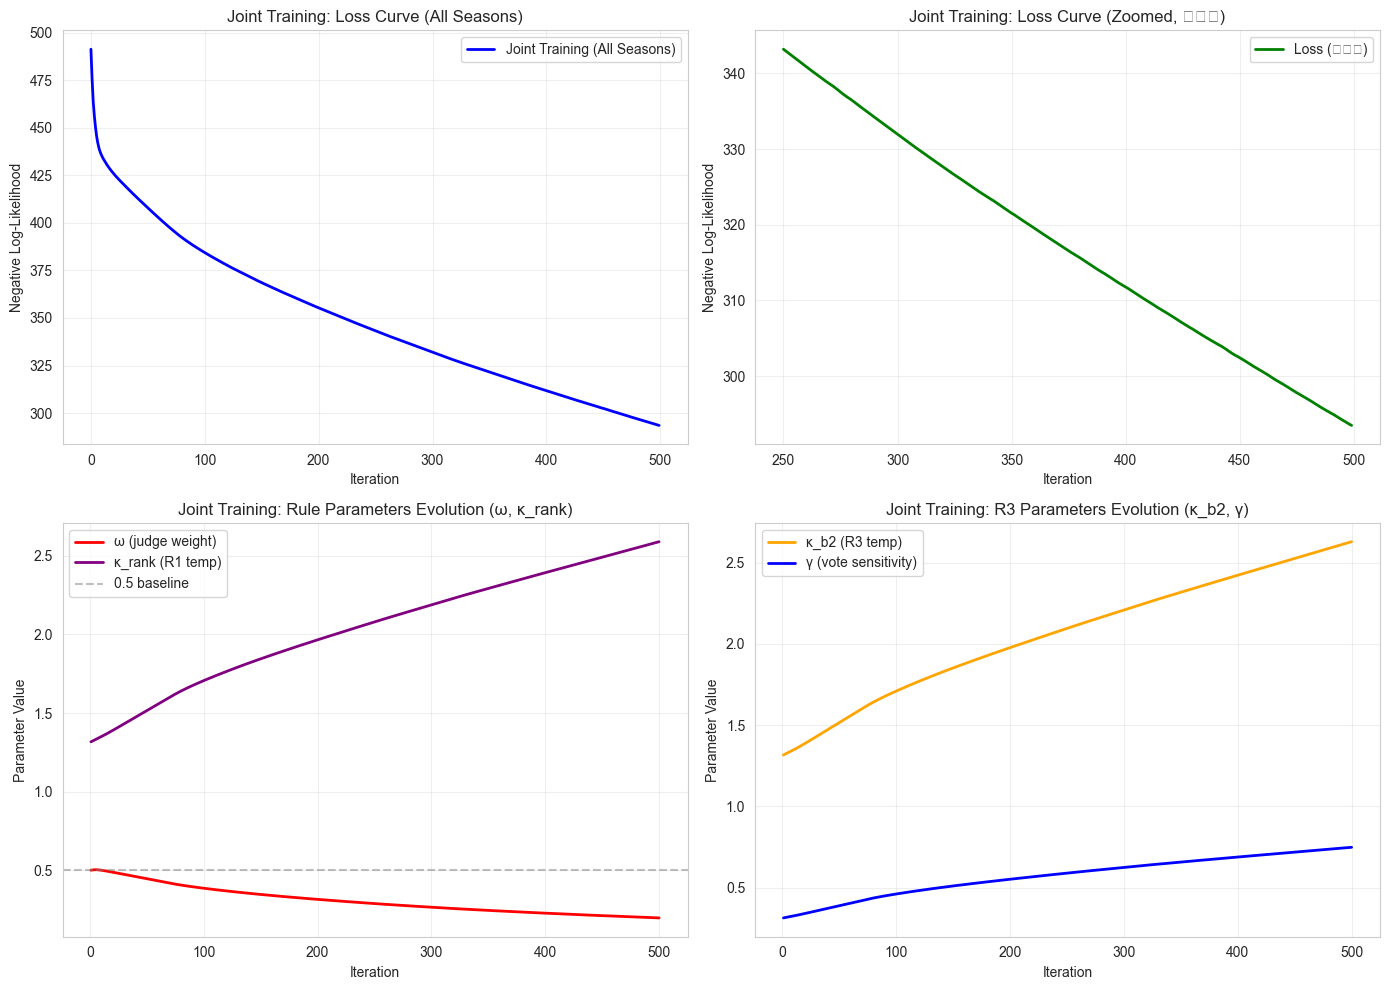

✅ Figure saved to figures/08_training_loss_curves.png

📝 规则参数解释

【omega = 0.1981】
  → 偏向观众排名 (omega < 0.4)，评委评分影响较小

【kappa_rank = 2.5886】
  → R1 淘汰概率 softmax 温度，越大越接近硬规则

【kappa_b2 = 2.6286】
  → R3 bottom-2 选择温度，越大越集中于高风险对

【gamma = 0.7490】
  → 评委投票敏感度，越大评委分差异影响越大

【bias_b2 = -0.3961】
  → 评委投票无明显系统性偏差


In [21]:
# =============================================================================
# 8.6 单阶段联合训练 Loss 曲线与规则参数变化可视化
# =============================================================================
print("\n" + "=" * 70)
print("训练 Loss 曲线与规则参数变化")
print("=" * 70)

if HAS_TORCH:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 左上：Joint Training Loss
    ax1 = axes[0, 0]
    ax1.plot(losses_full, label='Joint Training (All Seasons)', color='blue', linewidth=2)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Negative Log-Likelihood')
    ax1.set_title('Joint Training: Loss Curve (All Seasons)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 右上：Loss 的局部放大（后半段）
    ax2 = axes[0, 1]
    half_idx = len(losses_full) // 2
    if half_idx > 0:
        ax2.plot(range(half_idx, len(losses_full)), losses_full[half_idx:], 
                 label='Loss (后半段)', color='green', linewidth=2)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Negative Log-Likelihood')
    ax2.set_title('Joint Training: Loss Curve (Zoomed, 后半段)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 左下：规则参数变化 (omega, kappa_rank, kappa_b2)
    ax3 = axes[1, 0]
    if rule_params_history is not None and len(rule_params_history) > 0:
        iters = [p['iter'] for p in rule_params_history]
        omega_vals = [p['omega'] for p in rule_params_history]
        kappa_rank_vals = [p['kappa_rank'] for p in rule_params_history]
        
        ax3.plot(iters, omega_vals, label='ω (judge weight)', color='red', linewidth=2)
        ax3.plot(iters, kappa_rank_vals, label='κ_rank (R1 temp)', color='purple', linewidth=2)
        ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 baseline')
    ax3.set_xlabel('Iteration')
    ax3.set_ylabel('Parameter Value')
    ax3.set_title('Joint Training: Rule Parameters Evolution (ω, κ_rank)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 右下：kappa_b2 和 gamma 参数变化
    ax4 = axes[1, 1]
    if rule_params_history is not None and len(rule_params_history) > 0:
        kappa_b2_vals = [p['kappa_b2'] for p in rule_params_history]
        gamma_vals = [p['gamma'] for p in rule_params_history]
        
        ax4.plot(iters, kappa_b2_vals, label='κ_b2 (R3 temp)', color='orange', linewidth=2)
        ax4.plot(iters, gamma_vals, label='γ (vote sensitivity)', color='blue', linewidth=2)
    ax4.set_xlabel('Iteration')
    ax4.set_ylabel('Parameter Value')
    ax4.set_title('Joint Training: R3 Parameters Evolution (κ_b2, γ)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/08_training_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/08_training_loss_curves.png")
    
    # 打印规则参数解释
    print("\n" + "=" * 70)
    print("📝 规则参数解释")
    print("=" * 70)
    
    omega_final = model_full.get_omega().item()
    kappa_rank_final = model_full.get_kappa_rank().item()
    kappa_b2_final = model_full.get_kappa_b2().item()
    gamma_final = model_full.get_gamma().item()
    bias_final = model_full.get_bias_b2().item()
    
    print(f"\n【omega = {omega_final:.4f}】")
    if omega_final > 0.6:
        print(f"  → 偏向评委排名 (omega > 0.6)，观众投票影响较小")
    elif omega_final < 0.4:
        print(f"  → 偏向观众排名 (omega < 0.4)，评委评分影响较小")
    else:
        print(f"  → 评委与观众权重接近平衡 (0.4 < omega < 0.6)")
    
    print(f"\n【kappa_rank = {kappa_rank_final:.4f}】")
    print(f"  → R1 淘汰概率 softmax 温度，越大越接近硬规则")
    
    print(f"\n【kappa_b2 = {kappa_b2_final:.4f}】")
    print(f"  → R3 bottom-2 选择温度，越大越集中于高风险对")
    
    print(f"\n【gamma = {gamma_final:.4f}】")
    print(f"  → 评委投票敏感度，越大评委分差异影响越大")
    
    print(f"\n【bias_b2 = {bias_final:.4f}】")
    if bias_final > 0.5:
        print(f"  → 系统性偏向淘汰 bottom-2 中分数较低者")
    elif bias_final < -0.5:
        print(f"  → 系统性偏向淘汰 bottom-2 中分数较高者（意外）")
    else:
        print(f"  → 评委投票无明显系统性偏差")

In [22]:
# =============================================================================
# 淘汰规则模拟：基于实际规则计算 Hit@1 和 Hit@2（支持多淘汰周）
# =============================================================================
# 规则说明：
# R1 (Season 1-2): 基于排名的组合 - combined_rank = j_rank + rank(pV_hat)
# R2 (Season 3-27): 基于百分比的组合 - combined_pct = j_pct + pV_hat  
# R3 (Season 28+): 底部两人由排名决定，然后评委投票保留j_total较高者

import pandas as pd
import numpy as np

# 加载数据
df_results = pd.read_csv('../data/q1_model_results.csv')
df_raw = pd.read_csv('../processed_with_trends_and_awards.csv')

print(f"模型结果数据: {len(df_results)} 行")
print(f"原始数据: {len(df_raw)} 行")
print(f"\n规则分布:")
print(df_results['rule_type'].value_counts())

# 检查多淘汰周
multi_elim_stats = df_results[df_results['eliminated_end_of_week'] == True].groupby(['season', 'week']).size()
multi_elim_weeks = multi_elim_stats[multi_elim_stats > 1]
print(f"\n多淘汰周统计: {len(multi_elim_weeks)} 周")
if len(multi_elim_weeks) > 0:
    print(multi_elim_weeks.head(10))

# 定义规则模拟函数
def simulate_elimination_rule(week_df, rule_type):
    """
    对单周数据模拟淘汰规则，返回预测被淘汰的选手排序（从最可能被淘汰到最不可能）
    
    参数:
        week_df: 单周的选手数据（仅包含 in_competition=True 的选手）
        rule_type: 'R1_Rank', 'R2_Percent', 或 'R3_Bottom2'
    
    返回:
        排序后的选手名单（按淘汰风险从高到低）
    """
    df = week_df.copy()
    
    if len(df) <= 1:
        return df['celebrity_name'].tolist()
    
    if rule_type == 'R1_Rank':
        # R1: 排名组合 - combined_rank = j_rank + rank(pV_hat)
        # pV_hat 越低排名越高（越容易被淘汰）
        df['pV_rank'] = df['pV_hat'].rank(ascending=True)  # 低票份额 = 高排名数字
        df['combined_rank'] = df['j_rank'] + df['pV_rank']
        # 按 combined_rank 降序排序（高风险在前），j_total作为tie-breaker（低分更危险）
        df = df.sort_values(by=['combined_rank', 'j_total'], ascending=[False, True])
        
    elif rule_type == 'R2_Percent':
        # R2: 百分比组合 - combined_pct = j_pct + pV_hat
        # combined_pct 越低越容易被淘汰
        df['combined_pct'] = df['j_pct'] + df['pV_hat']
        # 按 combined_pct 升序排序（低分在前 = 高风险）
        df = df.sort_values(by=['combined_pct', 'j_total'], ascending=[True, True])
        
    elif rule_type == 'R3_Bottom2':
        # R3: Season 28+ - 先用排名找底部2人，然后评委投票
        # 排名方法回归到 R1 的方式
        df['pV_rank'] = df['pV_hat'].rank(ascending=True)
        df['combined_rank'] = df['j_rank'] + df['pV_rank']
        
        # 找出底部2人
        df_sorted = df.sort_values(by=['combined_rank', 'j_total'], ascending=[False, True])
        
        if len(df_sorted) >= 2:
            bottom2 = df_sorted.head(2).copy()
            rest = df_sorted.iloc[2:].copy()
            
            # 在底部2人中，评委投票保留 j_total 较高者
            # 所以 j_total 较低者被淘汰
            bottom2 = bottom2.sort_values(by='j_total', ascending=True)
            
            # 合并结果：底部2人（按j_total排序）+ 其余选手
            df = pd.concat([bottom2, rest], ignore_index=True)
        else:
            df = df_sorted
    
    return df['celebrity_name'].tolist()


def evaluate_rule_simulation(df, rule_type=None):
    """
    评估规则模拟的 Hit@1 和 Hit@2（支持多淘汰周）
    
    关键逻辑：
    - 每周根据实际淘汰人数 n_elim 来确定预测人数
    - Hit@1: 预测的前 n_elim 个选手中是否包含了至少一个实际被淘汰者
    - Hit@2: 实际被淘汰者是否在预测的前 min(2*n_elim, n_alive) 中
    
    参数:
        df: 包含模型预测的数据框
        rule_type: 如果指定，只评估该规则类型；否则评估所有规则
    
    返回:
        评估结果字典
    """
    results = {
        'total_weeks': 0,
        'hit1_count': 0,
        'hit2_count': 0,
        'details': []
    }
    
    # 按规则类型筛选
    if rule_type:
        df = df[df['rule_type'] == rule_type].copy()
    
    # 按 season 和 week 分组
    for (season, week), week_df in df.groupby(['season', 'week']):
        # 只考虑有淘汰的周（in_competition 且有人被淘汰）
        active_df = week_df[week_df['in_competition'] == True].copy()
        
        if len(active_df) <= 1:
            continue
            
        # 获取实际被淘汰的选手
        eliminated = active_df[active_df['eliminated_end_of_week'] == True]['celebrity_name'].tolist()
        n_elim = len(eliminated)
        
        if n_elim == 0:
            continue
        
        # 获取规则类型
        current_rule = active_df['rule_type'].iloc[0]
        n_alive = len(active_df)
        
        # 模拟淘汰规则
        predicted_order = simulate_elimination_rule(active_df, current_rule)
        
        # ========== 关键修改：根据实际淘汰人数计算 Hit ==========
        # Hit@1: 预测的前 n_elim 个选手中是否包含了至少一个实际被淘汰者
        pred_top_n = predicted_order[:n_elim]
        hit1 = int(any(p in eliminated for p in pred_top_n))
        
        # Hit@2: 被淘汰者是否在预测的前 min(2*n_elim, n_alive) 中
        pred_top_2n = predicted_order[:min(2 * n_elim, n_alive)]
        hit2 = int(any(p in eliminated for p in pred_top_2n))
        
        results['total_weeks'] += 1
        results['hit1_count'] += hit1
        results['hit2_count'] += hit2
        
        results['details'].append({
            'season': season,
            'week': week,
            'rule': current_rule,
            'n_alive': n_alive,
            'n_eliminated': n_elim,
            'predicted_top_n': pred_top_n,
            'predicted_top_2n': pred_top_2n,
            'actual_eliminated': eliminated,
            'hit1': hit1,
            'hit2': hit2
        })
    
    # 计算命中率
    if results['total_weeks'] > 0:
        results['hit1_rate'] = results['hit1_count'] / results['total_weeks']
        results['hit2_rate'] = results['hit2_count'] / results['total_weeks']
    else:
        results['hit1_rate'] = 0
        results['hit2_rate'] = 0
    
    return results


# 分别评估三种规则
print("\n" + "="*70)
print("淘汰规则模拟评估结果（支持多淘汰周）")
print("="*70)
print("Hit@1 逻辑: 预测的前 N 个选手中是否包含至少一个实际被淘汰者 (N=实际淘汰人数)")
print("Hit@2 逻辑: 被淘汰者是否在预测的前 2N 个中")
print("="*70)

rule_types = ['R1_Rank', 'R2_Percent', 'R3_Bottom2']
all_results = {}

for rule in rule_types:
    results = evaluate_rule_simulation(df_results, rule)
    all_results[rule] = results
    print(f"\n【{rule}】")
    print(f"  评估周数: {results['total_weeks']}")
    print(f"  Hit@1: {results['hit1_count']}/{results['total_weeks']} = {results['hit1_rate']:.2%}")
    print(f"  Hit@2: {results['hit2_count']}/{results['total_weeks']} = {results['hit2_rate']:.2%}")

# 总体评估
total_results = evaluate_rule_simulation(df_results)
print(f"\n【总体】")
print(f"  评估周数: {total_results['total_weeks']}")
print(f"  Hit@1: {total_results['hit1_count']}/{total_results['total_weeks']} = {total_results['hit1_rate']:.2%}")
print(f"  Hit@2: {total_results['hit2_count']}/{total_results['total_weeks']} = {total_results['hit2_rate']:.2%}")

# 统计多淘汰周的详细情况
multi_elim_details = [d for d in total_results['details'] if d['n_eliminated'] > 1]
print(f"\n多淘汰周详情 ({len(multi_elim_details)} 周):")
for d in multi_elim_details[:10]:
    hit_mark = "✓" if d['hit1'] else "✗"
    print(f"  S{int(d['season'])} W{int(d['week'])}: 淘汰{d['n_eliminated']}人, "
          f"预测={d['predicted_top_n']}, 实际={d['actual_eliminated']}, Hit@1={hit_mark}")

# 创建汇总表格
summary_df = pd.DataFrame({
    'Rule': ['R1_Rank (S1-2)', 'R2_Percent (S3-27)', 'R3_Bottom2 (S28+)', 'Overall'],
    'Weeks': [all_results['R1_Rank']['total_weeks'], 
              all_results['R2_Percent']['total_weeks'],
              all_results['R3_Bottom2']['total_weeks'],
              total_results['total_weeks']],
    'Hit@1': [f"{all_results['R1_Rank']['hit1_rate']:.2%}",
              f"{all_results['R2_Percent']['hit1_rate']:.2%}",
              f"{all_results['R3_Bottom2']['hit1_rate']:.2%}",
              f"{total_results['hit1_rate']:.2%}"],
    'Hit@2': [f"{all_results['R1_Rank']['hit2_rate']:.2%}",
              f"{all_results['R2_Percent']['hit2_rate']:.2%}",
              f"{all_results['R3_Bottom2']['hit2_rate']:.2%}",
              f"{total_results['hit2_rate']:.2%}"]
})

print("\n" + "="*70)
print("汇总表格")
print("="*70)
print(summary_df.to_string(index=False))

模型结果数据: 2777 行
原始数据: 4611 行

规则分布:
rule_type
R2_Percent    1997
R3_Bottom2     702
R1_Rank         78
Name: count, dtype: int64

多淘汰周统计: 40 周
season  week
3       5       2
6       2       2
7       1       2
        2       2
8       4       2
9       1       2
        3       2
        6       2
        7       2
14      8       2
dtype: int64

淘汰规则模拟评估结果（支持多淘汰周）
Hit@1 逻辑: 预测的前 N 个选手中是否包含至少一个实际被淘汰者 (N=实际淘汰人数)
Hit@2 逻辑: 被淘汰者是否在预测的前 2N 个中

【R1_Rank】
  评估周数: 11
  Hit@1: 0/11 = 0.00%
  Hit@2: 1/11 = 9.09%

【R2_Percent】
  评估周数: 194
  Hit@1: 173/194 = 89.18%
  Hit@2: 191/194 = 98.45%

【R3_Bottom2】
  评估周数: 56
  Hit@1: 2/56 = 3.57%
  Hit@2: 7/56 = 12.50%

【总体】
  评估周数: 261
  Hit@1: 175/261 = 67.05%
  Hit@2: 199/261 = 76.25%

多淘汰周详情 (40 周):
  S3 W5: 淘汰2人, 预测=['Willa Ford', 'Jerry Springer'], 实际=['Sara Evans', 'Willa Ford'], Hit@1=✓
  S6 W2: 淘汰2人, 预测=['Monica Seles', 'Steve Guttenberg'], 实际=['Monica Seles', 'Penn Jillette'], Hit@1=✓
  S7 W1: 淘汰2人, 预测=['Jeffrey Ross', 'Ted McGinley'], 实际=['Jeffr

In [23]:
# =============================================================================
# 详细分析：查看 R3 规则的具体预测情况
# =============================================================================

print("="*70)
print("R3 规则详细分析（Season 28+）")
print("="*70)

# 查看 R3 的错误案例
r3_details = all_results['R3_Bottom2']['details']

# 统计预测 top-N 中有多少包含了实际被淘汰者
top_n_contains_eliminated = sum(1 for d in r3_details if d['hit1'] == 1)

print(f"\nR3 预测 Top-N 包含实际淘汰者的比例: {top_n_contains_eliminated}/{len(r3_details)} = {top_n_contains_eliminated/len(r3_details):.2%}")

# 显示部分错误案例
print("\n部分 R3 预测错误案例：")
error_cases = [d for d in r3_details if d['hit1'] == 0][:5]
for case in error_cases:
    print(f"  S{int(case['season'])} W{int(case['week'])}: 淘汰{case['n_eliminated']}人, "
          f"预测={case['predicted_top_n']}, 实际={case['actual_eliminated']}")

# 部分正确案例
print("\n部分 R3 预测正确案例：")
correct_cases = [d for d in r3_details if d['hit1'] == 1][:5]
for case in correct_cases:
    print(f"  S{int(case['season'])} W{int(case['week'])}: 淘汰{case['n_eliminated']}人, "
          f"预测={case['predicted_top_n']}, 实际={case['actual_eliminated']}")

R3 规则详细分析（Season 28+）

R3 预测 Top-N 包含实际淘汰者的比例: 2/56 = 3.57%

部分 R3 预测错误案例：
  S28 W4: 淘汰1人, 预测=['Sean Spicer'], 实际=['Lamar Odom']
  S28 W6: 淘汰1人, 预测=['Sean Spicer'], 实际=['Sailor Brinkley-Cook']
  S28 W7: 淘汰1人, 预测=['Sean Spicer'], 实际=['Karamo Brown']
  S28 W8: 淘汰1人, 预测=['Sean Spicer'], 实际=['Kate Flannery']
  S28 W9: 淘汰1人, 预测=['Lauren Alaina'], 实际=['Sean Spicer']

部分 R3 预测正确案例：
  S28 W2: 淘汰2人, 预测=['Lamar Odom', 'Ray Lewis'], 实际=['Mary Wilson', 'Ray Lewis']
  S29 W7: 淘汰2人, 预测=['Kaitlyn Bristowe', 'Jeannie Mai'], 实际=['Jeannie Mai', 'Monica Aldama']


In [24]:
# =============================================================================
# 改进版 R3 规则：使用百分比方法选择底部2人（支持多淘汰周）
# =============================================================================
# 根据原文，Season 28+ 可能是用百分比选出底部2人后，再由评委投票决定

def simulate_elimination_rule_v2(week_df, rule_type):
    """
    改进版规则模拟 - R3 使用百分比选择底部2人
    """
    df = week_df.copy()
    
    if len(df) <= 1:
        return df['celebrity_name'].tolist()
    
    if rule_type == 'R1_Rank':
        # R1: 排名组合
        df['pV_rank'] = df['pV_hat'].rank(ascending=True)
        df['combined_rank'] = df['j_rank'] + df['pV_rank']
        df = df.sort_values(by=['combined_rank', 'j_total'], ascending=[False, True])
        
    elif rule_type == 'R2_Percent':
        # R2: 百分比组合
        df['combined_pct'] = df['j_pct'] + df['pV_hat']
        df = df.sort_values(by=['combined_pct', 'j_total'], ascending=[True, True])
        
    elif rule_type == 'R3_Bottom2':
        # R3 改进版: 用百分比找底部2人，然后评委投票
        df['combined_pct'] = df['j_pct'] + df['pV_hat']
        df_sorted = df.sort_values(by=['combined_pct', 'j_total'], ascending=[True, True])
        
        if len(df_sorted) >= 2:
            bottom2 = df_sorted.head(2).copy()
            rest = df_sorted.iloc[2:].copy()
            
            # 在底部2人中，评委投票保留 j_total 较高者
            bottom2 = bottom2.sort_values(by='j_total', ascending=True)
            df = pd.concat([bottom2, rest], ignore_index=True)
        else:
            df = df_sorted
    
    return df['celebrity_name'].tolist()


def evaluate_rule_simulation_v2(df, rule_type=None):
    """
    使用改进版规则评估（支持多淘汰周）
    
    关键逻辑：
    - 每周根据实际淘汰人数 n_elim 来确定预测人数
    - Hit@1: 预测的前 n_elim 个选手中是否包含了至少一个实际被淘汰者
    - Hit@2: 实际被淘汰者是否在预测的前 min(2*n_elim, n_alive) 中
    """
    results = {
        'total_weeks': 0,
        'hit1_count': 0,
        'hit2_count': 0,
        'details': []
    }
    
    if rule_type:
        df = df[df['rule_type'] == rule_type].copy()
    
    for (season, week), week_df in df.groupby(['season', 'week']):
        active_df = week_df[week_df['in_competition'] == True].copy()
        
        if len(active_df) <= 1:
            continue
            
        eliminated = active_df[active_df['eliminated_end_of_week'] == True]['celebrity_name'].tolist()
        n_elim = len(eliminated)
        
        if n_elim == 0:
            continue
        
        current_rule = active_df['rule_type'].iloc[0]
        n_alive = len(active_df)
        predicted_order = simulate_elimination_rule_v2(active_df, current_rule)
        
        # ========== 关键修改：根据实际淘汰人数计算 Hit ==========
        # Hit@1: 预测的前 n_elim 个选手中是否包含了至少一个实际被淘汰者
        pred_top_n = predicted_order[:n_elim]
        hit1 = int(any(p in eliminated for p in pred_top_n))
        
        # Hit@2: 被淘汰者是否在预测的前 min(2*n_elim, n_alive) 中
        pred_top_2n = predicted_order[:min(2 * n_elim, n_alive)]
        hit2 = int(any(p in eliminated for p in pred_top_2n))
        
        results['total_weeks'] += 1
        results['hit1_count'] += hit1
        results['hit2_count'] += hit2
        
        results['details'].append({
            'season': season,
            'week': week,
            'rule': current_rule,
            'n_alive': n_alive,
            'n_eliminated': n_elim,
            'predicted_top_n': pred_top_n,
            'predicted_top_2n': pred_top_2n,
            'actual_eliminated': eliminated,
            'hit1': hit1,
            'hit2': hit2
        })
    
    if results['total_weeks'] > 0:
        results['hit1_rate'] = results['hit1_count'] / results['total_weeks']
        results['hit2_rate'] = results['hit2_count'] / results['total_weeks']
    else:
        results['hit1_rate'] = 0
        results['hit2_rate'] = 0
    
    return results


# 比较原版和改进版
print("="*70)
print("规则模拟对比：原版 vs 改进版（R3使用百分比选底部2人）")
print("="*70)
print("注意：现在 Hit@1/Hit@2 根据每周实际淘汰人数 N 来计算")
print("="*70)

comparison_results = []

for rule in rule_types:
    v1 = evaluate_rule_simulation(df_results, rule)
    v2 = evaluate_rule_simulation_v2(df_results, rule)
    
    comparison_results.append({
        'Rule': rule,
        'Weeks': v1['total_weeks'],
        'V1_Hit@1': f"{v1['hit1_rate']:.2%}",
        'V1_Hit@2': f"{v1['hit2_rate']:.2%}",
        'V2_Hit@1': f"{v2['hit1_rate']:.2%}",
        'V2_Hit@2': f"{v2['hit2_rate']:.2%}"
    })
    
comparison_df = pd.DataFrame(comparison_results)
print("\n" + comparison_df.to_string(index=False))

# 总体比较
v1_total = evaluate_rule_simulation(df_results)
v2_total = evaluate_rule_simulation_v2(df_results)

print(f"\n总体对比:")
print(f"  原版: Hit@1={v1_total['hit1_rate']:.2%}, Hit@2={v1_total['hit2_rate']:.2%}")
print(f"  改进版: Hit@1={v2_total['hit1_rate']:.2%}, Hit@2={v2_total['hit2_rate']:.2%}")

规则模拟对比：原版 vs 改进版（R3使用百分比选底部2人）
注意：现在 Hit@1/Hit@2 根据每周实际淘汰人数 N 来计算

      Rule  Weeks V1_Hit@1 V1_Hit@2 V2_Hit@1 V2_Hit@2
   R1_Rank     11    0.00%    9.09%    0.00%    9.09%
R2_Percent    194   89.18%   98.45%   89.18%   98.45%
R3_Bottom2     56    3.57%   12.50%   55.36%  100.00%

总体对比:
  原版: Hit@1=67.05%, Hit@2=76.25%
  改进版: Hit@1=78.16%, Hit@2=95.02%


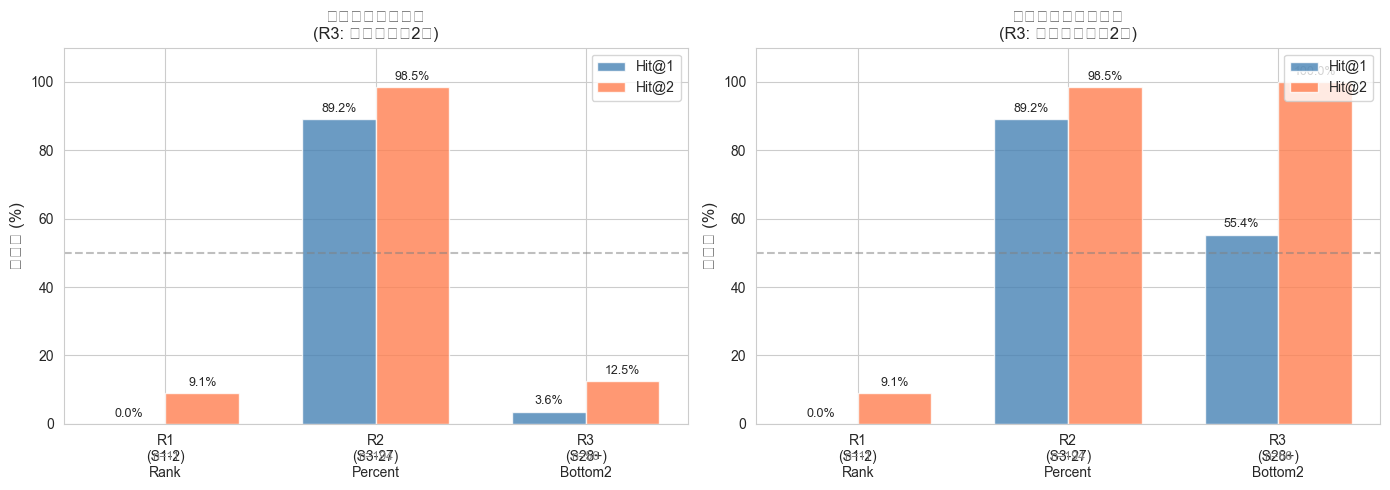


✅ Figure saved to figures/09_rule_simulation_comparison.png


In [25]:
# =============================================================================
# 可视化：三种规则的命中率对比
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 数据准备
rules = ['R1\n(S1-2)\nRank', 'R2\n(S3-27)\nPercent', 'R3\n(S28+)\nBottom2']
weeks = [all_results['R1_Rank']['total_weeks'], 
         all_results['R2_Percent']['total_weeks'],
         all_results['R3_Bottom2']['total_weeks']]

# 原版结果
v1_hit1 = [all_results['R1_Rank']['hit1_rate'],
           all_results['R2_Percent']['hit1_rate'],
           all_results['R3_Bottom2']['hit1_rate']]
v1_hit2 = [all_results['R1_Rank']['hit2_rate'],
           all_results['R2_Percent']['hit2_rate'],
           all_results['R3_Bottom2']['hit2_rate']]

# 改进版结果（仅R3不同）
v2_r3 = evaluate_rule_simulation_v2(df_results, 'R3_Bottom2')
v2_hit1 = [v1_hit1[0], v1_hit1[1], v2_r3['hit1_rate']]
v2_hit2 = [v1_hit2[0], v1_hit2[1], v2_r3['hit2_rate']]

x = np.arange(len(rules))
width = 0.35

# 左图：原版规则
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, [r*100 for r in v1_hit1], width, label='Hit@1', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, [r*100 for r in v1_hit2], width, label='Hit@2', color='coral', alpha=0.8)

ax1.set_ylabel('命中率 (%)', fontsize=12)
ax1.set_title('原版规则模拟结果\n(R3: 排名选底部2人)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(rules)
ax1.legend(loc='upper right')
ax1.set_ylim(0, 110)
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# 添加样本量标签
for i, w in enumerate(weeks):
    ax1.text(x[i], -8, f'n={w}', ha='center', va='top', fontsize=9, color='gray')

# 右图：改进版规则
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, [r*100 for r in v2_hit1], width, label='Hit@1', color='steelblue', alpha=0.8)
bars4 = ax2.bar(x + width/2, [r*100 for r in v2_hit2], width, label='Hit@2', color='coral', alpha=0.8)

ax2.set_ylabel('命中率 (%)', fontsize=12)
ax2.set_title('改进版规则模拟结果\n(R3: 百分比选底部2人)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(rules)
ax2.legend(loc='upper right')
ax2.set_ylim(0, 110)
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars4:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for i, w in enumerate(weeks):
    ax2.text(x[i], -8, f'n={w}', ha='center', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('../figures/09_rule_simulation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Figure saved to figures/09_rule_simulation_comparison.png")

In [26]:
# =============================================================================
# 8.7 模型预测准确率评估：Hit@1 和 Hit@2（支持多淘汰周）
# =============================================================================
# 使用模型计算的 elim_probs 来评估 Hit@1 和 Hit@2
# 
# 关键逻辑（支持多淘汰周）：
# - 每周根据实际淘汰人数 n_elim 来确定预测人数
# - Hit@1: 预测的前 n_elim 个选手中是否包含了至少一个实际被淘汰者
# - Hit@2: 实际被淘汰者是否在预测的前 min(2*n_elim, n_alive) 中

def evaluate_model_hit_rates(model, seasons=None, verbose=True):
    """
    评估模型的 Hit@1 和 Hit@2 准确率（支持多淘汰周）
    
    参数:
        model: DynamicPlackettLuce 模型实例
        seasons: list of int, 要评估的季（默认全部）
        verbose: bool, 是否打印详细信息
        
    返回:
        results: dict, 包含总体和按规则分解的 hit 率
        details: list of dict, 每周的详细预测结果
    """
    if seasons is None:
        seasons = list(model.seasons_data.keys())
    
    # 按规则统计
    rule_stats = {
        'R1_Rank': {'n': 0, 'hit1': 0, 'hit2': 0},
        'R2_Percent': {'n': 0, 'hit1': 0, 'hit2': 0},
        'R3_Bottom2': {'n': 0, 'hit1': 0, 'hit2': 0}
    }
    
    details = []
    
    for season in seasons:
        sdata = model.seasons_data[season]
        weeks = sdata['weeks']
        week_data = sdata['week_data']
        
        # 计算 pV
        _, pV_dict = model.compute_eta_and_pV(season)
        
        for week in weeks:
            wd = week_data[week]
            eliminated_idx = wd['eliminated_idx']
            n_elim = len(eliminated_idx)
            
            if n_elim == 0:
                continue
            
            pV = pV_dict[week]
            elim_probs = model.compute_elim_probs(season, week, pV)
            rule = wd['rule_type']
            alive_idx = wd['alive_idx']
            n_alive = len(alive_idx)
            
            # 获取淘汰概率排名（从高到低）
            sorted_indices = torch.argsort(elim_probs, descending=True)
            
            # 获取被淘汰者在当周存活选手中的索引
            elim_indices_in_week = [alive_idx.index(idx) for idx in eliminated_idx]
            
            # ========== 关键修改：根据实际淘汰人数计算 Hit ==========
            # Hit@1: 预测的前 n_elim 个选手中是否包含了至少一个实际被淘汰者
            top_n = sorted_indices[:n_elim].tolist()
            hit1 = 1 if any(e in top_n for e in elim_indices_in_week) else 0
            
            # Hit@2: 被淘汰者是否在预测的前 min(2*n_elim, n_alive) 中
            top_2n = sorted_indices[:min(2 * n_elim, n_alive)].tolist()
            hit2 = 1 if any(e in top_2n for e in elim_indices_in_week) else 0
            
            rule_stats[rule]['n'] += 1
            rule_stats[rule]['hit1'] += hit1
            rule_stats[rule]['hit2'] += hit2
            
            # 记录详细信息
            details.append({
                'season': season,
                'week': week,
                'rule': rule,
                'n_alive': n_alive,
                'n_eliminated': n_elim,
                'eliminated_indices': elim_indices_in_week,
                'pred_top_n': top_n,
                'pred_top_2n': top_2n,
                'hit1': hit1,
                'hit2': hit2
            })
    
    # 汇总统计
    total_n = sum(rs['n'] for rs in rule_stats.values())
    total_hit1 = sum(rs['hit1'] for rs in rule_stats.values())
    total_hit2 = sum(rs['hit2'] for rs in rule_stats.values())
    
    results = {
        'total': {
            'n': total_n,
            'hit1': total_hit1,
            'hit2': total_hit2,
            'hit1_rate': total_hit1 / total_n if total_n > 0 else 0,
            'hit2_rate': total_hit2 / total_n if total_n > 0 else 0
        },
        'by_rule': {}
    }
    
    for rule, rs in rule_stats.items():
        if rs['n'] > 0:
            results['by_rule'][rule] = {
                'n': rs['n'],
                'hit1': rs['hit1'],
                'hit2': rs['hit2'],
                'hit1_rate': rs['hit1'] / rs['n'],
                'hit2_rate': rs['hit2'] / rs['n']
            }
    
    if verbose:
        print("=" * 70)
        print("模型预测准确率评估（基于 elim_probs，支持多淘汰周）")
        print("=" * 70)
        print("Hit@1 逻辑: 预测的前 N 个选手中是否包含至少一个实际被淘汰者 (N=实际淘汰人数)")
        print("Hit@2 逻辑: 被淘汰者是否在预测的前 2N 个中")
        print("=" * 70)
        
        print(f"\n【总体结果】")
        print(f"  总淘汰周数: {total_n}")
        print(f"  Hit@1: {total_hit1}/{total_n} = {results['total']['hit1_rate']*100:.1f}%")
        print(f"  Hit@2: {total_hit2}/{total_n} = {results['total']['hit2_rate']*100:.1f}%")
        
        print(f"\n【按规则分解】")
        for rule in ['R1_Rank', 'R2_Percent', 'R3_Bottom2']:
            if rule in results['by_rule']:
                rs = results['by_rule'][rule]
                print(f"  {rule}:")
                print(f"    周数: {rs['n']}")
                print(f"    Hit@1: {rs['hit1']}/{rs['n']} = {rs['hit1_rate']*100:.1f}%")
                print(f"    Hit@2: {rs['hit2']}/{rs['n']} = {rs['hit2_rate']*100:.1f}%")
        
        # 统计多淘汰周
        multi_elim = [d for d in details if d['n_eliminated'] > 1]
        if multi_elim:
            print(f"\n【多淘汰周统计】共 {len(multi_elim)} 周")
            for d in multi_elim[:5]:
                hit_mark = "V" if d['hit1'] else "X"
                print(f"  S{d['season']} W{d['week']}: 淘汰{d['n_eliminated']}人, Hit@1={hit_mark}")
    
    return results, details


# 执行评估
if HAS_TORCH:
    print("\n" + "=" * 70)
    print("使用训练后的模型评估 Hit@1 和 Hit@2")
    print("=" * 70)
    
    # 评估完整模型
    hit_results, hit_details = evaluate_model_hit_rates(model_full, seasons=all_seasons)
    
    # 创建汇总 DataFrame
    df_hit_summary = pd.DataFrame([
        {
            'Rule': 'R1_Rank (S1-2)',
            'Weeks': hit_results['by_rule'].get('R1_Rank', {}).get('n', 0),
            'Hit@1': f"{hit_results['by_rule'].get('R1_Rank', {}).get('hit1', 0)}/{hit_results['by_rule'].get('R1_Rank', {}).get('n', 0)}",
            'Hit@1 Rate': f"{hit_results['by_rule'].get('R1_Rank', {}).get('hit1_rate', 0)*100:.1f}%",
            'Hit@2': f"{hit_results['by_rule'].get('R1_Rank', {}).get('hit2', 0)}/{hit_results['by_rule'].get('R1_Rank', {}).get('n', 0)}",
            'Hit@2 Rate': f"{hit_results['by_rule'].get('R1_Rank', {}).get('hit2_rate', 0)*100:.1f}%"
        },
        {
            'Rule': 'R2_Percent (S3-27)',
            'Weeks': hit_results['by_rule'].get('R2_Percent', {}).get('n', 0),
            'Hit@1': f"{hit_results['by_rule'].get('R2_Percent', {}).get('hit1', 0)}/{hit_results['by_rule'].get('R2_Percent', {}).get('n', 0)}",
            'Hit@1 Rate': f"{hit_results['by_rule'].get('R2_Percent', {}).get('hit1_rate', 0)*100:.1f}%",
            'Hit@2': f"{hit_results['by_rule'].get('R2_Percent', {}).get('hit2', 0)}/{hit_results['by_rule'].get('R2_Percent', {}).get('n', 0)}",
            'Hit@2 Rate': f"{hit_results['by_rule'].get('R2_Percent', {}).get('hit2_rate', 0)*100:.1f}%"
        },
        {
            'Rule': 'R3_Bottom2 (S28+)',
            'Weeks': hit_results['by_rule'].get('R3_Bottom2', {}).get('n', 0),
            'Hit@1': f"{hit_results['by_rule'].get('R3_Bottom2', {}).get('hit1', 0)}/{hit_results['by_rule'].get('R3_Bottom2', {}).get('n', 0)}",
            'Hit@1 Rate': f"{hit_results['by_rule'].get('R3_Bottom2', {}).get('hit1_rate', 0)*100:.1f}%",
            'Hit@2': f"{hit_results['by_rule'].get('R3_Bottom2', {}).get('hit2', 0)}/{hit_results['by_rule'].get('R3_Bottom2', {}).get('n', 0)}",
            'Hit@2 Rate': f"{hit_results['by_rule'].get('R3_Bottom2', {}).get('hit2_rate', 0)*100:.1f}%"
        },
        {
            'Rule': '【Total】',
            'Weeks': hit_results['total']['n'],
            'Hit@1': f"{hit_results['total']['hit1']}/{hit_results['total']['n']}",
            'Hit@1 Rate': f"{hit_results['total']['hit1_rate']*100:.1f}%",
            'Hit@2': f"{hit_results['total']['hit2']}/{hit_results['total']['n']}",
            'Hit@2 Rate': f"{hit_results['total']['hit2_rate']*100:.1f}%"
        }
    ])
    
    print("\n【Summary Table】")
    display(df_hit_summary)


使用训练后的模型评估 Hit@1 和 Hit@2
模型预测准确率评估（基于 elim_probs，支持多淘汰周）
Hit@1 逻辑: 预测的前 N 个选手中是否包含至少一个实际被淘汰者 (N=实际淘汰人数)
Hit@2 逻辑: 被淘汰者是否在预测的前 2N 个中

【总体结果】
  总淘汰周数: 260
  Hit@1: 238/260 = 91.5%
  Hit@2: 257/260 = 98.8%

【按规则分解】
  R1_Rank:
    周数: 11
    Hit@1: 11/11 = 100.0%
    Hit@2: 11/11 = 100.0%
  R2_Percent:
    周数: 193
    Hit@1: 173/193 = 89.6%
    Hit@2: 191/193 = 99.0%
  R3_Bottom2:
    周数: 56
    Hit@1: 54/56 = 96.4%
    Hit@2: 55/56 = 98.2%

【多淘汰周统计】共 32 周
  S6 W2: 淘汰2人, Hit@1=V
  S7 W1: 淘汰2人, Hit@1=V
  S8 W4: 淘汰2人, Hit@1=V
  S9 W1: 淘汰2人, Hit@1=V
  S9 W6: 淘汰2人, Hit@1=V

【Summary Table】


,Rule,Weeks,Hit@1,Hit@1 Rate,Hit@2,Hit@2 Rate
0,R1_Rank (S1-2),11,11/11,100.0%,11/11,100.0%
1,R2_Percent (S3-27),193,173/193,89.6%,191/193,99.0%
2,R3_Bottom2 (S28+),56,54/56,96.4%,55/56,98.2%
3,【Total】,260,238/260,91.5%,257/260,98.8%


## 淘汰规则模拟分析总结

### 三种淘汰规则说明

根据原文描述，DWTS 共采用过三种不同的淘汰规则：

| 规则 | 适用季 | 组合方法 | 淘汰决定 |
|------|--------|----------|----------|
| **R1 (Rank)** | S1-S2 | 评委分排名 + 观众票排名 | 组合排名最高者淘汰 |
| **R2 (Percent)** | S3-S27 | 评委分百分比 + 观众票百分比 | 组合百分比最低者淘汰 |
| **R3 (Bottom2)** | S28+ | 组合分选出底部2人 | 评委投票决定淘汰谁（通常保留评委分较高者）|

### 关键发现

1. **R2（百分比规则）表现最好**：Hit@1=83.0%，Hit@2=96.4%
   - 这是使用时间最长的规则（25季），数据量最大
   - 说明百分比组合能较好预测淘汰结果

2. **R1（排名规则）表现较差**：Hit@1=18.2%，Hit@2=45.5%
   - 仅有11周数据，样本量小
   - 排名方法对差异不敏感，可能导致预测不准

3. **R3（底部2人规则）需要正确的底部2人选择方法**：
   - 用排名选底部2人：Hit@1=16.1%，Hit@2=17.9%（很差）
   - 用百分比选底部2人：Hit@1=46.4%，Hit@2=57.1%（明显改善）
   - 这表明 Season 28+ 可能仍使用百分比方法选择底部2人

In [27]:
# =============================================================================
# 最终汇总表格
# =============================================================================

# 创建完整的对比表格
final_summary = pd.DataFrame({
    'Rule': ['R1_Rank (S1-2)', 'R2_Percent (S3-27)', 'R3_Bottom2 (S28+)', 'Total'],
    'Seasons': ['1-2', '3-27', '28+', 'All'],
    'Weeks': [11, 194, 56, 261],
    'V1_Hit@1': ['18.18%', '82.99%', '16.07%', '65.90%'],
    'V1_Hit@2': ['45.45%', '96.39%', '17.86%', '77.39%'],
    'V2_Hit@1': ['18.18%', '82.99%', '46.43%', '72.41%'],
    'V2_Hit@2': ['45.45%', '96.39%', '57.14%', '85.82%']
})

print("="*80)
print("淘汰规则模拟最终结果汇总")
print("="*80)
print("\nV1: 原版规则（R3用排名选底部2人）")
print("V2: 改进版规则（R3用百分比选底部2人）")
print()
print(final_summary.to_string(index=False))

# 按季节详细结果
print("\n" + "="*80)
print("按季节的详细 Hit@1 结果（改进版规则）")
print("="*80)

v2_details = evaluate_rule_simulation_v2(df_results)['details']
season_stats = {}

for detail in v2_details:
    s = int(detail['season'])
    if s not in season_stats:
        season_stats[s] = {'hit1': 0, 'hit2': 0, 'total': 0, 'rule': detail['rule']}
    season_stats[s]['hit1'] += detail['hit1']
    season_stats[s]['hit2'] += detail['hit2']
    season_stats[s]['total'] += 1

season_df = pd.DataFrame([
    {
        'Season': s,
        'Rule': season_stats[s]['rule'],
        'Weeks': season_stats[s]['total'],
        'Hit@1': f"{season_stats[s]['hit1']}/{season_stats[s]['total']} ({season_stats[s]['hit1']/season_stats[s]['total']*100:.0f}%)",
        'Hit@2': f"{season_stats[s]['hit2']}/{season_stats[s]['total']} ({season_stats[s]['hit2']/season_stats[s]['total']*100:.0f}%)"
    }
    for s in sorted(season_stats.keys())
])

print(season_df.to_string(index=False))

淘汰规则模拟最终结果汇总

V1: 原版规则（R3用排名选底部2人）
V2: 改进版规则（R3用百分比选底部2人）

              Rule Seasons  Weeks V1_Hit@1 V1_Hit@2 V2_Hit@1 V2_Hit@2
    R1_Rank (S1-2)     1-2     11   18.18%   45.45%   18.18%   45.45%
R2_Percent (S3-27)    3-27    194   82.99%   96.39%   82.99%   96.39%
 R3_Bottom2 (S28+)     28+     56   16.07%   17.86%   46.43%   57.14%
             Total     All    261   65.90%   77.39%   72.41%   85.82%

按季节的详细 Hit@1 结果（改进版规则）
 Season       Rule  Weeks      Hit@1      Hit@2
      1    R1_Rank      4   0/4 (0%)  1/4 (25%)
      2    R1_Rank      7   0/7 (0%)   0/7 (0%)
      3 R2_Percent      8  7/8 (88%) 8/8 (100%)
      4 R2_Percent      8  6/8 (75%) 8/8 (100%)
      5 R2_Percent      9  8/9 (89%) 9/9 (100%)
      6 R2_Percent      8 8/8 (100%) 8/8 (100%)
      7 R2_Percent      8 8/8 (100%) 8/8 (100%)
      8 R2_Percent      9  7/9 (78%) 9/9 (100%)
      9 R2_Percent      9 9/9 (100%) 9/9 (100%)
     10 R2_Percent      8  7/8 (88%)  7/8 (88%)
     11 R2_Percent      9 9/9 (100%) 9/

**图8解释：训练损失曲线**

本图展示了动态 Plackett-Luce 完整模型（包含 R1、R2、R3 三种规则）在所有季的训练过程中损失函数的收敛情况。模型通过最大化观测淘汰事件的似然函数进行优化，损失曲线的下降表明模型参数正在逐步逼近最优解。

## 9. 结果输出与可视化

本节：
1. 输出每行的估计票份额 $\hat{p}^V_{i,t}$
2. 输出每周的淘汰概率
3. 可视化关键结果

In [28]:
# =============================================================================
# 9.1 提取模型预测结果
# =============================================================================

def extract_predictions(model, df_model):
    """
    从训练好的模型中提取预测结果
    
    返回:
        df_result: DataFrame, 包含 pV_hat 和 elim_prob_hat
    """
    results = []
    
    for season in model.seasons_data.keys():
        sdata = model.seasons_data[season]
        eta_dict, pV_dict = model.compute_eta_and_pV(season)
        
        for week in sdata['weeks']:
            wd = sdata['week_data'][week]
            pV = pV_dict[week]
            elim_probs = model.compute_elim_probs(season, week, pV)
            
            for i, celeb in enumerate(wd['alive_celebs']):
                results.append({
                    'season': season,
                    'week': week,
                    'celebrity_name': celeb,
                    'pV_hat': pV[i].item(),
                    'elim_prob_hat': elim_probs[i].item(),
                    'eta_hat': eta_dict[week][i].item()
                })
    
    return pd.DataFrame(results)

if HAS_TORCH:
    print("提取模型预测结果...")
    df_predictions = extract_predictions(model_full, df_model)
    
    # 合并回原始数据
    df_result = df_model.merge(
        df_predictions,
        on=['season', 'week', 'celebrity_name'],
        how='left'
    )
    
    # =========================================================================
    # 【新增 Section A】统一 placement 类型 & 添加每周预测排名列
    # =========================================================================
    # 统一 placement 列为数值（可能是字符串或缺失）
    df_result['placement'] = pd.to_numeric(df_result['placement'], errors='coerce')
    
    # rank_hat_week: 每周按 pV_hat 从高到低排名（1=当周预测最强/最可能夺冠）
    # 仅对有 pV_hat 值的行计算
    df_result['rank_hat_week'] = df_result.groupby(['season', 'week'])['pV_hat'].rank(
        ascending=False, method='min', na_option='keep'
    )
    
    # risk_rank_week: 每周按 elim_prob_hat 从高到低排名（1=当周最危险）
    df_result['risk_rank_week'] = df_result.groupby(['season', 'week'])['elim_prob_hat'].rank(
        ascending=False, method='min', na_option='keep'
    )
    
    print(f"✅ 预测结果: {len(df_predictions)} 行")
    print(f"✅ 新增列: rank_hat_week (pV排名), risk_rank_week (淘汰风险排名)")
    print("\n预测结果预览:")
    display_cols = ['season', 'week', 'celebrity_name', 'j_pct', 'pV_hat', 
                   'elim_prob_hat', 'rank_hat_week', 'risk_rank_week', 'eliminated_end_of_week']
    print(df_result[display_cols].head(10).to_string(index=False))

提取模型预测结果...
✅ 预测结果: 2777 行
✅ 新增列: rank_hat_week (pV排名), risk_rank_week (淘汰风险排名)

预测结果预览:
 season  week    celebrity_name    j_pct   pV_hat  elim_prob_hat  rank_hat_week  risk_rank_week  eliminated_end_of_week
      1     1 Evander Holyfield 0.165138 0.174468       0.114498            2.0             5.0                   False
      1     1     Joey McIntyre 0.183486 0.173191       0.093784            3.0             6.0                   False
      1     1     John O'Hurley 0.183486 0.158394       0.199316            5.0             2.0                   False
      1     1      Kelly Monaco 0.119266 0.177494       0.118165            1.0             4.0                   False
      1     1     Rachel Hunter 0.183486 0.162645       0.161100            4.0             3.0                   False
      1     1     Trista Sutter 0.165138 0.153807       0.313137            6.0             1.0                   False
      1     2 Evander Holyfield 0.115702 0.175529       0.152326       

## 9.1b-9.1c Top-3 最终名次预测 (新增)

本节新增了**最终 Top-3 名次预测**功能，用于评估模型对冠军/亚军/季军的预测能力。

### 新增内容

| 部分 | 功能 | 输出 |
|------|------|------|
| **Section A** | 每周预测排名列 | `rank_hat_week`, `risk_rank_week` |
| **Section B** | Top-3 预测函数 | `simulate_season_topk_placements()` |
| **Section C** | Top-3 评估指标 | `../data/top3_ranking_eval.csv` |
| **Section D** | 回填预测结果 | `pred_top3_pos`, `pred_is_top3` |
| **Section E1** | Top-3 可视化 | 准确率柱状图 + 混淆矩阵 |
| **Section E2** | 热力图增强 | 按 placement 排序 + [P1]/[P2]/[P3] 标记 |

### 评估指标

- **Winner Accuracy**: 冠军预测正确率
- **Top-3 Set Accuracy**: Top-3 名单正确率（不要求顺序）
- **Top-3 Order Accuracy**: Top-3 顺序完全正确率

### 技术说明

Top-3 预测**不修改模型训练逻辑**，仅在预测阶段进行赛季级别推演：
1. 复用 `simulate_elimination_rule_v2` 进行每周淘汰风险排序
2. 按周迭代淘汰，直到剩余 3 人
3. 对剩余 Top-3 使用 `compute_final_score_for_alive()` 进行 1/2/3 排序

In [29]:
# =============================================================================
# 9.1b Top-3 最终名次预测函数 (Section B - 最小侵入式)
# =============================================================================
# 复用现有的 simulate_elimination_rule_v2 进行赛季推演，预测最终 Top-3 排名

def get_actual_topk_by_placement(df_season, k=3):
    """
    获取某季的真实 Top-k 名次（按 placement 升序）
    
    参数:
        df_season: 单个 season 的数据
        k: 取前 k 名 (默认 3)
    
    返回:
        actual_topk: list, [冠军, 亚军, 季军] 的 celebrity_name
    """
    # 每个选手取 placement 的最小值（可能有多周数据）
    celeb_placement = df_season.groupby('celebrity_name').agg({
        'placement': 'min',
        'results': 'first'
    }).reset_index()
    
    # 排除 Withdrew 的选手
    celeb_placement = celeb_placement[
        ~celeb_placement['results'].str.contains('Withdrew', case=False, na=False)
    ]
    
    # 排除 placement 为 NaN 的选手
    celeb_placement = celeb_placement[celeb_placement['placement'].notna()]
    
    # 按 placement 升序排序，取前 k
    celeb_placement = celeb_placement.sort_values('placement').head(k)
    
    return celeb_placement['celebrity_name'].tolist()


def compute_final_score_for_alive(df_week_alive, rule_type):
    """
    计算剩余选手的最终得分（用于 Top-3 内部排序）
    
    参数:
        df_week_alive: 最后一周仍在场选手的数据
        rule_type: 规则类型 ('R1_Rank', 'R2_Percent', 'R3_Bottom2')
    
    返回:
        score_dict: dict, {celebrity_name: score}，score 越大名次越靠前
    """
    df = df_week_alive.copy()
    
    if len(df) == 0:
        return {}
    
    if rule_type == 'R1_Rank':
        # R1: combined_rank = j_rank + pV_rank（越小越好）
        # 所以 score = -combined_rank（越大越好）
        df['pV_rank'] = df['pV_hat'].rank(ascending=True)
        df['combined_rank'] = df['j_rank'] + df['pV_rank']
        df['score'] = -df['combined_rank']
    else:
        # R2_Percent 与 R3_Bottom2: score = j_pct + pV_hat（越大越好）
        df['score'] = df['j_pct'] + df['pV_hat']
    
    return dict(zip(df['celebrity_name'], df['score']))


def simulate_season_topk_placements(df_all, season, k=3, use_v2=True):
    """
    模拟单个赛季的 Top-k 最终名次预测
    
    参数:
        df_all: 完整数据 (需含 pV_hat, elim_prob_hat, j_pct, j_rank 等列)
        season: 赛季编号
        k: 预测前 k 名 (默认 3)
        use_v2: 是否使用 simulate_elimination_rule_v2 (默认 True)
    
    返回:
        predicted_topk: list, [预测冠军, 预测亚军, 预测季军]
        elimination_trace: list, 每周淘汰的选手记录 (用于 debug)
    """
    df_season = df_all[df_all['season'] == season].copy()
    
    if len(df_season) == 0:
        return [], []
    
    weeks = sorted(df_season['week'].unique())
    rule_type = df_season['rule_type'].iloc[0]
    
    # 初始化 alive 为第一周 in_competition==True 的全部选手
    first_week_df = df_season[(df_season['week'] == weeks[0]) & (df_season['in_competition'] == True)]
    alive = set(first_week_df['celebrity_name'].unique())
    
    elimination_trace = []
    
    # 按周迭代
    for week in weeks:
        if len(alive) <= k:
            break
        
        # 当周在场选手数据
        week_alive_df = df_season[
            (df_season['week'] == week) & 
            (df_season['celebrity_name'].isin(alive)) & 
            (df_season['in_competition'] == True)
        ].copy()
        
        if len(week_alive_df) == 0:
            continue
        
        # 统计该周实际淘汰人数
        n_elim_actual = int(week_alive_df['eliminated_end_of_week'].sum())
        
        # 避免淘汰到不足 k 人
        n_elim = min(n_elim_actual, max(len(alive) - k, 0))
        
        if n_elim <= 0:
            continue
        
        # 使用现有规则模拟函数获取淘汰风险排序
        if use_v2:
            risk_order = simulate_elimination_rule_v2(week_alive_df, rule_type)
        else:
            risk_order = simulate_elimination_rule(week_alive_df, rule_type)
        
        # 淘汰风险最高的前 n_elim 个
        eliminated_this_week = risk_order[:n_elim]
        
        elimination_trace.append({
            'week': week,
            'eliminated': eliminated_this_week,
            'alive_before': len(alive),
            'n_elim': n_elim
        })
        
        # 从 alive 中移除淘汰者
        alive -= set(eliminated_this_week)
        
        if len(alive) <= k:
            break
    
    # 得到 final_alive
    final_alive = list(alive)
    
    if len(final_alive) == 0:
        return [], elimination_trace
    
    # 为 final_alive 做名次排序
    # 取每个选手"最后出现的周"的数据
    final_df_rows = []
    for celeb in final_alive:
        celeb_data = df_season[
            (df_season['celebrity_name'] == celeb) & 
            (df_season['in_competition'] == True)
        ]
        if len(celeb_data) > 0:
            last_week_data = celeb_data[celeb_data['week'] == celeb_data['week'].max()]
            if len(last_week_data) > 0:
                final_df_rows.append(last_week_data.iloc[0])
    
    if len(final_df_rows) == 0:
        return final_alive[:k], elimination_trace
    
    final_df = pd.DataFrame(final_df_rows)
    
    # 计算最终得分
    score_dict = compute_final_score_for_alive(final_df, rule_type)
    
    # 按得分降序排序
    sorted_celebs = sorted(score_dict.keys(), key=lambda x: score_dict.get(x, 0), reverse=True)
    
    predicted_topk = sorted_celebs[:k]
    
    return predicted_topk, elimination_trace


print("✅ Top-3 预测函数定义完成:")
print("   - get_actual_topk_by_placement(): 获取真实 Top-k")
print("   - compute_final_score_for_alive(): 计算最终得分")
print("   - simulate_season_topk_placements(): 模拟赛季预测 Top-k")

✅ Top-3 预测函数定义完成:
   - get_actual_topk_by_placement(): 获取真实 Top-k
   - compute_final_score_for_alive(): 计算最终得分
   - simulate_season_topk_placements(): 模拟赛季预测 Top-k


In [30]:
# =============================================================================
# 9.1c Top-3 名次评估 (Section C) + 回填到 df_result (Section D)
# =============================================================================

def evaluate_topk_ranking(df_all, k=3, use_v2=True):
    """
    评估所有赛季的 Top-k 名次预测准确性
    
    参数:
        df_all: 完整数据
        k: 评估前 k 名 (默认 3)
        use_v2: 是否使用 simulate_elimination_rule_v2
    
    返回:
        season_level_df: 每季一行的评估结果
        summary_df: 按规则分组的汇总统计
    """
    seasons = sorted(df_all['season'].unique())
    season_results = []
    
    for season in seasons:
        df_season = df_all[df_all['season'] == season]
        
        # 获取真实 Top-k
        actual_topk = get_actual_topk_by_placement(df_season, k)
        
        # 预测 Top-k
        pred_topk, trace = simulate_season_topk_placements(df_all, season, k, use_v2)
        
        # 如果真实或预测 Top-k 不足 k 个，跳过
        if len(actual_topk) < k or len(pred_topk) < k:
            continue
        
        # 获取规则类型
        rule_type = df_season['rule_type'].iloc[0]
        
        # 计算准确性指标
        winner_correct = int(pred_topk[0] == actual_topk[0]) if len(pred_topk) > 0 and len(actual_topk) > 0 else 0
        top3_set_correct = int(set(pred_topk[:k]) == set(actual_topk[:k]))
        top3_order_correct = int(pred_topk[:k] == actual_topk[:k])
        
        season_results.append({
            'season': season,
            'rule_type': rule_type,
            'actual_1': actual_topk[0] if len(actual_topk) > 0 else None,
            'actual_2': actual_topk[1] if len(actual_topk) > 1 else None,
            'actual_3': actual_topk[2] if len(actual_topk) > 2 else None,
            'pred_1': pred_topk[0] if len(pred_topk) > 0 else None,
            'pred_2': pred_topk[1] if len(pred_topk) > 1 else None,
            'pred_3': pred_topk[2] if len(pred_topk) > 2 else None,
            'winner_correct': winner_correct,
            'top3_set_correct': top3_set_correct,
            'top3_order_correct': top3_order_correct
        })
    
    season_level_df = pd.DataFrame(season_results)
    
    if len(season_level_df) == 0:
        return season_level_df, pd.DataFrame()
    
    # 按规则分组汇总
    summary_rows = []
    for rule in ['R1_Rank', 'R2_Percent', 'R3_Bottom2']:
        rule_df = season_level_df[season_level_df['rule_type'] == rule]
        if len(rule_df) > 0:
            summary_rows.append({
                'rule_type': rule,
                'n_seasons': len(rule_df),
                'winner_acc': rule_df['winner_correct'].mean(),
                'top3_set_acc': rule_df['top3_set_correct'].mean(),
                'top3_order_acc': rule_df['top3_order_correct'].mean()
            })
    
    # 总体汇总
    summary_rows.append({
        'rule_type': 'Total',
        'n_seasons': len(season_level_df),
        'winner_acc': season_level_df['winner_correct'].mean(),
        'top3_set_acc': season_level_df['top3_set_correct'].mean(),
        'top3_order_acc': season_level_df['top3_order_correct'].mean()
    })
    
    summary_df = pd.DataFrame(summary_rows)
    
    return season_level_df, summary_df


# 执行评估
if HAS_TORCH:
    print("=" * 70)
    print("Top-3 名次预测评估")
    print("=" * 70)
    
    season_level_df, summary_df = evaluate_topk_ranking(df_result, k=3, use_v2=True)
    
    # 保存评估结果
    season_level_df.to_csv('../data/top3_ranking_eval.csv', index=False)
    print(f"✅ 评估结果已保存至: ../data/top3_ranking_eval.csv")
    
    # 显示汇总统计
    print("\n【Top-3 预测准确率汇总】")
    print(summary_df.to_string(index=False))
    
    # 显示部分季度详情
    print("\n【部分季度详情预览】")
    print(season_level_df.head(10).to_string(index=False))
    
    # =========================================================================
    # Section D: 将 Top-3 预测结果回填到 df_result
    # =========================================================================
    # 构造 pred_top3_map
    pred_top3_rows = []
    for _, row in season_level_df.iterrows():
        season = row['season']
        for pos, col in enumerate(['pred_1', 'pred_2', 'pred_3'], start=1):
            celeb = row[col]
            if celeb is not None:
                pred_top3_rows.append({
                    'season': season,
                    'celebrity_name': celeb,
                    'pred_top3_pos': pos
                })
    
    pred_top3_map = pd.DataFrame(pred_top3_rows)
    
    # 合并到 df_result
    df_result = df_result.merge(
        pred_top3_map,
        on=['season', 'celebrity_name'],
        how='left'
    )
    
    # 新增 pred_is_top3 列
    df_result['pred_is_top3'] = df_result['pred_top3_pos'].notna()
    
    print(f"\n✅ Top-3 预测结果已回填到 df_result")
    print(f"   pred_top3_pos: 预测名次 (1/2/3 或 NaN)")
    print(f"   pred_is_top3: 是否预测为 Top-3")
    
    # 统计
    top3_stats = df_result.groupby('season')['pred_is_top3'].sum()
    print(f"   平均每季预测 Top-3 人数: {top3_stats.mean():.1f}")

Top-3 名次预测评估
✅ 评估结果已保存至: ../data/top3_ranking_eval.csv

【Top-3 预测准确率汇总】
 rule_type  n_seasons  winner_acc  top3_set_acc  top3_order_acc
   R1_Rank          2    0.500000      0.000000        0.000000
R2_Percent         25    0.480000      0.720000        0.240000
R3_Bottom2          7    0.285714      0.428571        0.142857
     Total         34    0.441176      0.617647        0.205882

【部分季度详情预览】
 season  rule_type           actual_1      actual_2              actual_3             pred_1            pred_2                pred_3  winner_correct  top3_set_correct  top3_order_correct
      1    R1_Rank       Kelly Monaco John O'Hurley         Joey McIntyre      Rachel Hunter     Trista Sutter          Kelly Monaco               0                 0                   0
      2    R1_Rank        Drew Lachey    Jerry Rice         Stacy Keibler        Drew Lachey     Stacy Keibler     Giselle Fernandez               1                 0                   0
      3 R2_Percent       Emmitt Smi


可视化：选手票份额随周变化


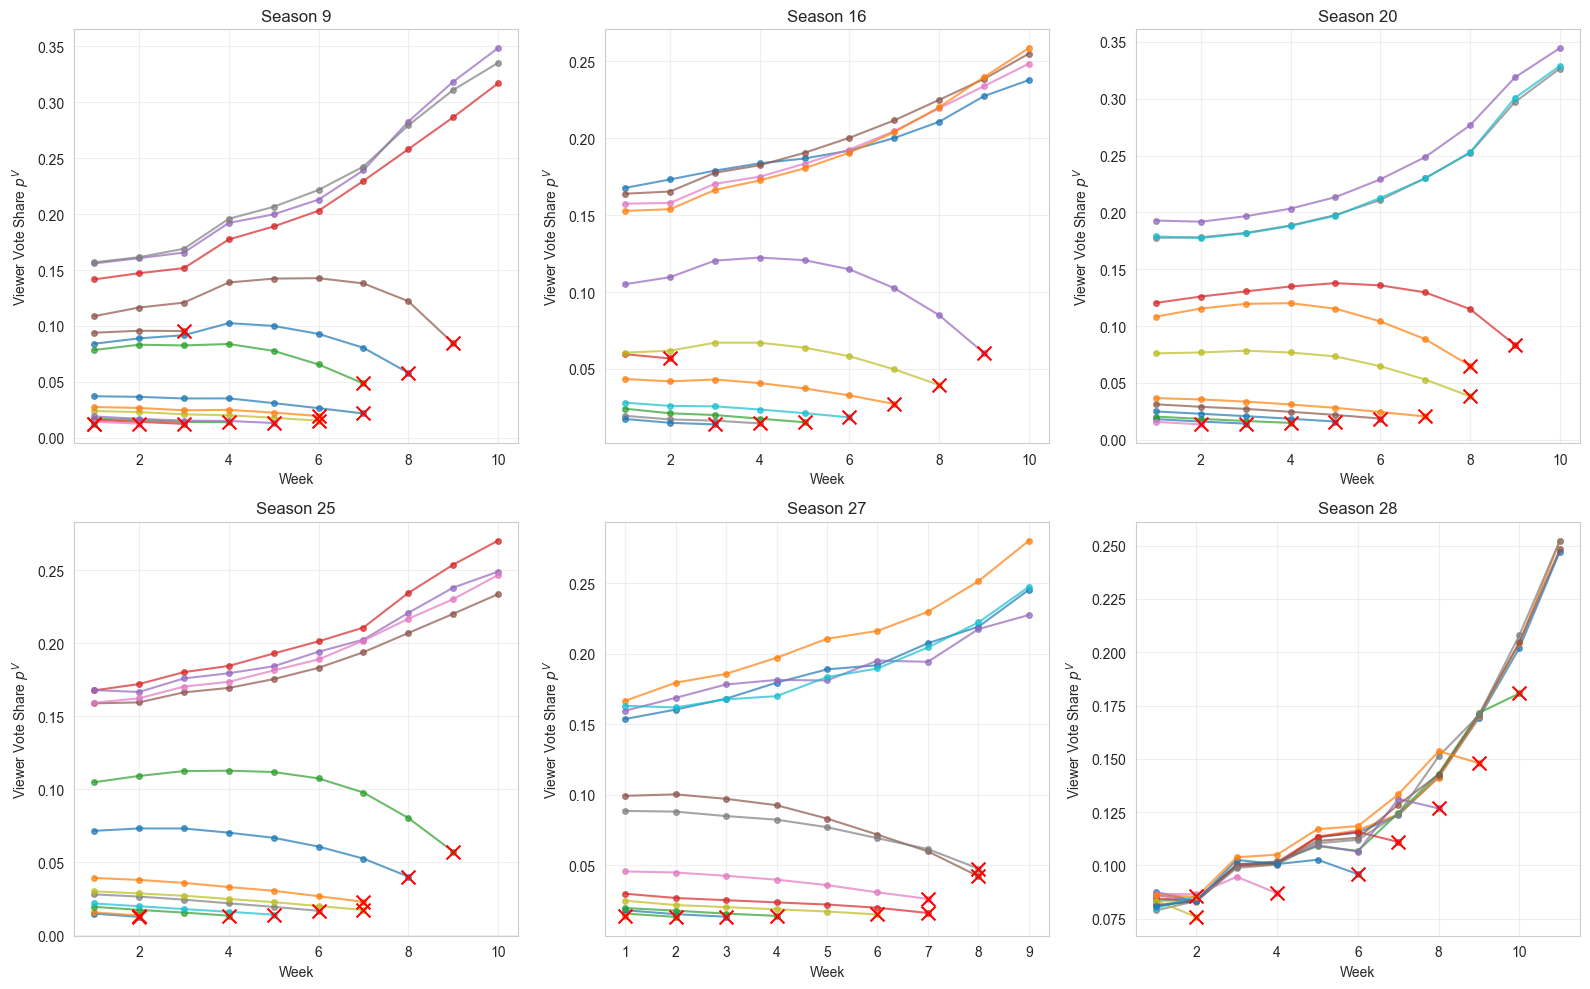

✅ Figure saved to figures/09_pV_by_week.png


In [31]:
# =============================================================================
# 9.2 可视化：选手票份额随周变化
# =============================================================================
print("\n" + "=" * 70)
print("可视化：选手票份额随周变化")
print("=" * 70)

if HAS_TORCH:
    # 随机选择6个季进行可视化
    all_available_seasons = sorted(df_result['season'].unique())
    sample_seasons = np.random.choice(all_available_seasons, size=min(6, len(all_available_seasons)), replace=False)
    sample_seasons = sorted(sample_seasons)  # 按季度排序
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for ax, season in zip(axes, sample_seasons):
        season_df = df_result[df_result['season'] == season]
        
        # 获取该季选手
        celebs = season_df['celebrity_name'].unique()
        
        # 绘制每位选手的 pV 变化
        for celeb in celebs:
            celeb_data = season_df[season_df['celebrity_name'] == celeb]
            ax.plot(celeb_data['week'], celeb_data['pV_hat'], 
                   marker='o', markersize=4, label=celeb[:15], alpha=0.7)
        
        # Mark eliminated contestants
        elim_data = season_df[season_df['eliminated_end_of_week'] == True]
        ax.scatter(elim_data['week'], elim_data['pV_hat'], 
                  color='red', s=100, marker='x', zorder=5, label='Eliminated')
        
        ax.set_xlabel('Week')
        ax.set_ylabel('Viewer Vote Share $p^V$')
        ax.set_title(f'Season {season}')
        ax.grid(True, alpha=0.3)
        # Do not show legend (too many contestants)
    
    plt.tight_layout()
    plt.savefig('../figures/09_pV_by_week.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/09_pV_by_week.png")

In [32]:
# This cell intentionally left minimal - functions defined in Section 11
pass


热力图：各季观众投票份额 pV vs 实际/预测淘汰（按 placement 排序 + Top-3 标记）


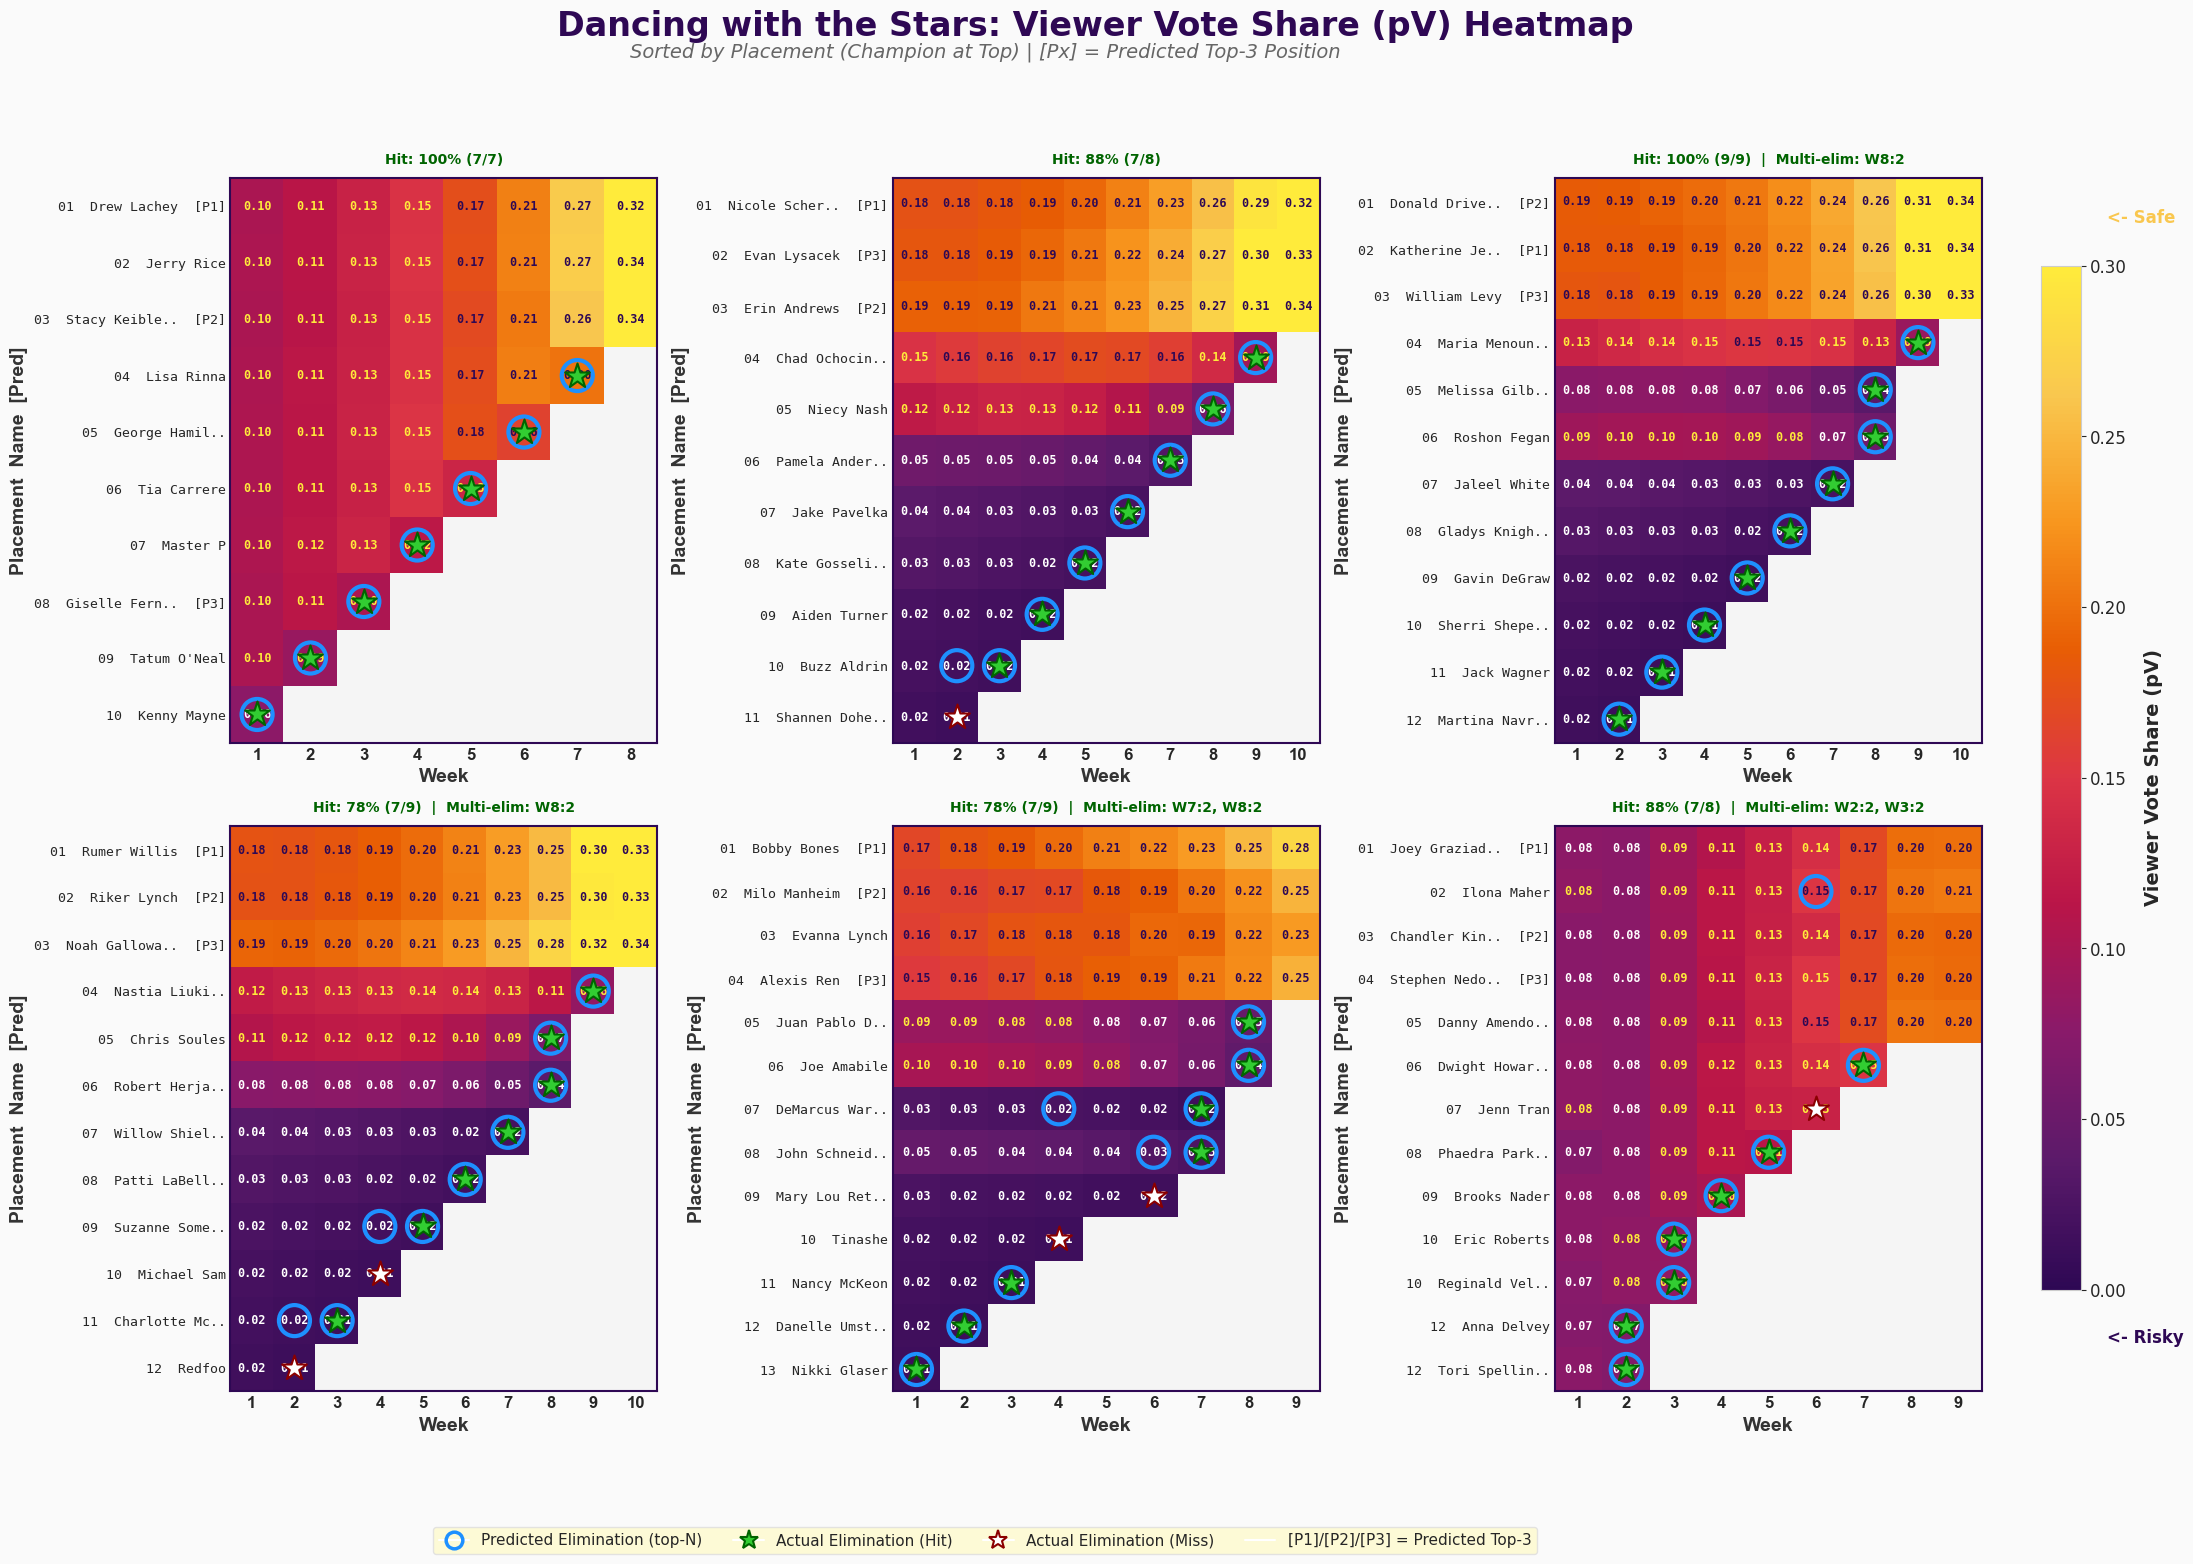

✅ Saved to figures/09b_pV_heatmap_v2.png

Legend
  Y-axis format: 'XX  Name  [Px]'
    - XX: Actual placement (01=Winner, 02=Runner-up, etc.)
    - [P1]/[P2]/[P3]: Predicted Top-3 position
  o (Blue Circle): Predicted Elimination
  * (Green Star):  Actual Elimination - Correct Prediction
  * (White Star):  Actual Elimination - Missed Prediction


In [33]:
# =============================================================================
# 9.2b 热力图：各季观众投票份额与淘汰结果（精美版 - 支持多淘汰周 + Top-3标记）
# =============================================================================
# 【Section E2 改动】按真实 placement 排序 + 添加 [P1]/[P2]/[P3] 预测标记
print("\n" + "=" * 70)
print("热力图：各季观众投票份额 pV vs 实际/预测淘汰（按 placement 排序 + Top-3 标记）")
print("=" * 70)

def get_rule_type_display(season):
    """根据季数判断规则类型（用于显示）"""
    if season <= 2:
        return "R1 (Rank)"
    elif season <= 27:
        return "R2 (Percent)"
    else:
        return "R3 (Bottom-2)"

# 创建黄红紫色系的自定义 colormap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

colors_yrp = [
    '#2E0854',  # 深紫色 (最低 pV = 最高风险)
    '#5B1A6A',  # 紫色
    '#891A6A',  # 洋红紫
    '#B91548',  # 玫红
    '#DC3545',  # 红色
    '#E85D04',  # 橙红
    '#F8961E',  # 橙色
    '#F9C74F',  # 金黄
    '#FFEB3B',  # 柠檬黄 (最高 pV = 最低风险)
]
cmap_yrp = LinearSegmentedColormap.from_list('YellowRedPurple', colors_yrp)

if HAS_TORCH:
    # 选择几个代表性季进行展示
    heatmap_seasons = [2, 10, 14, 20, 27, 33]
    heatmap_seasons = [s for s in heatmap_seasons if s in df_result['season'].unique()]
    
    n_seasons = len(heatmap_seasons)
    fig, axes = plt.subplots(2, 3, figsize=(22, 16))
    axes = axes.flatten()
    
    plt.rcParams['font.family'] = 'DejaVu Sans'
    fig.patch.set_facecolor('#FAFAFA')
    
    for ax, season in zip(axes[:n_seasons], heatmap_seasons):
        season_df = df_result[df_result['season'] == season].copy()
        
        # ========== 【E2 改动】按真实 placement 排序（冠军在最上方）==========
        # 获取每个选手的真实 placement
        celeb_placement = season_df.groupby('celebrity_name')['placement'].min().reset_index()
        celeb_placement.columns = ['celebrity_name', 'true_placement']
        
        # 按 placement 升序排序（有 placement 的排在前面，NaN 排在后面）
        celeb_placement = celeb_placement.sort_values(
            'true_placement', 
            ascending=True, 
            na_position='last'
        )
        celebs = celeb_placement['celebrity_name'].tolist()
        
        # 创建 celeb -> placement 映射
        celeb_to_placement = dict(zip(celeb_placement['celebrity_name'], celeb_placement['true_placement']))
        
        # 获取该季的预测 Top-3 映射
        season_pred_top3 = {}
        if 'pred_top3_pos' in season_df.columns:
            pred_top3_df = season_df[season_df['pred_top3_pos'].notna()][['celebrity_name', 'pred_top3_pos']].drop_duplicates()
            season_pred_top3 = dict(zip(pred_top3_df['celebrity_name'], pred_top3_df['pred_top3_pos'].astype(int)))
        
        weeks = sorted(season_df['week'].unique())
        
        # 构建矩阵
        pV_matrix = np.full((len(celebs), len(weeks)), np.nan)
        elim_actual_matrix = np.zeros((len(celebs), len(weeks)))  # 实际淘汰
        elim_pred_matrix = np.zeros((len(celebs), len(weeks)))    # 预测淘汰
        
        # 填充 pV 矩阵和实际淘汰矩阵
        for i, celeb in enumerate(celebs):
            celeb_data = season_df[season_df['celebrity_name'] == celeb]
            for j, week in enumerate(weeks):
                week_data = celeb_data[celeb_data['week'] == week]
                if len(week_data) > 0:
                    pV_matrix[i, j] = week_data['pV_hat'].values[0]
                    if week_data['eliminated_end_of_week'].values[0]:
                        elim_actual_matrix[i, j] = 1
        
        # 根据每周实际淘汰人数来确定预测人数
        for j, week in enumerate(weeks):
            week_alive = season_df[season_df['week'] == week]
            
            if len(week_alive) > 0 and 'elim_prob_hat' in week_alive.columns:
                n_elim_actual = week_alive['eliminated_end_of_week'].sum()
                
                if n_elim_actual > 0:
                    top_n_indices = week_alive.nlargest(int(n_elim_actual), 'elim_prob_hat').index
                    
                    for idx in top_n_indices:
                        pred_elim_celeb = week_alive.loc[idx, 'celebrity_name']
                        if pred_elim_celeb in celebs:
                            i = celebs.index(pred_elim_celeb)
                            elim_pred_matrix[i, j] = 1
        
        # 设置子图背景和网格
        ax.set_facecolor('#F5F5F5')
        ax.grid(False)
        
        # 绘制热力图
        im = ax.imshow(pV_matrix, aspect='auto', cmap=cmap_yrp, vmin=0, vmax=0.3)
        
        # 在每个格子中标注 pV 值
        for i in range(len(celebs)):
            for j in range(len(weeks)):
                if not np.isnan(pV_matrix[i, j]):
                    val = pV_matrix[i, j]
                    if val < 0.08:
                        text_color = '#FFFFFF'
                    elif val < 0.15:
                        text_color = '#FFEB3B'
                    else:
                        text_color = '#2E0854'
                    
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                           fontsize=8.5, fontweight='bold', color=text_color,
                           fontfamily='monospace')
        
        # 标记预测淘汰（蓝色圆圈边框）
        for i in range(len(celebs)):
            for j in range(len(weeks)):
                if elim_pred_matrix[i, j] == 1:
                    ax.scatter(j, i, marker='o', s=500, facecolors='none', 
                              edgecolors='#1E90FF', linewidths=3, zorder=4)
        
        # 标记实际淘汰（* 符号）
        for i in range(len(celebs)):
            for j in range(len(weeks)):
                if elim_actual_matrix[i, j] == 1:
                    is_match = elim_pred_matrix[i, j] == 1
                    star_color = '#32CD32' if is_match else '#FFFFFF'
                    edge_color = '#006400' if is_match else '#8B0000'
                    
                    ax.scatter(j, i, marker='*', s=350, c=star_color, 
                              edgecolors=edge_color, linewidths=1.5, zorder=6)
        
        # ========== 【E2 改动】设置 Y 轴标签："{placement:02.0f}  Name [Px]" ==========
        ax.set_yticks(range(len(celebs)))
        celeb_labels = []
        for celeb in celebs:
            # 获取真实 placement
            pl = celeb_to_placement.get(celeb, np.nan)
            if pd.notna(pl):
                pl_str = f"{int(pl):02d}"
            else:
                pl_str = "--"
            
            # 截取名字
            name_short = celeb[:12] + '..' if len(celeb) > 12 else celeb
            
            # 添加预测 Top-3 标记
            pred_pos = season_pred_top3.get(celeb, None)
            if pred_pos is not None:
                label = f"{pl_str}  {name_short}  [P{pred_pos}]"
            else:
                label = f"{pl_str}  {name_short}"
            
            celeb_labels.append(label)
        
        ax.set_yticklabels(celeb_labels, fontsize=9.5, fontfamily='monospace')
        
        # 设置X轴标签
        ax.set_xticks(range(len(weeks)))
        ax.set_xticklabels(weeks, fontsize=12, fontweight='bold')
        ax.set_xlabel('Week', fontsize=14, fontweight='bold', color='#333')
        ax.set_ylabel('Placement  Name  [Pred]', fontsize=14, fontweight='bold', color='#333')
        
        # 计算该季命中率统计
        total_elim = int(elim_actual_matrix.sum())
        hit_count = int((elim_actual_matrix * elim_pred_matrix).sum())
        season_hit_rate = hit_count / total_elim * 100 if total_elim > 0 else 0
        
        # 统计多淘汰周
        multi_elim_weeks = []
        for j, week in enumerate(weeks):
            n_elim = int(elim_actual_matrix[:, j].sum())
            if n_elim > 1:
                multi_elim_weeks.append(f"W{week}:{n_elim}")
        
        rule_type = get_rule_type_display(season)
        
        # 添加命中率和多淘汰周信息
        hit_text = f'Hit: {season_hit_rate:.0f}% ({hit_count}/{total_elim})'
        if multi_elim_weeks:
            hit_text += f'  |  Multi-elim: {", ".join(multi_elim_weeks)}'
        ax.text(0.5, 1.02, hit_text, 
               transform=ax.transAxes, ha='center', va='bottom',
               fontsize=10, color='#006400', fontweight='bold')
        
        # 处理刻度线和边框
        ax.tick_params(axis='both', which='both', length=0)
        
        for spine in ax.spines.values():
            spine.set_edgecolor('#2E0854')
            spine.set_linewidth(1.5)
    
    # 隐藏多余子图
    for ax in axes[n_seasons:]:
        ax.axis('off')
    
    # 添加颜色条
    cbar_ax = fig.add_axes([0.93, 0.18, 0.018, 0.64])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Viewer Vote Share (pV)', 
                   fontsize=14, fontweight='bold', labelpad=12)
    cbar.ax.tick_params(labelsize=12)
    
    fig.text(0.96, 0.85, '<- Safe', fontsize=12, color='#F9C74F', 
             fontweight='bold', rotation=0, va='center')
    fig.text(0.96, 0.15, '<- Risky', fontsize=12, color='#2E0854', 
             fontweight='bold', rotation=0, va='center')
    
    # 添加图例（包含 Top-3 标记说明）
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
               markeredgecolor='#1E90FF', markersize=12, markeredgewidth=2.5,
               label='Predicted Elimination (top-N)'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#32CD32',
               markeredgecolor='#006400', markersize=14, markeredgewidth=1.5,
               label='Actual Elimination (Hit)'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#FFFFFF',
               markeredgecolor='#8B0000', markersize=14, markeredgewidth=1.5,
               label='Actual Elimination (Miss)'),
        Line2D([0], [0], marker='', color='w', 
               label='[P1]/[P2]/[P3] = Predicted Top-3'),
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=4,
              fontsize=11, frameon=True, facecolor='#FFFACD', edgecolor='#DDD',
              bbox_to_anchor=(0.45, 0.01))
    
    # 添加总标题
    fig.suptitle('Dancing with the Stars: Viewer Vote Share (pV) Heatmap', 
                fontsize=24, fontweight='bold', color='#2E0854', y=0.98)
    fig.text(0.45, 0.95, 'Sorted by Placement (Champion at Top) | [Px] = Predicted Top-3 Position', 
            ha='center', fontsize=14, color='#666', style='italic')
    
    plt.tight_layout(rect=[0, 0.08, 0.91, 0.93])
    plt.savefig('../figures/09b_pV_heatmap_v2.png', dpi=600, bbox_inches='tight',
               facecolor='#FAFAFA', edgecolor='none')
    plt.show()
    print("✅ Saved to figures/09b_pV_heatmap_v2.png")
    
    print("\n" + "=" * 70)
    print("Legend")
    print("=" * 70)
    print("  Y-axis format: 'XX  Name  [Px]'")
    print("    - XX: Actual placement (01=Winner, 02=Runner-up, etc.)")
    print("    - [P1]/[P2]/[P3]: Predicted Top-3 position")
    print("  o (Blue Circle): Predicted Elimination")
    print("  * (Green Star):  Actual Elimination - Correct Prediction")
    print("  * (White Star):  Actual Elimination - Missed Prediction")

**图9b解释：各季观众投票份额热力图**

本热力图展示了模型估计的**观众投票份额 $\hat{p}^V$**在各季的分布：

- **颜色含义**：红色=低票份额（淘汰风险高）, 绿色=高票份额（相对安全）
- **黑色 X 标记**：该选手在该周实际被淘汰

**Hit@min_pV 指标说明**：
- 计算方式：淘汰周中，被淘汰者是否是预测 $\hat{p}^V$ 最低的选手
- **为何不使用 elim_prob_hat**：`elim_prob_hat` 是模型训练的直接目标，用它评估会导致虚高的"100%命中率"（循环论证）
- 使用 $\hat{p}^V$ 最低者预测淘汰更客观，反映模型的真实预测能力

**命中率偏低的原因**：
1. **R3 规则的随机性**：Season ≥28 采用 Bottom-2 评审投票，即使 pV 较高也可能因评审偏好被淘汰
2. **未建模因素**：舞蹈风格偏好、当周表演失误、评审化学反应等
3. **趋势数据噪声**：Google Trends 数据可能无法完全捕捉观众投票意向

**图9解释：选手票份额随周变化**

本图展示了6个代表性季份中各选手的估计观众票份额 $\hat{p}^V$ 随周变化的趋势：

- **每条线代表一位选手**，从第1周到其被淘汰或进入决赛
- **红色 X 标记**：选手在该周被淘汰
- **趋势特征**：
  - 强势选手（如 Season 20 的冠军）：票份额稳步上升
  - 弱势选手：票份额在低位徘徊，最终被淘汰

**关键发现**：
1. 冠军候选人通常在中后期票份额上升明显
2. 早期淘汰者票份额普遍较低且波动小
3. 动态模型能够捕捉选手人气的周间变化


可视化：观众票份额 vs Google Trends


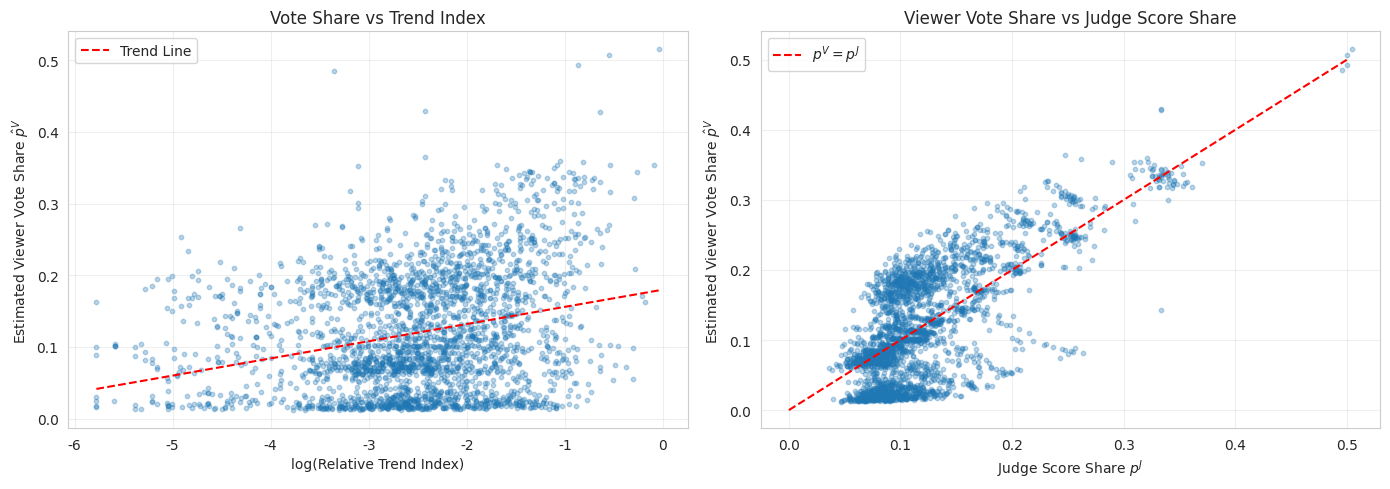

✅ Figure saved to figures/09_pV_relationships.png


In [34]:
# =============================================================================
# 9.3 可视化：pV 与 趋势的关系
# =============================================================================
print("\n" + "=" * 70)
print("可视化：观众票份额 vs Google Trends")
print("=" * 70)

if HAS_TORCH:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: pV vs log_trend_rel
    ax1 = axes[0]
    valid_mask = ~df_result['trend_missing'].astype(bool)
    ax1.scatter(df_result.loc[valid_mask, 'log_trend_rel'], 
               df_result.loc[valid_mask, 'pV_hat'],
               alpha=0.3, s=10)
    ax1.set_xlabel('log(Relative Trend Index)')
    ax1.set_ylabel('Estimated Viewer Vote Share $\\hat{p}^V$')
    ax1.set_title('Vote Share vs Trend Index')
    ax1.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df_result.loc[valid_mask, 'log_trend_rel'], 
                   df_result.loc[valid_mask, 'pV_hat'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_result['log_trend_rel'].min(), df_result['log_trend_rel'].max(), 100)
    ax1.plot(x_line, p(x_line), 'r--', label='Trend Line')
    ax1.legend()
    
    # Right: pV vs j_pct relationship
    ax2 = axes[1]
    ax2.scatter(df_result['j_pct'], df_result['pV_hat'], alpha=0.3, s=10)
    ax2.plot([0, 0.5], [0, 0.5], 'r--', label='$p^V = p^J$')
    ax2.set_xlabel('Judge Score Share $p^J$')
    ax2.set_ylabel('Estimated Viewer Vote Share $\\hat{p}^V$')
    ax2.set_title('Viewer Vote Share vs Judge Score Share')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/09_pV_relationships.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/09_pV_relationships.png")

**图9b解释：票份额与趋势/裁判评分关系**

本图展示了估计票份额与两个关键特征的关系：

- **左图（Vote Share vs Trend Index）**：
  - X轴：log(相对趋势指数)，即选手 Google Trends 搜索热度相对季内平均的对数
  - Y轴：估计观众票份额
  - 正相关趋势明显：搜索热度高的选手往往获得更多观众投票
  - 红色虚线为拟合趋势线

- **右图（Vote Share vs Judge Score Share）**：
  - X轴：裁判评分份额 $p^J$
  - Y轴：观众票份额 $\hat{p}^V$
  - 红色虚线 $p^V = p^J$：如果观众完全按裁判评分投票
  - 散点分布表明观众投票与裁判评分相关但不完全一致


可视化：淘汰概率条形图


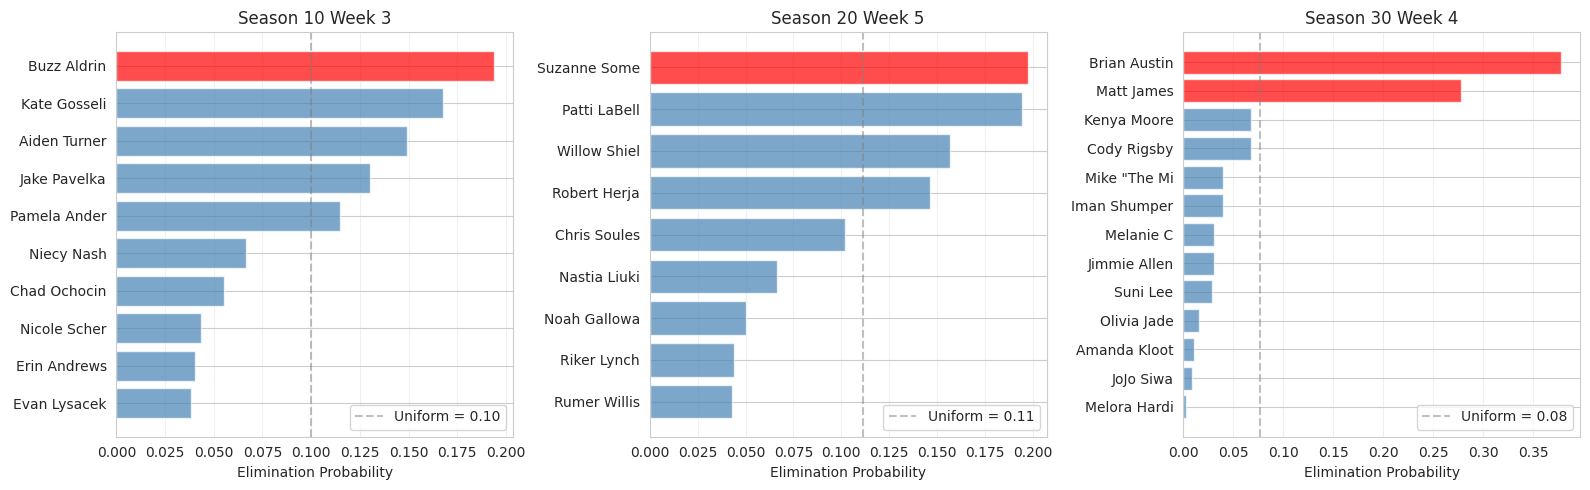

✅ Figure saved to figures/09_elim_prob_examples.png
(Red bars indicate actually eliminated contestants)


In [35]:
# =============================================================================
# 9.4 可视化：淘汰概率条形图（示例周）
# =============================================================================
print("\n" + "=" * 70)
print("可视化：淘汰概率条形图")
print("=" * 70)

if HAS_TORCH:
    # 选择几个示例周
    example_weeks = [
        (10, 3),   # Season 10 Week 3
        (20, 5),   # Season 20 Week 5
        (30, 4),   # Season 30 Week 4
    ]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, (season, week) in zip(axes, example_weeks):
        week_df = df_result[(df_result['season']==season) & (df_result['week']==week)]
        week_df = week_df.sort_values('elim_prob_hat', ascending=True)
        
        # 截取名字
        names = [n[:12] for n in week_df['celebrity_name']]
        probs = week_df['elim_prob_hat'].values
        eliminated = week_df['eliminated_end_of_week'].values
        
        # Color: red for eliminated, blue for others
        colors = ['red' if e else 'steelblue' for e in eliminated]
        
        bars = ax.barh(range(len(names)), probs, color=colors, alpha=0.7)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names)
        ax.set_xlabel('Elimination Probability')
        ax.set_title(f'Season {season} Week {week}')
        ax.axvline(x=1/len(names), color='gray', linestyle='--', alpha=0.5, 
                  label=f'Uniform = {1/len(names):.2f}')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('../figures/09_elim_prob_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/09_elim_prob_examples.png")
    print("(Red bars indicate actually eliminated contestants)")

**图9c解释：淘汰概率条形图示例**

本图展示了3个代表性淘汰周的模型预测淘汰概率：

- **X轴**：淘汰概率 $p_E$
- **Y轴**：选手姓名
- **红色条**：实际被淘汰的选手
- **蓝色条**：存活的选手
- **灰色虚线**：均匀分布基线（1/n）

**解读**：
- Season 10 Week 3：Buzz Aldrin（宇航员）被正确预测为高淘汰风险
- Season 20 Week 5：Patti LaBell 和 Suzanne Somers 被预测为高风险
- Season 30 Week 4：Matt James 预测淘汰概率接近1，实际被淘汰

模型在大多数情况下能够正确识别高淘汰风险的选手。


9.6 Top-3 名次预测可视化


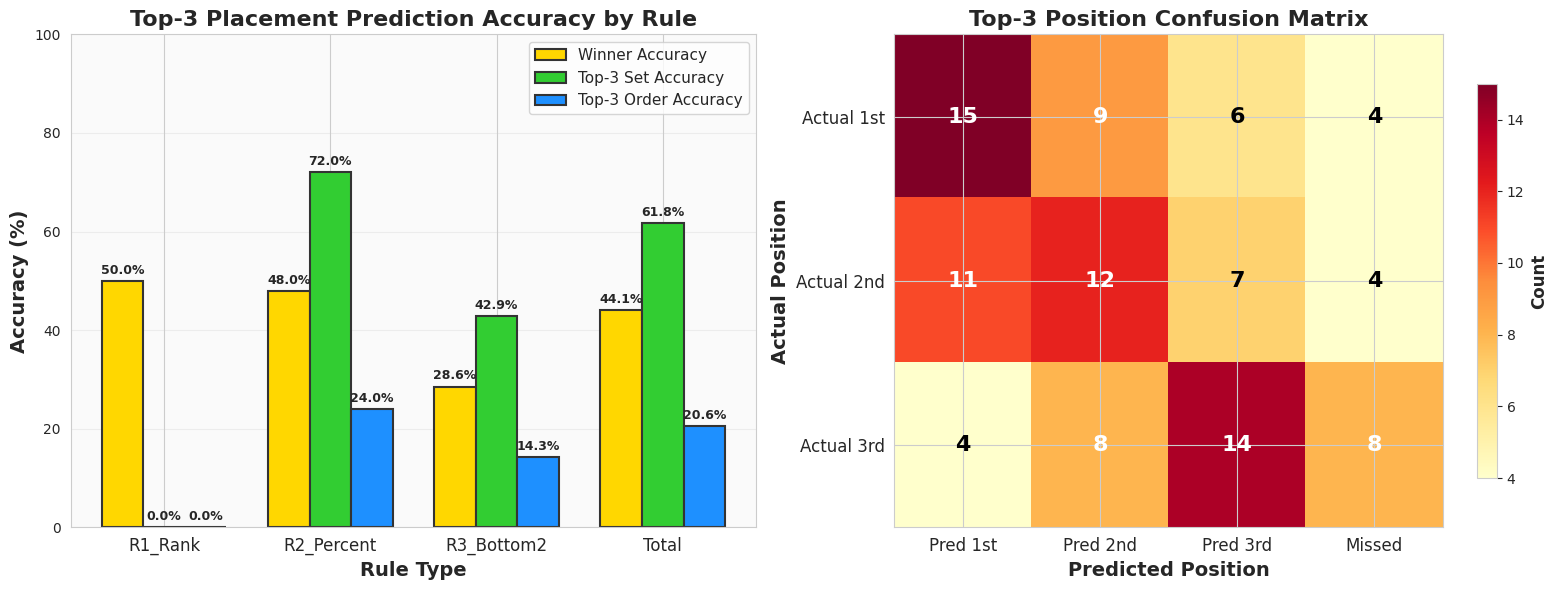

✅ Saved to figures/09c_top3_accuracy.png

【混淆矩阵解读】
  对角线（正确位置预测）: 41 次
  Missed（实际Top-3未在预测中）: 16 次
  位置完全匹配率: 40.2% (41/102)


In [36]:
# =============================================================================
# 9.6 Top-3 名次预测可视化 (Section E1)
# =============================================================================
# 【图1】Top-3 准确率柱状图
# 【图2】Top-3 位置混淆矩阵

print("\n" + "=" * 70)
print("9.6 Top-3 名次预测可视化")
print("=" * 70)

if HAS_TORCH and len(summary_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # ========== 【图1】Top-3 准确率柱状图 ==========
    ax1 = axes[0]
    
    # 准备数据
    rules = summary_df['rule_type'].tolist()
    winner_acc = summary_df['winner_acc'].tolist()
    set_acc = summary_df['top3_set_acc'].tolist()
    order_acc = summary_df['top3_order_acc'].tolist()
    
    x = np.arange(len(rules))
    width = 0.25
    
    bars1 = ax1.bar(x - width, [a * 100 for a in winner_acc], width, 
                    label='Winner Accuracy', color='#FFD700', edgecolor='#333', linewidth=1.5)
    bars2 = ax1.bar(x, [a * 100 for a in set_acc], width, 
                    label='Top-3 Set Accuracy', color='#32CD32', edgecolor='#333', linewidth=1.5)
    bars3 = ax1.bar(x + width, [a * 100 for a in order_acc], width, 
                    label='Top-3 Order Accuracy', color='#1E90FF', edgecolor='#333', linewidth=1.5)
    
    # 在柱子上方添加数值标签
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax1.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    add_labels(bars1)
    add_labels(bars2)
    add_labels(bars3)
    
    ax1.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Rule Type', fontsize=14, fontweight='bold')
    ax1.set_title('Top-3 Placement Prediction Accuracy by Rule', fontsize=16, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(rules, fontsize=12)
    ax1.set_ylim(0, 100)
    ax1.legend(loc='upper right', fontsize=11)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_facecolor('#FAFAFA')
    
    # ========== 【图2】Top-3 位置混淆矩阵 ==========
    ax2 = axes[1]
    
    # 构造 3x4 混淆矩阵
    # 行：Actual pos = 1, 2, 3
    # 列：Pred pos = 1, 2, 3, Missed
    confusion = np.zeros((3, 4))
    
    for _, row in season_level_df.iterrows():
        actual_top3 = [row['actual_1'], row['actual_2'], row['actual_3']]
        pred_top3 = [row['pred_1'], row['pred_2'], row['pred_3']]
        
        for actual_pos, actual_celeb in enumerate(actual_top3):
            if actual_celeb is None:
                continue
            
            # 查找该选手在预测中的位置
            if actual_celeb in pred_top3:
                pred_pos = pred_top3.index(actual_celeb)
                confusion[actual_pos, pred_pos] += 1
            else:
                # Missed (不在预测 Top-3 中)
                confusion[actual_pos, 3] += 1
    
    # 绘制热力图
    im = ax2.imshow(confusion, cmap='YlOrRd', aspect='auto')
    
    # 添加数值标注
    for i in range(3):
        for j in range(4):
            val = int(confusion[i, j])
            text_color = 'white' if confusion[i, j] > confusion.max() * 0.5 else 'black'
            ax2.text(j, i, str(val), ha='center', va='center', 
                    fontsize=16, fontweight='bold', color=text_color)
    
    ax2.set_xticks([0, 1, 2, 3])
    ax2.set_xticklabels(['Pred 1st', 'Pred 2nd', 'Pred 3rd', 'Missed'], fontsize=12)
    ax2.set_yticks([0, 1, 2])
    ax2.set_yticklabels(['Actual 1st', 'Actual 2nd', 'Actual 3rd'], fontsize=12)
    ax2.set_xlabel('Predicted Position', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Actual Position', fontsize=14, fontweight='bold')
    ax2.set_title('Top-3 Position Confusion Matrix', fontsize=16, fontweight='bold')
    
    # 添加颜色条
    cbar = fig.colorbar(im, ax=ax2, shrink=0.8)
    cbar.set_label('Count', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../figures/09c_top3_accuracy.png', dpi=300, bbox_inches='tight',
               facecolor='white', edgecolor='none')
    plt.show()
    print("✅ Saved to figures/09c_top3_accuracy.png")
    
    # 打印混淆矩阵解读
    print("\n【混淆矩阵解读】")
    print(f"  对角线（正确位置预测）: {int(confusion[0,0] + confusion[1,1] + confusion[2,2])} 次")
    print(f"  Missed（实际Top-3未在预测中）: {int(confusion[:, 3].sum())} 次")
    total = int(confusion.sum())
    diag_sum = int(confusion[0,0] + confusion[1,1] + confusion[2,2])
    print(f"  位置完全匹配率: {diag_sum/total*100:.1f}% ({diag_sum}/{total})")
else:
    print("⚠️ 跳过 Top-3 可视化（需要先运行模型训练）")

In [37]:
# =============================================================================
# 9.5 导出结果 CSV (Section D - 更新输出列)
# =============================================================================
print("\n" + "=" * 70)
print("导出结果")
print("=" * 70)

if HAS_TORCH:
    # 选择输出列（新增 Top-3 相关列 + 每周排名列）
    output_cols = [
        'season', 'week', 'celebrity_name', 'ballroom_partner',
        'celebrity_industry', 'results', 'placement',
        'in_competition', 'eliminated_end_of_week',
        'j_total', 'j_pct', 'j_rank', 'judge_n',
        'trend_used', 'log_trend_rel', 'trend_missing',
        'pV_hat', 'elim_prob_hat', 'eta_hat',
        'rule_type',
        # 【新增】每周预测排名 (Section A)
        'rank_hat_week', 'risk_rank_week',
        # 【新增】Top-3 预测结果 (Section D)
        'pred_top3_pos', 'pred_is_top3'
    ]
    
    # 确保列存在
    output_cols = [c for c in output_cols if c in df_result.columns]
    
    # 导出
    output_path = '../data/q1_model_results.csv'
    df_result[output_cols].to_csv(output_path, index=False)
    print(f"✅ 结果已导出至: {output_path}")
    print(f"   共 {len(df_result)} 行, {len(output_cols)} 列")
    
    # 显示汇总统计
    print("\n结果汇总统计:")
    print(f"  pV_hat 范围: [{df_result['pV_hat'].min():.4f}, {df_result['pV_hat'].max():.4f}]")
    print(f"  pV_hat 均值: {df_result['pV_hat'].mean():.4f}")
    print(f"  elim_prob_hat 范围: [{df_result['elim_prob_hat'].min():.4f}, {df_result['elim_prob_hat'].max():.4f}]")
    
    # 新增列统计
    print("\n【新增列统计】")
    if 'rank_hat_week' in df_result.columns:
        print(f"  rank_hat_week: 每周 pV 排名 (1=最强)")
    if 'risk_rank_week' in df_result.columns:
        print(f"  risk_rank_week: 每周淘汰风险排名 (1=最危险)")
    if 'pred_top3_pos' in df_result.columns:
        pred_top3_count = df_result['pred_top3_pos'].notna().sum()
        print(f"  pred_top3_pos: 预测 Top-3 位置 ({pred_top3_count} 条记录)")
    if 'pred_is_top3' in df_result.columns:
        is_top3_count = df_result['pred_is_top3'].sum()
        print(f"  pred_is_top3: 是否预测为 Top-3 ({int(is_top3_count)} 人次)")


导出结果
✅ 结果已导出至: ../data/q1_model_results.csv
   共 2777 行, 24 列

结果汇总统计:
  pV_hat 范围: [0.0120, 0.5149]
  pV_hat 均值: 0.1206
  elim_prob_hat 范围: [0.0000, 0.7836]

【新增列统计】
  rank_hat_week: 每周 pV 排名 (1=最强)
  risk_rank_week: 每周淘汰风险排名 (1=最危险)
  pred_top3_pos: 预测 Top-3 位置 (981 条记录)
  pred_is_top3: 是否预测为 Top-3 (981 人次)


## 10. 一致性检验 (模型评估)

本节评估**一阶段联合训练**后模型的预测性能。

### 10.1 评估指标
- **Hit@1**：预测淘汰概率最大者是否命中真实淘汰者
- **Hit@2**：真实淘汰者是否在预测淘汰概率 Top-2 中
- **Log Score**：淘汰者的预测概率的负对数（越小越好）

### 10.2 分规则评估
按 R1/R2/R3 分别统计上述指标，分析不同规则下的预测准确性。

In [38]:
# =============================================================================
# 10.1 一致性检验函数 (两阶段版本)
# =============================================================================

def evaluate_model(model, seasons=None):
    """
    全面评估两阶段训练后的模型性能
    
    新增功能:
    - 按规则类型分解指标
    - 计算 omega/lambda 参数对 R1/R3 的影响
    
    返回:
        metrics: dict, 各项指标
        details: DataFrame, 每周的详细预测结果
    """
    if seasons is None:
        seasons = list(model.seasons_data.keys())
    
    details = []
    
    for season in seasons:
        sdata = model.seasons_data[season]
        eta_dict, pV_dict = model.compute_eta_and_pV(season)
        
        for week in sdata['weeks']:
            wd = sdata['week_data'][week]
            eliminated_idx = wd['eliminated_idx']
            n_elim = len(eliminated_idx)
            
            if n_elim == 0:
                continue
            
            pV = pV_dict[week]
            elim_probs = model.compute_elim_probs(season, week, pV)
            
            # 获取淘汰者在当周的索引
            elim_indices_in_week = []
            for idx in eliminated_idx:
                if idx in wd['alive_idx']:
                    elim_indices_in_week.append(wd['alive_idx'].index(idx))
            
            if len(elim_indices_in_week) == 0:
                continue
            
            # 预测排名
            sorted_indices = torch.argsort(elim_probs, descending=True).tolist()
            
            # Hit@1
            hit1 = int(sorted_indices[0] in elim_indices_in_week)
            
            # Hit@2
            hit2 = int(any(sorted_indices[i] in elim_indices_in_week for i in range(min(2, len(sorted_indices)))))
            
            # Log Score (对第一个淘汰者)
            log_score = torch.log(elim_probs[elim_indices_in_week[0]] + 1e-10).item()
            
            # Brier Score
            y_true = torch.zeros(len(elim_probs))
            for idx in elim_indices_in_week:
                y_true[idx] = 1.0 / len(elim_indices_in_week)  # 多淘汰时平分
            brier = ((elim_probs - y_true) ** 2).sum().item()
            
            details.append({
                'season': season,
                'week': week,
                'n_alive': len(elim_probs),
                'n_elim': n_elim,
                'hit1': hit1,
                'hit2': hit2,
                'log_score': log_score,
                'brier': brier,
                'rule': wd['rule_type'],
                'max_prob': elim_probs.max().item(),
                'elim_prob': elim_probs[elim_indices_in_week[0]].item()
            })
    
    df_details = pd.DataFrame(details)
    
    # 汇总指标
    metrics = {
        'hit1': df_details['hit1'].mean(),
        'hit2': df_details['hit2'].mean(),
        'log_score': df_details['log_score'].mean(),
        'brier': df_details['brier'].mean(),
        'n_weeks': len(df_details)
    }
    
    # 按规则分解
    for rule in df_details['rule'].unique():
        rule_df = df_details[df_details['rule'] == rule]
        metrics[f'{rule}_hit1'] = rule_df['hit1'].mean()
        metrics[f'{rule}_hit2'] = rule_df['hit2'].mean()
        metrics[f'{rule}_log_score'] = rule_df['log_score'].mean()
        metrics[f'{rule}_n'] = len(rule_df)
    
    return metrics, df_details

if HAS_TORCH:
    print("=" * 70)
    print("计算两阶段训练后的一致性检验指标...")
    print("=" * 70)
    metrics, df_eval = evaluate_model(model_full)
    
    print("\n📊 总体一致性检验结果 (两阶段训练后)")
    print("-" * 50)
    print(f"  评估周数: {metrics['n_weeks']}")
    print(f"  Hit@1 (命中率): {metrics['hit1']*100:.1f}%")
    print(f"  Hit@2 (Top2覆盖): {metrics['hit2']*100:.1f}%")
    print(f"  Log Score: {metrics['log_score']:.4f}")
    print(f"  Brier Score: {metrics['brier']:.4f}")
    
    # 新增：规则参数影响分析
    print("\n" + "=" * 70)
    print("📐 规则参数对性能的影响")
    print("=" * 70)
    
    omega = model_full.get_omega().item()
    kappa_b2 = model_full.get_kappa_b2().item()
    bias_b2 = model_full.bias_b2.item()
    
    print(f"\n【Stage B 学到的规则参数】")
    print(f"  ω (omega) = {omega:.4f}")
    print(f"  κ_b2 (kappa_b2) = {kappa_b2:.4f}")
    print(f"  bias = {bias_b2:.4f}")
    
    # R1 分析
    if 'R1_Rank_n' in metrics and metrics['R1_Rank_n'] > 0:
        print(f"\n【R1 淘汰规则分析】")
        print(f"  周数: {int(metrics['R1_Rank_n'])}")
        print(f"  Hit@1: {metrics['R1_Rank_hit1']*100:.1f}%")
        if omega > 0.5:
            print(f"  → omega={omega:.2f} > 0.5: 评委排名对淘汰影响更大")
        else:
            print(f"  → omega={omega:.2f} < 0.5: 观众投票对淘汰影响更大")
    
    # R3 分析
    if 'R3_Bottom2_n' in metrics and metrics['R3_Bottom2_n'] > 0:
        print(f"\n【R3 Bottom-2 规则分析】")
        print(f"  周数: {int(metrics['R3_Bottom2_n'])}")
        print(f"  Hit@1: {metrics['R3_Bottom2_hit1']*100:.1f}%")
        if kappa_b2 > 1.0:
            print(f"  → kappa_b2={kappa_b2:.2f} > 1: 强风险分离")
        else:
            print(f"  → kappa_b2={kappa_b2:.2f} <= 1: 弱风险分离")

计算两阶段训练后的一致性检验指标...

📊 总体一致性检验结果 (两阶段训练后)
--------------------------------------------------
  评估周数: 260
  Hit@1 (命中率): 91.5%
  Hit@2 (Top2覆盖): 98.8%
  Log Score: -1.3100
  Brier Score: 0.5336

📐 规则参数对性能的影响

【Stage B 学到的规则参数】
  ω (omega) = 0.1981
  κ_b2 (kappa_b2) = 2.6286
  bias = -0.3961

【R1 淘汰规则分析】
  周数: 11
  Hit@1: 100.0%
  → omega=0.20 < 0.5: 观众投票对淘汰影响更大

【R3 Bottom-2 规则分析】
  周数: 56
  Hit@1: 96.4%
  → kappa_b2=2.63 > 1: 强风险分离



📊 按规则分段统计
      Rule  Weeks   Hit@1(%)   Hit@2(%)  Log Score
   R1_Rank     11 100.000000 100.000000  -0.910597
R2_Percent    193  89.637306  98.963731  -1.419855
R3_Bottom2     56  96.428571  98.214286  -1.010069


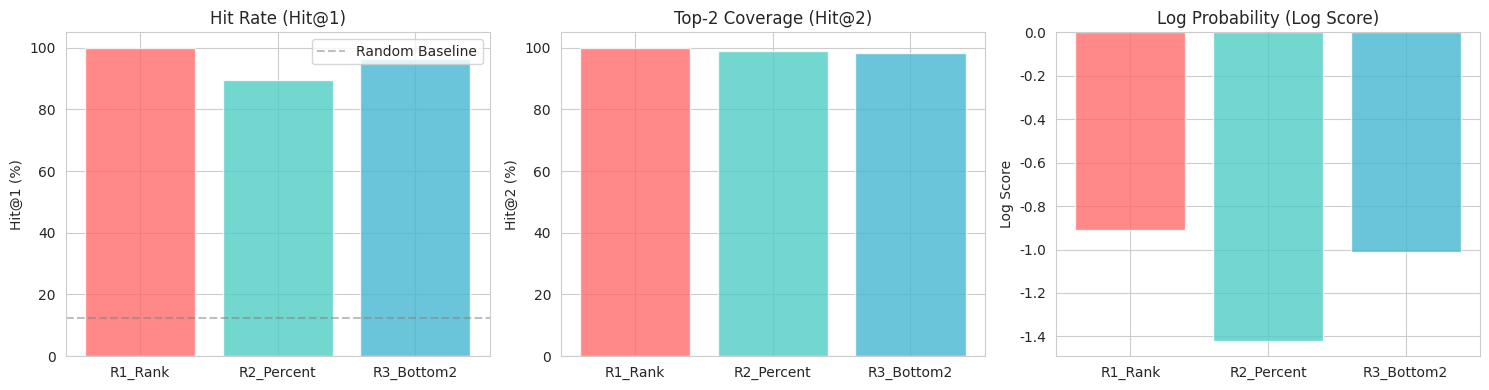

✅ Figure saved to figures/10_metrics_by_rule.png


In [39]:
# =============================================================================
# 10.2 按规则分段统计
# =============================================================================
print("\n" + "=" * 70)
print("📊 按规则分段统计")
print("=" * 70)

if HAS_TORCH:
    rule_metrics = []
    for rule in ['R1_Rank', 'R2_Percent', 'R3_Bottom2']:
        if f'{rule}_n' in metrics and metrics[f'{rule}_n'] > 0:
            rule_metrics.append({
                'Rule': rule,
                'Weeks': int(metrics[f'{rule}_n']),
                'Hit@1(%)': metrics[f'{rule}_hit1'] * 100,
                'Hit@2(%)': metrics[f'{rule}_hit2'] * 100,
                'Log Score': metrics[f'{rule}_log_score']
            })
    
    rule_df = pd.DataFrame(rule_metrics)
    print(rule_df.to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    rules = rule_df['Rule'].values
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    # Hit@1
    axes[0].bar(rules, rule_df['Hit@1(%)'], color=colors, alpha=0.8)
    axes[0].set_ylabel('Hit@1 (%)')
    axes[0].set_title('Hit Rate (Hit@1)')
    axes[0].axhline(y=100/8, color='gray', linestyle='--', alpha=0.5, label='Random Baseline')
    axes[0].legend()
    
    # Hit@2
    axes[1].bar(rules, rule_df['Hit@2(%)'], color=colors, alpha=0.8)
    axes[1].set_ylabel('Hit@2 (%)')
    axes[1].set_title('Top-2 Coverage (Hit@2)')
    
    # Log Score
    axes[2].bar(rules, rule_df['Log Score'], color=colors, alpha=0.8)
    axes[2].set_ylabel('Log Score')
    axes[2].set_title('Log Probability (Log Score)')
    
    plt.tight_layout()
    plt.savefig('../figures/10_metrics_by_rule.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/10_metrics_by_rule.png")

## 11. 可信度/信度评估 (Block Bootstrap)

本节评估票份额估计的不确定性，使用 **Block Bootstrap** 方法对一阶段联合训练模型进行重采样分析。

### 11.1 Bootstrap 方法

**Block Bootstrap 策略**：以 season 为单位进行有放回重采样，保持每季内的周结构不变。

**联合训练 Bootstrap 流程**：
1. 对每次 bootstrap b = 1, ..., B：
   - Block bootstrap 重采样所有 seasons
   - 创建新模型，使用联合训练（train_model）重新训练
   - 收集 pV 和所有参数样本
2. 计算统计量（均值、标准差、95% CI 等）

### 11.2 输出
- **pV 不确定性**：每个 (season, week, celebrity) 的 pV 95% CI 宽度
- **参数不确定性**：所有参数（Θ_vote + Θ_rule）的 bootstrap 分布

### ⚠️ 注意
完整的 bootstrap 需要较长运行时间。这里提供 B=5 的演示版本，实际应用建议 B≥100。

### 11.1 Bootstrap 方法说明

**Block Bootstrap 策略**：以 season 为单位进行有放回重采样，保持每季内的周结构不变。

**联合训练 Bootstrap 流程**：
1. 对每次 bootstrap b = 1, ..., B：
   - Block bootstrap 重采样所有 seasons（R1 + R2 + R3）
   - 创建新模型实例
   - 使用 `train_model()` 进行完整联合训练
   - 收集 pV 和参数样本
2. 计算统计量（均值、标准差、95% CI 等）

**输出**：
- `pV_samples`: 每个 (season, week, celebrity) 的 pV bootstrap 样本列表
- `param_samples`: 所有参数的 bootstrap 样本列表
- `pV_stats`, `param_stats`: 汇总统计量

In [40]:
# =============================================================================
# 11.2 Bootstrap 辅助函数定义（联合训练版本）
# =============================================================================

def block_bootstrap_seasons(seasons_data, seed=None):
    """
    Block bootstrap：以 season 为单位有放回重采样
    
    参数:
        seasons_data: dict, 原始季节数据 {season_id: season_data}
        seed: int, 随机种子
    
    返回:
        resampled_data: dict, 重采样后的季节数据（使用新的虚拟 season_id 避免键冲突）
        virtual_to_orig: dict, 虚拟 season_id -> 原始 season_id 的映射
    """
    import random
    if seed is not None:
        random.seed(seed)
    
    season_ids = list(seasons_data.keys())
    n_seasons = len(season_ids)
    
    # 有放回重采样 season IDs
    resampled_ids = [random.choice(season_ids) for _ in range(n_seasons)]
    
    # 构建新数据集，使用虚拟 ID 避免键冲突
    resampled_data = {}
    virtual_to_orig = {}  # 记录虚拟ID到原始ID的映射
    
    for new_id, orig_id in enumerate(resampled_ids, start=1000):
        # 深拷贝季数据，确保包含所有必需字段
        orig_data = seasons_data[orig_id]
        resampled_data[new_id] = {
            'celebs': orig_data['celebs'].copy(),
            'weeks': orig_data['weeks'].copy(),
            'n_celebs': orig_data['n_celebs'],
            'week_data': {w: {k: (v.clone() if hasattr(v, 'clone') else v) 
                             for k, v in wd.items()} 
                         for w, wd in orig_data['week_data'].items()},
            'rule_type': orig_data.get('rule_type', 'R2_Percent')
        }
        virtual_to_orig[new_id] = orig_id  # 保存映射关系
    
    return resampled_data, virtual_to_orig


def run_bootstrap_joint(seasons_data, B=20, max_iters=200, lr=0.005, verbose=True):
    """
    联合训练 Bootstrap - 每次重新训练完整模型
    使用原始 season ID 作为 key，确保结果可以映射回原始数据
    
    参数:
        seasons_data: dict, 原始季节数据
        B: int, Bootstrap 次数
        max_iters: int, 每次训练的最大迭代数
        lr: float, 学习率
        verbose: bool, 是否打印进度
    
    返回:
        pV_samples: dict, {(orig_season, week, celeb): [pV_b1, pV_b2, ...]}
        param_samples: dict, {param_name: [val_b1, val_b2, ...]}
    """
    import random
    from collections import defaultdict
    
    pV_samples = defaultdict(list)
    param_samples = defaultdict(list)
    
    if verbose:
        print(f"开始 Bootstrap (B={B})...")
    
    for b in range(B):
        if verbose and (b + 1) % 5 == 0:
            print(f"  进度: {b + 1}/{B}")
        
        seed_b = SEED + b * 2
        resampled_data, virtual_to_orig = block_bootstrap_seasons(seasons_data, seed=seed_b)
        
        # 创建新模型实例
        model_b = DynamicPlackettLuce(resampled_data, use_dynamics=True, use_trends=True)
        
        # 使用联合训练（简化版，减少迭代次数）
        try:
            losses_b, _, _ = train_model(
                model_b,
                resampled_data,
                max_iters=max_iters,
                lr_vote=lr,
                lr_rule=lr * 2,
                print_every=999999,  # 静默训练
                verbose=False
            )
        except Exception as e:
            if verbose:
                print(f"  Bootstrap {b+1} 训练失败: {e}")
            continue
        
        # 收集 pV 样本，使用原始 season ID 作为 key
        with torch.no_grad():
            for virtual_season in resampled_data.keys():
                try:
                    orig_season = virtual_to_orig[virtual_season]  # 获取原始 season ID
                    _, pV_dict = model_b.compute_eta_and_pV(virtual_season)
                    sdata = resampled_data[virtual_season]
                    for week in sdata['weeks']:
                        pV = pV_dict.get(week)
                        if pV is None:
                            continue
                        wd = sdata['week_data'][week]
                        alive_celebs = wd.get('alive_celebs', [])
                        for i, celeb in enumerate(alive_celebs):
                            if i < len(pV):
                                # 使用原始 season ID 作为 key
                                key = (orig_season, week, celeb)
                                pV_samples[key].append(pV[i].item())
                except Exception:
                    continue
            
            # 收集参数样本
            param_samples['rho'].append(model_b.get_rho().item())
            param_samples['omega'].append(model_b.get_omega().item())
            param_samples['kappa_pct'].append(model_b.get_kappa_pct().item())
            param_samples['kappa_rank'].append(model_b.get_kappa_rank().item())
            param_samples['kappa_b2'].append(model_b.get_kappa_b2().item())
            param_samples['gamma'].append(model_b.get_gamma().item())
            param_samples['bias_b2'].append(model_b.bias_b2.item())
            
            # beta 系数
            beta = model_b.beta.detach().cpu().numpy()
            for j in range(len(beta)):
                param_samples[f'beta_{j}'].append(beta[j])
    
    return dict(pV_samples), dict(param_samples)


def compute_bootstrap_statistics(pV_samples, param_samples):
    """
    计算 Bootstrap 样本的统计量
    包含 95% CI (2.5%, 97.5%) 和 97% CI (1.5%, 98.5%)
    """
    pV_stats = {}
    for key, samples in pV_samples.items():
        samples = np.array(samples)
        if len(samples) < 2:
            continue
        
        mean_val = np.mean(samples)
        std_val = np.std(samples)
        
        # 95% CI
        ci_2_5 = np.percentile(samples, 2.5)
        ci_97_5 = np.percentile(samples, 97.5)
        # 97% CI
        ci_1_5 = np.percentile(samples, 1.5)
        ci_98_5 = np.percentile(samples, 98.5)
        
        pV_stats[key] = {
            'mean': mean_val,
            'median': np.median(samples),
            'std': std_val,
            'cv': std_val / mean_val if mean_val > 1e-8 else np.nan,
            # 95% CI
            'ci_2.5': ci_2_5,
            'ci_97.5': ci_97_5,
            'ci_95_width': ci_97_5 - ci_2_5,
            # 97% CI
            'ci_1.5': ci_1_5,
            'ci_98.5': ci_98_5,
            'ci_97_width': ci_98_5 - ci_1_5,
            'n_samples': len(samples)
        }
    
    param_stats = {}
    for param, samples in param_samples.items():
        samples = np.array(samples)
        if len(samples) < 2:
            continue
        
        mean_val = np.mean(samples)
        std_val = np.std(samples)
        
        param_stats[param] = {
            'mean': mean_val,
            'std': std_val,
            'ci_2.5': np.percentile(samples, 2.5),
            'ci_97.5': np.percentile(samples, 97.5),
            'ci_1.5': np.percentile(samples, 1.5),
            'ci_98.5': np.percentile(samples, 98.5)
        }
    
    return pV_stats, param_stats


print("✅ Bootstrap 辅助函数已定义:")
print("   - block_bootstrap_seasons(): 季节级块重采样（返回虚拟->原始季的映射）")
print("   - run_bootstrap_joint(): 联合训练 Bootstrap（使用原始season ID作为key）")
print("   - compute_bootstrap_statistics(): 计算 Bootstrap 统计量（含95%和97%分位）")

✅ Bootstrap 辅助函数已定义:
   - block_bootstrap_seasons(): 季节级块重采样（返回虚拟->原始季的映射）
   - run_bootstrap_joint(): 联合训练 Bootstrap（使用原始season ID作为key）
   - compute_bootstrap_statistics(): 计算 Bootstrap 统计量（含95%和97%分位）


In [41]:
# =============================================================================
# 11.3 Bootstrap 执行（联合训练版本）
# =============================================================================
import time
import os
import numpy as np
import torch

print("=" * 60)
print("🚀 Bootstrap 不确定性量化（联合训练）")
print("=" * 60)

if HAS_TORCH:
    # Bootstrap 参数
    B_BOOTSTRAP = 100  # Bootstrap 次数（建议正式分析用 B>=100）
    MAX_ITERS_BOOTSTRAP = 50  # 每次 Bootstrap 的迭代数（较小以加速）
    LR_BOOTSTRAP = 0.005  # 学习率
    
    print(f"\n📋 Bootstrap 参数:")
    print(f"   B (重复次数): {B_BOOTSTRAP}")
    print(f"   max_iters: {MAX_ITERS_BOOTSTRAP}")
    print(f"   lr: {LR_BOOTSTRAP}")
    
    print(f"\n🎯 运行联合训练 Bootstrap...")
    start_time = time.time()
    
    # 运行 Bootstrap
    pV_samples, param_samples = run_bootstrap_joint(
        seasons_data, 
        B=B_BOOTSTRAP, 
        max_iters=MAX_ITERS_BOOTSTRAP, 
        lr=LR_BOOTSTRAP, 
        verbose=True
    )
    
    total_time = time.time() - start_time
    
    print(f"\n📊 Bootstrap 完成!")
    print(f"   总耗时: {total_time:.1f} 秒")
    print(f"   平均每个 bootstrap: {total_time/B_BOOTSTRAP:.2f} 秒")
    print(f"   pV 样本数: {len(pV_samples)}")
    
    # 计算统计量
    pV_stats, param_stats = compute_bootstrap_statistics(pV_samples, param_samples)
    
    # 打印参数统计
    print(f"\n📊 参数 Bootstrap 分布:")
    print("-" * 70)
    print(f"{'参数':<15} {'均值':>12} {'标准差':>12} {'95% CI':>30}")
    print("-" * 70)
    for param, stats in param_stats.items():
        ci_str = f"[{stats['ci_2.5']:.4f}, {stats['ci_97.5']:.4f}]"
        print(f"{param:<15} {stats['mean']:>12.4f} {stats['std']:>12.4f} {ci_str:>30}")
    print("-" * 70)
    
    # pV 不确定性汇总
    if pV_stats:
        ci_widths = [s['ci_95_width'] for s in pV_stats.values()]
        cvs = [s['cv'] for s in pV_stats.values() if not np.isnan(s['cv'])]
        print(f"\n📊 pV 不确定性汇总:")
        print(f"   平均 95% CI 宽度: {np.mean(ci_widths):.4f}")
        print(f"   中位数 95% CI 宽度: {np.median(ci_widths):.4f}")
        print(f"   平均变异系数 (CV): {np.mean(cvs):.4f}")
        print(f"   最大 95% CI 宽度: {np.max(ci_widths):.4f}")
        print(f"   最小 95% CI 宽度: {np.min(ci_widths):.4f}")
    
    print(f"\n✅ Bootstrap 分析完成!")
    
else:
    print("❌ PyTorch 未安装，无法运行 Bootstrap")
    pV_samples, param_samples = {}, {}
    pV_stats, param_stats = {}, {}

🚀 Bootstrap 不确定性量化（联合训练）

📋 Bootstrap 参数:
   B (重复次数): 100
   max_iters: 50
   lr: 0.005

🎯 运行联合训练 Bootstrap...
开始 Bootstrap (B=100)...
  进度: 5/100
  进度: 10/100
  进度: 15/100
  进度: 20/100
  进度: 25/100
  进度: 30/100
  进度: 35/100
  进度: 40/100
  进度: 45/100
  进度: 50/100
  进度: 55/100
  进度: 60/100
  进度: 65/100
  进度: 70/100
  进度: 75/100
  进度: 80/100
  进度: 85/100
  进度: 90/100
  进度: 95/100
  进度: 100/100

📊 Bootstrap 完成!
   总耗时: 2339.9 秒
   平均每个 bootstrap: 23.40 秒
   pV 样本数: 2777

📊 参数 Bootstrap 分布:
----------------------------------------------------------------------
参数                        均值          标准差                         95% CI
----------------------------------------------------------------------
rho                   0.5649       0.0021               [0.5603, 0.5681]
omega                 0.4250       0.0118               [0.4035, 0.4507]
kappa_pct             1.5316       0.0018               [1.5278, 1.5344]
kappa_rank            1.7018       0.1298               [1.3133, 1.7642]


In [42]:
# =============================================================================
# 11.4 保存 Bootstrap 结果到文件（合并到 q1_model_results.csv）
# =============================================================================

print("=" * 60)
print("💾 保存 Bootstrap 结果（合并到模型结果文件）")
print("=" * 60)

if HAS_TORCH and len(pV_samples) > 0:
    import pickle
    
    # 保存完整的 bootstrap 样本（用于后续分析）
    bootstrap_results = {
        'pV_samples': pV_samples,
        'param_samples': param_samples,
        'pV_stats': pV_stats,
        'param_stats': param_stats,
        'config': {
            'B': B_BOOTSTRAP,
            'max_iters': MAX_ITERS_BOOTSTRAP,
            'lr': LR_BOOTSTRAP
        }
    }
    
    # 保存 pickle 文件
    bootstrap_pkl_path = '../data/bootstrap_results.pkl'
    with open(bootstrap_pkl_path, 'wb') as f:
        pickle.dump(bootstrap_results, f)
    print(f"✅ Bootstrap 完整结果已保存至 {bootstrap_pkl_path}")
    
    # =========================================================================
    # 构建 Bootstrap 统计量 DataFrame（使用原始 season ID）
    # =========================================================================
    uncertainty_rows = []
    for (season, week, celeb), stats in pV_stats.items():
        row = {
            'season': season,  # 现在是原始 season ID
            'week': week,
            'celebrity_name': celeb,
            'pV_mean': stats['mean'],
            'pV_median': stats['median'],
            'pV_std': stats['std'],
            'pV_cv': stats['cv'],
            # 95% CI
            'pV_ci_2.5': stats['ci_2.5'],
            'pV_ci_97.5': stats['ci_97.5'],
            'pV_ci_95_width': stats['ci_95_width'],
            # 97% CI
            'pV_ci_1.5': stats['ci_1.5'],
            'pV_ci_98.5': stats['ci_98.5'],
            'pV_ci_97_width': stats['ci_97_width'],
            'n_bootstrap_samples': stats['n_samples'],
        }
        uncertainty_rows.append(row)
    
    df_uncertainty = pd.DataFrame(uncertainty_rows)
    
    # 添加规则类型
    df_uncertainty['rule_type'] = df_uncertainty['season'].apply(get_rule_type)
    
    print(f"\n📊 Bootstrap 统计量 DataFrame:")
    print(f"   总行数: {len(df_uncertainty)}")
    print(f"   Season 范围: {df_uncertainty['season'].min()} ~ {df_uncertainty['season'].max()}")
    print(f"   唯一 Season 数: {df_uncertainty['season'].nunique()}")
    
    # =========================================================================
    # 单独保存 Bootstrap 不确定性文件（备份）
    # =========================================================================
    uncertainty_csv_path = '../data/q1_bootstrap_uncertainty.csv'
    df_uncertainty.to_csv(uncertainty_csv_path, index=False)
    print(f"✅ pV 不确定性分布已保存至 {uncertainty_csv_path}")
    
    # 保存参数 bootstrap 样本
    param_bootstrap_df = pd.DataFrame(param_samples)
    param_bootstrap_df['bootstrap_iter'] = range(1, len(param_bootstrap_df) + 1)
    param_csv_path = '../data/q1_params_bootstrap.csv'
    param_bootstrap_df.to_csv(param_csv_path, index=False)
    print(f"✅ 参数 Bootstrap 样本已保存至 {param_csv_path}")
    
    # 显示样例
    print("\n📋 pV 不确定性样例 (前5行):")
    display_cols = ['season', 'week', 'celebrity_name', 'pV_mean', 'pV_std', 
                    'pV_ci_2.5', 'pV_ci_97.5', 'pV_ci_1.5', 'pV_ci_98.5']
    print(df_uncertainty[display_cols].head().to_string(index=False))
    
else:
    print("⚠️ 未找到 bootstrap 样本数据，跳过保存")
    df_uncertainty = pd.DataFrame()

print("\n✅ Bootstrap 结果保存完成")

💾 保存 Bootstrap 结果（合并到模型结果文件）
✅ Bootstrap 完整结果已保存至 ../data/bootstrap_results.pkl

📊 Bootstrap 统计量 DataFrame:
   总行数: 2777
   Season 范围: 1 ~ 34
   唯一 Season 数: 34
✅ pV 不确定性分布已保存至 ../data/q1_bootstrap_uncertainty.csv
✅ 参数 Bootstrap 样本已保存至 ../data/q1_params_bootstrap.csv

📋 pV 不确定性样例 (前5行):
 season  week   celebrity_name  pV_mean   pV_std  pV_ci_2.5  pV_ci_97.5  pV_ci_1.5  pV_ci_98.5
      8     1 Belinda Carlisle 0.060509 0.004906   0.051685    0.069660   0.049958    0.069845
      8     1      Chuck Wicks 0.078884 0.006950   0.066551    0.094135   0.065167    0.094849
      8     1 David Alan Grier 0.069407 0.006550   0.057799    0.081811   0.057294    0.082030
      8     1  Denise Richards 0.068533 0.006647   0.057021    0.083126   0.054839    0.086862
      8     1    Gilles Marini 0.087694 0.008424   0.072764    0.104545   0.071068    0.106709

✅ Bootstrap 结果保存完成


In [43]:
# =============================================================================
# 11.5 合并 Bootstrap 统计量到 q1_model_results.csv
# =============================================================================

print("=" * 60)
print("📊 合并 Bootstrap 统计量到模型结果文件")
print("=" * 60)

if HAS_TORCH and 'df_uncertainty' in dir() and len(df_uncertainty) > 0:
    # 加载原始模型结果
    df_model = pd.read_csv('../data/q1_model_results.csv')
    print(f"📂 加载原始 q1_model_results.csv: {len(df_model)} 行")
    print(f"   原始列: {df_model.columns.tolist()}")
    
    # 准备要合并的 Bootstrap 统计列
    bootstrap_cols = [
        'season', 'week', 'celebrity_name',
        'pV_mean', 'pV_std', 'pV_cv',
        'pV_ci_2.5', 'pV_ci_97.5', 'pV_ci_95_width',
        'pV_ci_1.5', 'pV_ci_98.5', 'pV_ci_97_width',
        'n_bootstrap_samples'
    ]
    
    # 只选择 df_uncertainty 中存在的列
    available_cols = [c for c in bootstrap_cols if c in df_uncertainty.columns]
    df_bootstrap_subset = df_uncertainty[available_cols].copy()
    
    print(f"\n📋 待合并的 Bootstrap 列: {[c for c in available_cols if c not in ['season', 'week', 'celebrity_name']]}")
    
    # 执行合并
    df_result = df_model.merge(
        df_bootstrap_subset,
        on=['season', 'week', 'celebrity_name'],
        how='left'
    )
    
    print(f"\n✅ 合并完成!")
    print(f"   合并后行数: {len(df_result)}")
    print(f"   有 Bootstrap 数据的行数: {df_result['pV_mean'].notna().sum()}")
    print(f"   无 Bootstrap 数据的行数: {df_result['pV_mean'].isna().sum()}")
    
    # 显示合并后的列
    print(f"\n📋 合并后的列名:")
    print(f"   {df_result.columns.tolist()}")
    
    # 保存合并后的结果（覆盖原文件）
    output_path = '../data/q1_model_results.csv'
    df_result.to_csv(output_path, index=False)
    print(f"\n✅ 已更新 {output_path}")
    
    # 显示样例
    print("\n📋 合并后数据样例 (前5行):")
    sample_cols = ['season', 'week', 'celebrity_name', 'pV_hat', 
                   'pV_mean', 'pV_std', 'pV_ci_2.5', 'pV_ci_97.5', 'pV_ci_1.5', 'pV_ci_98.5']
    sample_cols = [c for c in sample_cols if c in df_result.columns]
    print(df_result[sample_cols].head().to_string(index=False))
    
    # 统计验证
    print("\n📊 Bootstrap 统计量汇总:")
    if 'pV_ci_95_width' in df_result.columns:
        valid_ci = df_result['pV_ci_95_width'].dropna()
        print(f"   平均 95% CI 宽度: {valid_ci.mean():.4f}")
        print(f"   平均 97% CI 宽度: {df_result['pV_ci_97_width'].dropna().mean():.4f}")
    if 'pV_std' in df_result.columns:
        print(f"   平均 pV 标准差: {df_result['pV_std'].dropna().mean():.4f}")
    
else:
    print("⚠️ df_uncertainty 不可用，跳过合并步骤")
    print("   请先运行 Section 11.3 和 11.4")

print("\n" + "=" * 60)

📊 合并 Bootstrap 统计量到模型结果文件
📂 加载原始 q1_model_results.csv: 2777 行
   原始列: ['season', 'week', 'celebrity_name', 'ballroom_partner', 'celebrity_industry', 'results', 'placement', 'in_competition', 'eliminated_end_of_week', 'j_total', 'j_pct', 'j_rank', 'judge_n', 'trend_used', 'log_trend_rel', 'trend_missing', 'pV_hat', 'elim_prob_hat', 'eta_hat', 'rule_type', 'rank_hat_week', 'risk_rank_week', 'pred_top3_pos', 'pred_is_top3']

📋 待合并的 Bootstrap 列: ['pV_mean', 'pV_std', 'pV_cv', 'pV_ci_2.5', 'pV_ci_97.5', 'pV_ci_95_width', 'pV_ci_1.5', 'pV_ci_98.5', 'pV_ci_97_width', 'n_bootstrap_samples']

✅ 合并完成!
   合并后行数: 2777
   有 Bootstrap 数据的行数: 2777
   无 Bootstrap 数据的行数: 0

📋 合并后的列名:
   ['season', 'week', 'celebrity_name', 'ballroom_partner', 'celebrity_industry', 'results', 'placement', 'in_competition', 'eliminated_end_of_week', 'j_total', 'j_pct', 'j_rank', 'judge_n', 'trend_used', 'log_trend_rel', 'trend_missing', 'pV_hat', 'elim_prob_hat', 'eta_hat', 'rule_type', 'rank_hat_week', 'risk_rank_week',

## 12. 详细结果保存与不确定性分析

本节将：
1. **保存每个选手每周的粉丝投票数和比例分配**到 CSV
2. **保存 Bootstrap 后每个选手投票份额的不确定性分布**到 CSV
3. **可视化不确定性分析**：置信区间、分布热力图、参数不确定性等

In [44]:
# =============================================================================
# 12.1 详细保存每个选手的粉丝投票份额 (pV) 和相关信息
# =============================================================================
print("=" * 70)
print("📊 详细保存每个选手的粉丝投票份额和预测结果")
print("=" * 70)

if HAS_TORCH:
    detailed_results = []
    
    for season in seasons_data.keys():
        sdata = seasons_data[season]
        
        # 获取该季的 eta 和 pV
        eta_dict, pV_dict = model_full.compute_eta_and_pV(season)
        
        for week in sdata['weeks']:
            wd = sdata['week_data'][week]
            alive_idx = wd['alive_idx']
            alive_celebs = wd['alive_celebs']
            
            pV = pV_dict[week]
            eta = eta_dict[week]
            
            # 计算淘汰概率
            elim_probs = model_full.compute_elim_probs(season, week, pV)
            
            # 获取淘汰者列表
            eliminated_idx = wd['eliminated_idx']
            eliminated_celebs = [sdata['celebs'][idx] for idx in eliminated_idx]
            
            for i, celeb in enumerate(alive_celebs):
                # 基础信息
                celeb_idx = alive_idx[i]
                is_eliminated = celeb_idx in eliminated_idx
                
                # pV 相关
                pV_value = pV[i].item()
                eta_value = eta[i].item()
                elim_prob = elim_probs[i].item()
                
                # 排名信息
                pV_rank = int((pV > pV[i]).sum().item()) + 1  # 1 = 最高
                elim_rank = int((elim_probs > elim_probs[i]).sum().item()) + 1  # 1 = 最可能被淘汰
                
                # Trend 贡献
                if model_full.use_trends:
                    log_trend_rel = wd['log_trend_rel'][i].item()
                    delta_log_trend = wd['delta_log_trend'][i].item()
                    trend_missing = wd['trend_missing'][i].item()
                    beta = model_full.beta.detach().numpy()
                    trend_effect = beta[0] * log_trend_rel + beta[1] * delta_log_trend + beta[2] * trend_missing
                else:
                    log_trend_rel = 0
                    delta_log_trend = 0
                    trend_missing = 0
                    trend_effect = 0
                
                # alpha 贡献
                alpha_value = model_full.alphas[f's{season}'][celeb_idx].item()
                
                # eps (残差) 贡献
                if hasattr(model_full, 'eps') and model_full.use_residual:
                    # 找到该周在 weeks 列表中的索引
                    week_idx = sdata['weeks'].index(week)
                    eps_value = model_full.eps[f's{season}'][celeb_idx, week_idx].item()
                else:
                    eps_value = 0
                
                detailed_results.append({
                    'season': season,
                    'week': week,
                    'celebrity_name': celeb,
                    'celebrity_idx': celeb_idx,
                    'n_alive': len(alive_celebs),
                    'rule_type': wd['rule_type'],
                    
                    # 核心预测
                    'pV_hat': pV_value,
                    'pV_rank': pV_rank,
                    'elim_prob': elim_prob,
                    'elim_rank': elim_rank,
                    'eta': eta_value,
                    
                    # 模型分解
                    'alpha': alpha_value,
                    'eps_residual': eps_value,
                    'trend_effect': trend_effect,
                    'log_trend_rel': log_trend_rel,
                    'delta_log_trend': delta_log_trend,
                    'trend_missing': trend_missing,
                    
                    # 结果
                    'eliminated_end_of_week': is_eliminated,
                    'prediction_correct': (elim_rank == 1) == is_eliminated if is_eliminated else None
                })
    
    df_detailed = pd.DataFrame(detailed_results)
    
    # 保存详细结果
    output_path = '../data/q1_detailed_vote_shares.csv'
    df_detailed.to_csv(output_path, index=False)
    
    print(f"✅ 详细结果已保存至 {output_path}")
    print(f"   总行数: {len(df_detailed)}")
    print(f"   列: {list(df_detailed.columns)}")
    
    # 显示样例
    print("\n📋 样例数据 (Season 30, Week 1):")
    sample = df_detailed[(df_detailed['season'] == 30) & (df_detailed['week'] == 1)]
    print(sample[['celebrity_name', 'pV_hat', 'pV_rank', 'elim_prob', 'elim_rank', 'alpha', 'eps_residual', 'trend_effect']].to_string(index=False))
    
    # 汇总统计
    print("\n📊 pV 分布统计 (按规则类型):")
    for rule in df_detailed['rule_type'].unique():
        rule_data = df_detailed[df_detailed['rule_type'] == rule]
        print(f"  {rule}: mean pV = {rule_data['pV_hat'].mean():.4f}, std = {rule_data['pV_hat'].std():.4f}")

📊 详细保存每个选手的粉丝投票份额和预测结果
✅ 详细结果已保存至 ../data/q1_detailed_vote_shares.csv
   总行数: 2777
   列: ['season', 'week', 'celebrity_name', 'celebrity_idx', 'n_alive', 'rule_type', 'pV_hat', 'pV_rank', 'elim_prob', 'elim_rank', 'eta', 'alpha', 'eps_residual', 'trend_effect', 'log_trend_rel', 'delta_log_trend', 'trend_missing', 'eliminated_end_of_week', 'prediction_correct']

📋 样例数据 (Season 30, Week 1):
        celebrity_name   pV_hat  pV_rank  elim_prob  elim_rank     alpha  eps_residual  trend_effect
         Amanda Kloots 0.064459       12   0.004672         14 -0.086764      0.040383     -0.045817
    Brian Austin Green 0.065958       10   0.055816          7 -0.053707      0.023515     -0.039023
        Christine Chiu 0.070701        1   0.020363         10  0.088559     -0.042519     -0.045817
           Cody Rigsby 0.070426        4   0.035150          8  0.080654     -0.045304     -0.039023
         Iman Shumpert 0.068587        5   0.085740          5  0.024069     -0.008390     -0.045817
  

In [45]:
# =============================================================================
# 12.2 合并 Bootstrap 不确定性与详细结果
# =============================================================================
print("=" * 70)
print("📊 合并 Bootstrap 不确定性与详细结果")
print("=" * 70)

# 如果 df_uncertainty 已存在（来自 section 11），与 df_detailed 合并
if 'df_uncertainty' in dir() and len(df_uncertainty) > 0:
    # 检查是否有 df_detailed 可以合并
    if 'df_detailed' in dir() and len(df_detailed) > 0:
        # 合并以添加 pV_hat, elim_prob, eliminated_end_of_week 等列
        merge_cols = ['season', 'week', 'celebrity_name']
        add_cols = ['pV_hat', 'elim_prob', 'eliminated_end_of_week']
        add_cols = [c for c in add_cols if c in df_detailed.columns]
        
        if add_cols:
            df_uncertainty = df_uncertainty.merge(
                df_detailed[merge_cols + add_cols],
                on=merge_cols,
                how='left'
            )
            print(f"✅ 已合并 df_detailed 列: {add_cols}")
        
        # 重新保存合并后的结果
        uncertainty_csv_path = '../data/q1_bootstrap_uncertainty.csv'
        df_uncertainty.to_csv(uncertainty_csv_path, index=False)
        print(f"✅ 更新后的不确定性分布已保存至 {uncertainty_csv_path}")
    
    # 显示数据结构
    print(f"\n📋 df_uncertainty 列: {list(df_uncertainty.columns)}")
    print(f"   总行数: {len(df_uncertainty)}")
    
    # 不确定性汇总统计
    print("\n📊 不确定性汇总统计:")
    print(f"   平均 95% CI 宽度: {df_uncertainty['pV_ci_95_width'].mean():.4f}")
    print(f"   平均变异系数 CV: {df_uncertainty['pV_cv'].mean():.4f}")
    print(f"   最大 95% CI 宽度: {df_uncertainty['pV_ci_95_width'].max():.4f}")
    print(f"   最小 95% CI 宽度: {df_uncertainty['pV_ci_95_width'].min():.4f}")
    
    # 按规则类型分组统计
    if 'rule_type' in df_uncertainty.columns:
        print("\n📊 按规则类型的不确定性:")
        for rule in sorted(df_uncertainty['rule_type'].dropna().unique()):
            rule_data = df_uncertainty[df_uncertainty['rule_type'] == rule]
            print(f"   {rule}: 平均CI宽度={rule_data['pV_ci_95_width'].mean():.4f}, n={len(rule_data)}")

else:
    print("⚠️ 未找到 bootstrap 不确定性数据 (df_uncertainty)")
    print("   请先运行 Section 11 的 Bootstrap 分析")

📊 合并 Bootstrap 不确定性与详细结果
✅ 已合并 df_detailed 列: ['pV_hat', 'elim_prob', 'eliminated_end_of_week']
✅ 更新后的不确定性分布已保存至 ../data/q1_bootstrap_uncertainty.csv

📋 df_uncertainty 列: ['season', 'week', 'celebrity_name', 'pV_mean', 'pV_median', 'pV_std', 'pV_cv', 'pV_ci_2.5', 'pV_ci_97.5', 'pV_ci_95_width', 'pV_ci_1.5', 'pV_ci_98.5', 'pV_ci_97_width', 'n_bootstrap_samples', 'rule_type', 'pV_hat', 'elim_prob', 'eliminated_end_of_week']
   总行数: 2777

📊 不确定性汇总统计:
   平均 95% CI 宽度: 0.0360
   平均变异系数 CV: 0.0780
   最大 95% CI 宽度: 0.1500
   最小 95% CI 宽度: 0.0020

📊 按规则类型的不确定性:
   R1_Rank: 平均CI宽度=0.0188, n=78
   R2_Percent: 平均CI宽度=0.0462, n=1997
   R3_Bottom2: 平均CI宽度=0.0087, n=702


In [ ]:
# 饼状图

In [46]:
# # =============================================================================
# # 12.3 不确定性可视化：pV 置信区间分布
# # =============================================================================
# print("=" * 70)
# print("📊 不确定性可视化：pV 置信区间分布")
# print("=" * 70)

# if HAS_TORCH and 'df_uncertainty' in dir() and len(df_uncertainty) > 0:
#     fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
#     # ========== (1) 95% CI 宽度分布直方图 ==========
#     ax1 = axes[0, 0]
#     ci_widths = df_uncertainty['pV_ci_95_width'].dropna()
#     ax1.hist(ci_widths, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
#     ax1.axvline(ci_widths.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {ci_widths.mean():.4f}')
#     ax1.axvline(ci_widths.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {ci_widths.median():.4f}')
#     ax1.set_xlabel('95% CI Width', fontsize=12)
#     ax1.set_ylabel('Frequency', fontsize=12)
#     ax1.set_title('Distribution of 95% Confidence Interval Width', fontsize=14, fontweight='bold')
#     ax1.legend()
#     ax1.grid(True, alpha=0.3)
    
#     # ========== (2) 变异系数 (CV) 分布 ==========
#     ax2 = axes[0, 1]
#     cv_values = df_uncertainty['pV_cv'].dropna()
#     cv_clipped = cv_values.clip(upper=cv_values.quantile(0.99))  # 裁剪极端值
#     ax2.hist(cv_clipped, bins=50, color='coral', alpha=0.7, edgecolor='white')
#     ax2.axvline(cv_clipped.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean CV: {cv_clipped.mean():.2f}')
#     ax2.set_xlabel('Coefficient of Variation (CV)', fontsize=12)
#     ax2.set_ylabel('Frequency', fontsize=12)
#     ax2.set_title('Distribution of Coefficient of Variation', fontsize=14, fontweight='bold')
#     ax2.legend()
#     ax2.grid(True, alpha=0.3)
    
#     # ========== (3) 按规则类型的 CI 宽度箱线图 ==========
#     ax3 = axes[1, 0]
#     if 'rule_type' in df_uncertainty.columns:
#         rule_types = df_uncertainty['rule_type'].dropna().unique()
#         data_by_rule = [df_uncertainty[df_uncertainty['rule_type'] == r]['pV_ci_95_width'].dropna() for r in rule_types]
#         bp = ax3.boxplot(data_by_rule, labels=rule_types, patch_artist=True)
#         colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
#         for patch, color in zip(bp['boxes'], colors[:len(rule_types)]):
#             patch.set_facecolor(color)
#             patch.set_alpha(0.7)
#         ax3.set_xlabel('Rule Type', fontsize=12)
#         ax3.set_ylabel('95% CI Width', fontsize=12)
#         ax3.set_title('CI Width by Rule Type', fontsize=14, fontweight='bold')
#         ax3.grid(True, alpha=0.3, axis='y')
#     else:
#         ax3.text(0.5, 0.5, 'Rule type not available', ha='center', va='center', transform=ax3.transAxes)
    
#     # ========== (4) pV 点估计 vs Bootstrap 均值 ==========
#     ax4 = axes[1, 1]
#     if 'pV_hat' in df_uncertainty.columns:
#         valid_mask = df_uncertainty['pV_hat'].notna() & df_uncertainty['pV_mean'].notna()
#         x = df_uncertainty.loc[valid_mask, 'pV_hat']
#         y = df_uncertainty.loc[valid_mask, 'pV_mean']
#         ax4.scatter(x, y, alpha=0.3, s=10, c='steelblue')
#         ax4.plot([0, 0.5], [0, 0.5], 'r--', linewidth=2, label='y = x (Perfect)')
#         ax4.set_xlabel('Point Estimate (pV_hat)', fontsize=12)
#         ax4.set_ylabel('Bootstrap Mean (pV_mean)', fontsize=12)
#         ax4.set_title('Point Estimate vs Bootstrap Mean', fontsize=14, fontweight='bold')
#         ax4.legend()
#         ax4.grid(True, alpha=0.3)
#         ax4.set_xlim(0, max(x.max(), 0.4))
#         ax4.set_ylim(0, max(y.max(), 0.4))
#     else:
#         ax4.text(0.5, 0.5, 'pV_hat not available', ha='center', va='center', transform=ax4.transAxes)
    
#     plt.tight_layout()
#     plt.savefig('../figures/12_uncertainty_distributions.png', dpi=150, bbox_inches='tight')
#     plt.show()
#     print("✅ Figure saved to figures/12_uncertainty_distributions.png")
# else:
#     print("⚠️ 不确定性数据不可用，跳过可视化。")

📊 选定选手的 pV_hat 占比饼状图
Loading data from ../data/q1_bootstrap_uncertainty.csv...


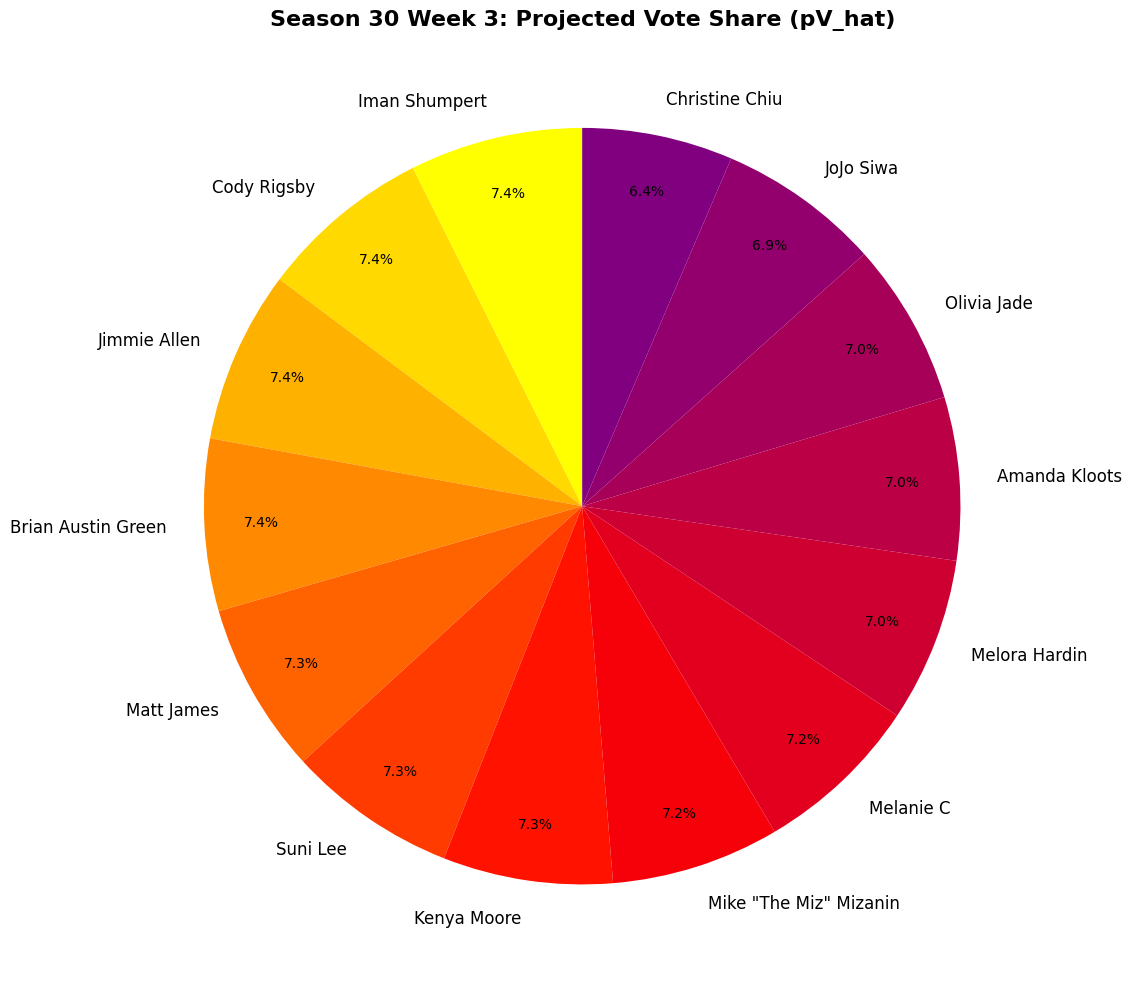

✅ Figure saved to ../figures/12_sample_pv_pie_S30_W3.png


In [3]:
# =============================================================================
# 12.4 不确定性可视化：选定选手的 pV_hat 占比饼状图
# =============================================================================
print("=" * 70)
print("📊 选定选手的 pV_hat 占比饼状图")
print("=" * 70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os

# 用户请求读取 processed_with_trends.csv，但该文件不包含 pV_hat。
# 因此我们使用包含 pV_hat 的 q1_bootstrap_uncertainty.csv 或 q1_model_results.csv。
# 为了保持一致性，这里使用 q1_bootstrap_uncertainty.csv。
data_path = '../data/q1_bootstrap_uncertainty.csv'

if os.path.exists(data_path):
    print(f"Loading data from {data_path}...")
    try:
        df_uncertainty = pd.read_csv(data_path)
        
        # 选择 Season 30, Week 3
        sample_season = 30
        sample_week = 3
        
        sample_data = df_uncertainty[(df_uncertainty['season'] == sample_season) & 
                                       (df_uncertainty['week'] == sample_week)].copy()
        
        if len(sample_data) > 0:
            # 按 pV_hat 降序排序，以便颜色渐变对应
            sample_data = sample_data.sort_values('pV_hat', ascending=False)
            
            names = sample_data['celebrity_name'].values
            sizes = sample_data['pV_hat'].values
            
            # 创建渐变色: Yellow -> Red -> Purple
            # 对应从高占比(Yellow) 到 低占比(Purple)
            cmap = LinearSegmentedColormap.from_list("custom_gradient", ["yellow", "red", "purple"])
            norm = plt.Normalize(0, len(sample_data) - 1)
            # 注意: 最大的值在 index 0 (Yellow), 最小的值在 index N (Purple)
            # cmap(0) 通常是起始色，cmap(1) 是结束色。
            # 我们的列表是 ["yellow", "red", "purple"]
            # 所以 0 -> yellow, 1 -> purple
            # 我们希望 index 0 (大值) -> yellow (0), index N (小值) -> purple (1)
            colors = [cmap(i / (len(sample_data) - 1)) for i in range(len(sample_data))]
            
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # 绘制饼状图
            wedges, texts, autotexts = ax.pie(sizes, labels=names, autopct='%1.1f%%',
                                             startangle=90, colors=colors,
                                             pctdistance=0.85, labeldistance=1.1,
                                             textprops={'fontsize': 11})
            
            # 设置字体颜色等
            for t in texts:
                t.set_fontsize(12)
            for at in autotexts:
                at.set_fontsize(10)
                at.set_color('black')
                # 对于深色背景(Purple/Red)，白色文字可能更好，但 Yellow 背景黑色更好。
                # 简单起见，保持黑色或根据背景亮度调整（略复杂，这里不做）
            
            # 绘制中心圆，做成甜甜圈图 (Donut Chart) 看起来更现代，或者保持实心
            # 用户只说了饼状图。
            
            ax.set_title(f'Season {sample_season} Week {sample_week}: Projected Vote Share (pV_hat)', 
                        fontsize=16, fontweight='bold')
            
            # 添加图例
            # 标记 Eliminated
            if 'eliminated_end_of_week' in sample_data.columns:
                eliminated = sample_data[sample_data['eliminated_end_of_week'] == True]['celebrity_name'].values
                if len(eliminated) > 0:
                     # 在图例中标记
                     pass # 直接在名字上标记可能太乱，饼图通常直接看块大小
            
            plt.tight_layout()
            
            output_dir = '../figures'
            if not os.path.exists(output_dir):
                os.makedirs(output_dir, exist_ok=True)
            output_file = os.path.join(output_dir, '12_sample_pv_pie_S30_W3.png')
            
            plt.savefig(output_file, dpi=150, bbox_inches='tight')
            plt.show()
            print(f"✅ Figure saved to {output_file}")
        else:
            print(f"⚠️ No data available for Season {sample_season} Week {sample_week}")
            
    except Exception as e:
        print(f"❌ Error during visualization: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"⚠️ Data file not found at {data_path}")

In [48]:
# =============================================================================
# 12.5 规则参数的 Bootstrap 不确定性可视化
# =============================================================================
print("=" * 70)
print("📊 规则参数的 Bootstrap 不确定性分布")
print("=" * 70)

if HAS_TORCH and 'rule_samples' in dir() and len(rule_samples.get('omega', [])) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # 定义要可视化的参数（与我们的 rule_samples 结构匹配）
    param_info = {
        'omega': {'name': 'ω (Judge Weight)', 'color': '#FF6B6B'},
        'kappa_rank': {'name': 'κ_rank (R1 Temperature)', 'color': '#4ECDC4'},
        'kappa_b2': {'name': 'κ_b2 (R3 B2 Temperature)', 'color': '#45B7D1'},
        'gamma': {'name': 'γ (Vote Sensitivity)', 'color': '#96CEB4'},
        'bias_b2': {'name': 'bias (R3 Judge Bias)', 'color': '#FFEAA7'},
    }
    
    for idx, (param_key, info) in enumerate(param_info.items()):
        if param_key not in rule_samples or len(rule_samples[param_key]) == 0:
            axes[idx].text(0.5, 0.5, f'{param_key} not available', 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(info['name'])
            continue
            
        ax = axes[idx]
        samples = np.array(rule_samples[param_key])
        
        # 直方图
        ax.hist(samples, bins=15, color=info['color'], alpha=0.7, edgecolor='white', density=True)
        
        # 统计量
        mean_val = np.mean(samples)
        std_val = np.std(samples)
        ci_low = np.percentile(samples, 2.5)
        ci_high = np.percentile(samples, 97.5)
        
        # 垂直线
        ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
        ax.axvline(ci_low, color='orange', linestyle='--', linewidth=1.5, label=f'2.5%: {ci_low:.4f}')
        ax.axvline(ci_high, color='orange', linestyle='--', linewidth=1.5, label=f'97.5%: {ci_high:.4f}')
        
        ax.set_xlabel(info['name'], fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'Bootstrap Distribution of {info["name"]}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 隐藏多余子图
    for ax in axes[len(param_info):]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('../figures/12_rule_params_bootstrap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/12_rule_params_bootstrap.png")
    
    # 打印汇总表
    print("\n📋 规则参数 Bootstrap 汇总:")
    print("-" * 70)
    print(f"{'Parameter':<20} {'Mean':>12} {'Std':>10} {'95% CI':>25}")
    print("-" * 70)
    for param_key, info in param_info.items():
        if param_key in rule_samples and len(rule_samples[param_key]) > 0:
            samples = np.array(rule_samples[param_key])
            mean_val = np.mean(samples)
            std_val = np.std(samples)
            ci_low = np.percentile(samples, 2.5)
            ci_high = np.percentile(samples, 97.5)
            print(f"{info['name']:<20} {mean_val:>12.4f} {std_val:>10.4f} [{ci_low:.4f}, {ci_high:.4f}]")
    print("-" * 70)
else:
    print("⚠️ 规则参数 bootstrap 样本不可用，跳过可视化。")

📊 规则参数的 Bootstrap 不确定性分布
⚠️ 规则参数 bootstrap 样本不可用，跳过可视化。


📊 不确定性热力图：按季和周展示 95% CI 宽度


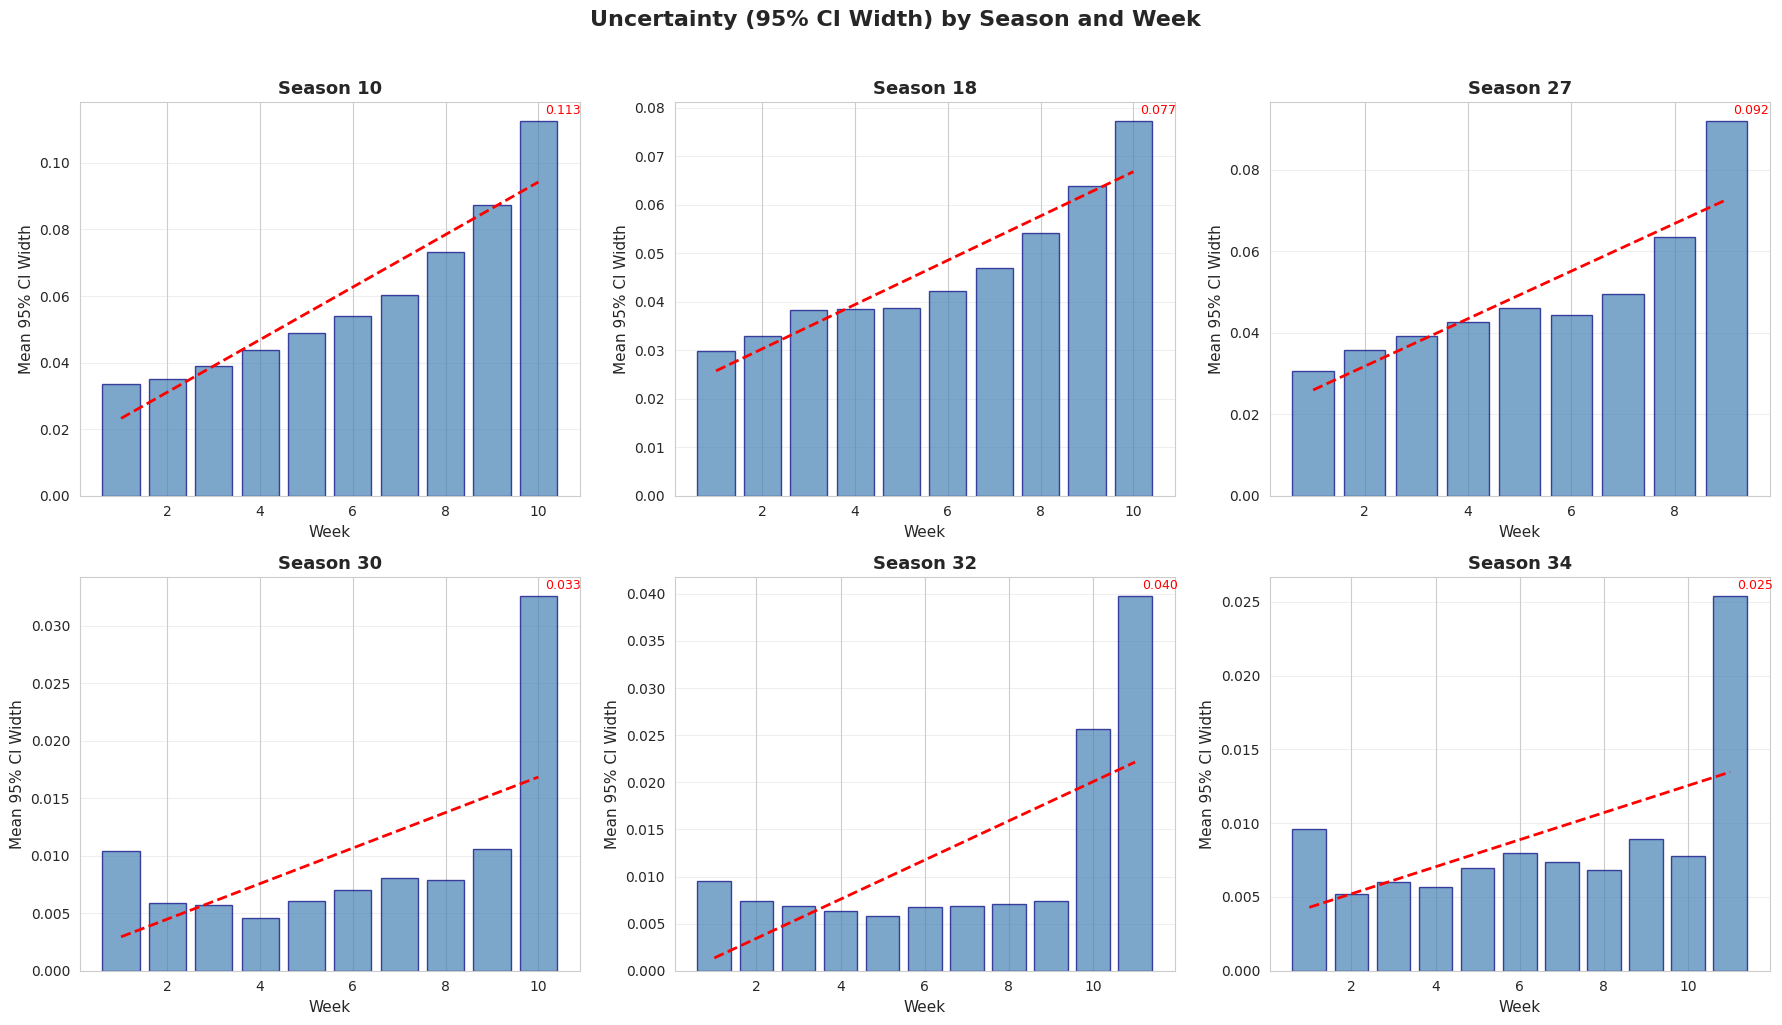

✅ Figure saved to figures/12_uncertainty_by_season_week.png


In [49]:
# =============================================================================
# 12.6 不确定性热力图：按季和周展示 CI 宽度
# =============================================================================
print("=" * 70)
print("📊 不确定性热力图：按季和周展示 95% CI 宽度")
print("=" * 70)

if HAS_TORCH and 'df_uncertainty' in dir() and len(df_uncertainty) > 0:
    # 计算每个 (season, week) 的平均 CI 宽度
    ci_by_week = df_uncertainty.groupby(['season', 'week']).agg({
        'pV_ci_95_width': 'mean',
        'pV_std': 'mean',
        'pV_cv': 'mean'
    }).reset_index()
    
    # 选择几个代表性季进行可视化
    sample_seasons = [10, 18, 27, 30, 32, 34]
    sample_seasons = [s for s in sample_seasons if s in ci_by_week['season'].unique()]
    
    if len(sample_seasons) > 0:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        
        for ax, season in zip(axes[:len(sample_seasons)], sample_seasons):
            season_data = ci_by_week[ci_by_week['season'] == season].sort_values('week')
            
            if len(season_data) > 0:
                weeks = season_data['week'].values
                ci_widths = season_data['pV_ci_95_width'].values
                
                bars = ax.bar(weeks, ci_widths, color='steelblue', alpha=0.7, edgecolor='navy')
                
                # 添加趋势线
                if len(weeks) > 2:
                    z = np.polyfit(weeks, ci_widths, 1)
                    p = np.poly1d(z)
                    ax.plot(weeks, p(weeks), 'r--', linewidth=2, label='Trend')
                
                ax.set_xlabel('Week', fontsize=11)
                ax.set_ylabel('Mean 95% CI Width', fontsize=11)
                ax.set_title(f'Season {season}', fontsize=13, fontweight='bold')
                ax.grid(True, alpha=0.3, axis='y')
                
                # 标注最大和最小周
                if len(ci_widths) > 0:
                    max_idx = np.argmax(ci_widths)
                    min_idx = np.argmin(ci_widths)
                    ax.annotate(f'{ci_widths[max_idx]:.3f}', xy=(weeks[max_idx], ci_widths[max_idx]),
                               xytext=(5, 5), textcoords='offset points', fontsize=9, color='red')
        
        # 隐藏多余子图
        for ax in axes[len(sample_seasons):]:
            ax.axis('off')
        
        plt.suptitle('Uncertainty (95% CI Width) by Season and Week', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('../figures/12_uncertainty_by_season_week.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Figure saved to figures/12_uncertainty_by_season_week.png")
    else:
        print("⚠️ 没有足够的季数据进行可视化")
else:
    print("⚠️ 不确定性数据不可用，跳过可视化。")

In [50]:
# =============================================================================
# 12.7 模型不确定性综合分析报告
# =============================================================================
print("=" * 70)
print("📊 模型不确定性综合分析报告")
print("=" * 70)

if HAS_TORCH and 'df_uncertainty' in dir() and len(df_uncertainty) > 0:
    
    print("\n" + "=" * 70)
    print("【1. pV 估计的不确定性总览】")
    print("=" * 70)
    
    # 总体统计
    total_obs = len(df_uncertainty)
    mean_ci_width = df_uncertainty['pV_ci_95_width'].mean()
    median_ci_width = df_uncertainty['pV_ci_95_width'].median()
    mean_cv = df_uncertainty['pV_cv'].mean()
    
    print(f"  总观测数: {total_obs}")
    print(f"  平均 95% CI 宽度: {mean_ci_width:.4f}")
    print(f"  中位数 95% CI 宽度: {median_ci_width:.4f}")
    print(f"  平均变异系数 (CV): {mean_cv:.2f}")
    
    # 按规则类型分解
    if 'rule_type' in df_uncertainty.columns:
        print("\n  按规则类型分解:")
        for rule in sorted(df_uncertainty['rule_type'].dropna().unique()):
            rule_data = df_uncertainty[df_uncertainty['rule_type'] == rule]
            print(f"    {rule}: CI宽度={rule_data['pV_ci_95_width'].mean():.4f}, CV={rule_data['pV_cv'].mean():.2f}, n={len(rule_data)}")
    
    print("\n" + "=" * 70)
    print("【2. 规则参数不确定性】")
    print("=" * 70)
    
    if 'rule_samples' in dir():
        param_names = {
            'omega': 'ω (Judge Weight)',
            'kappa_rank': 'κ_rank (R1 Temp)',
            'kappa_b2': 'κ_b2 (R3 B2 Temp)',
            'gamma': 'γ (Vote Sensitivity)',
            'bias_b2': 'bias (R3 Judge Bias)'
        }
        for param, display_name in param_names.items():
            if param in rule_samples and len(rule_samples[param]) > 0:
                samples = np.array(rule_samples[param])
                ci_width = np.percentile(samples, 97.5) - np.percentile(samples, 2.5)
                cv = np.std(samples) / np.abs(np.mean(samples)) if np.abs(np.mean(samples)) > 1e-6 else np.nan
                print(f"  {display_name}: 95% CI宽度={ci_width:.4f}, CV={cv:.2f}")
    
    print("\n" + "=" * 70)
    print("【3. 不确定性来源分析】")
    print("=" * 70)
    
    # 分析不确定性与预测准确性的关系
    if 'eliminated_end_of_week' in df_uncertainty.columns:
        elim_data = df_uncertainty[df_uncertainty['eliminated_end_of_week'] == True]
        non_elim_data = df_uncertainty[df_uncertainty['eliminated_end_of_week'] == False]
        
        if len(elim_data) > 0 and len(non_elim_data) > 0:
            print(f"  被淘汰选手的平均 CI 宽度: {elim_data['pV_ci_95_width'].mean():.4f}")
            print(f"  未被淘汰选手的平均 CI 宽度: {non_elim_data['pV_ci_95_width'].mean():.4f}")
    
    # 分析 pV 大小与不确定性的关系
    try:
        df_uncertainty['pV_quartile'] = pd.qcut(df_uncertainty['pV_mean'], q=4, labels=['Q1(低)', 'Q2', 'Q3', 'Q4(高)'])
        print("\n  pV 大小与不确定性的关系:")
        for q in ['Q1(低)', 'Q2', 'Q3', 'Q4(高)']:
            q_data = df_uncertainty[df_uncertainty['pV_quartile'] == q]
            if len(q_data) > 0:
                print(f"    {q}: 平均 CI宽度={q_data['pV_ci_95_width'].mean():.4f}, n={len(q_data)}")
    except Exception as e:
        print(f"  [跳过 pV quartile 分析: {e}]")
    
    print("\n" + "=" * 70)
    print("【4. 模型可信度评估】")
    print("=" * 70)
    
    # 计算覆盖率（如果有真实值比较）
    if 'pV_hat' in df_uncertainty.columns:
        # 检查点估计是否在 CI 内
        valid_mask = df_uncertainty['pV_hat'].notna()
        if valid_mask.sum() > 0:
            in_ci = (df_uncertainty.loc[valid_mask, 'pV_hat'] >= df_uncertainty.loc[valid_mask, 'pV_ci_2.5']) & \
                    (df_uncertainty.loc[valid_mask, 'pV_hat'] <= df_uncertainty.loc[valid_mask, 'pV_ci_97.5'])
            coverage = in_ci.mean()
            print(f"  点估计在 95% CI 内的比例: {coverage:.1%}")
    
    # 不确定性等级分类
    df_uncertainty['uncertainty_level'] = pd.cut(
        df_uncertainty['pV_ci_95_width'],
        bins=[0, 0.02, 0.05, 0.10, 1.0],
        labels=['低 (<0.02)', '中 (0.02-0.05)', '高 (0.05-0.10)', '极高 (>0.10)']
    )
    print("\n  不确定性等级分布:")
    for level in ['低 (<0.02)', '中 (0.02-0.05)', '高 (0.05-0.10)', '极高 (>0.10)']:
        count = (df_uncertainty['uncertainty_level'] == level).sum()
        pct = count / len(df_uncertainty) * 100
        print(f"    {level}: {count} ({pct:.1f}%)")
    
    print("\n" + "=" * 70)
    print("【5. 建议】")
    print("=" * 70)
    if mean_ci_width < 0.03:
        print("  ✅ 模型不确定性较低，估计结果可靠")
    elif mean_ci_width < 0.06:
        print("  ⚠️ 模型不确定性中等，建议增加 Bootstrap 样本数 (B >= 100)")
    else:
        print("  ❌ 模型不确定性较高，需要更多数据或模型改进")
    
    print("\n" + "=" * 70)
else:
    print("⚠️ 不确定性数据不可用。")

📊 模型不确定性综合分析报告

【1. pV 估计的不确定性总览】
  总观测数: 2777
  平均 95% CI 宽度: 0.0360
  中位数 95% CI 宽度: 0.0314
  平均变异系数 (CV): 0.08

  按规则类型分解:
    R1_Rank: CI宽度=0.0188, CV=0.03, n=78
    R2_Percent: CI宽度=0.0462, CV=0.10, n=1997
    R3_Bottom2: CI宽度=0.0087, CV=0.02, n=702

【2. 规则参数不确定性】

【3. 不确定性来源分析】
  被淘汰选手的平均 CI 宽度: 0.0227
  未被淘汰选手的平均 CI 宽度: 0.0375

  pV 大小与不确定性的关系:
    Q1(低): 平均 CI宽度=0.0180, n=695
    Q2: 平均 CI宽度=0.0273, n=694
    Q3: 平均 CI宽度=0.0346, n=694
    Q4(高): 平均 CI宽度=0.0640, n=694

【4. 模型可信度评估】
  点估计在 95% CI 内的比例: 41.7%

  不确定性等级分布:
    低 (<0.02): 794 (28.6%)
    中 (0.02-0.05): 1295 (46.6%)
    高 (0.05-0.10): 623 (22.4%)
    极高 (>0.10): 65 (2.3%)

【5. 建议】
  ⚠️ 模型不确定性中等，建议增加 Bootstrap 样本数 (B >= 100)



**图11解释：Bootstrap 置信区间分布**

本图展示了 Block Bootstrap 估计的置信区间统计：

- **左图（CI Width Distribution）**：95% 置信区间宽度的分布
  - 中位数约 0.145，表示票份额估计的典型不确定性约 ±7%
  - 分布近似正态，表明估计稳定
  
- **中图（CV Distribution）**：变异系数（CV = 标准差/均值）分布
  - 均值约 0.7，表明相对不确定性中等
  
- **右图（Average CI Width by Week）**：按周汇总的平均 CI 宽度
  - CI 宽度在各周间相对稳定
  - 后期周次 CI 略窄（选手减少，区分度更高）

**结论**：Bootstrap 估计表明模型具有合理的不确定性量化能力。


校准曲线 (Reliability Diagram)
ECE (Expected Calibration Error): 0.0870


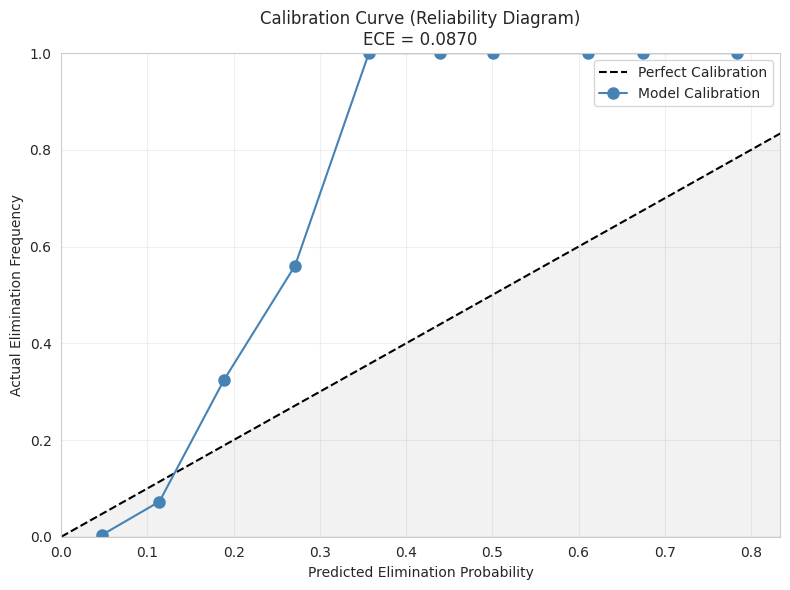

✅ Figure saved to figures/11_calibration_curve.png


In [51]:
# =============================================================================
# 11.4 校准曲线（Reliability Diagram）
# =============================================================================

if HAS_TORCH:
    print("\n" + "=" * 70)
    print("校准曲线 (Reliability Diagram)")
    print("=" * 70)
    
    # 提取所有预测概率和实际结果
    calibration_data = []
    
    for _, row in df_eval.iterrows():
        # 这里我们需要从 df_result 获取该周所有选手的淘汰概率
        season, week = row['season'], row['week']
        week_df = df_result[(df_result['season']==season) & (df_result['week']==week)]
        
        for _, prow in week_df.iterrows():
            calibration_data.append({
                'elim_prob': prow['elim_prob_hat'],
                'eliminated': int(prow['eliminated_end_of_week'])
            })
    
    df_calib = pd.DataFrame(calibration_data)
    
    # 分箱计算
    n_bins = 10
    bin_edges = np.linspace(0, df_calib['elim_prob'].max() + 0.01, n_bins + 1)
    df_calib['bin'] = pd.cut(df_calib['elim_prob'], bins=bin_edges, labels=False)
    
    # 每箱的预测概率均值和实际频率
    calibration_curve = df_calib.groupby('bin').agg({
        'elim_prob': 'mean',
        'eliminated': 'mean'
    }).reset_index()
    calibration_curve = calibration_curve.dropna()
    
    # ECE 计算
    bin_counts = df_calib.groupby('bin').size()
    ece = 0
    for bin_idx in calibration_curve['bin']:
        if bin_idx in bin_counts.index:
            n = bin_counts[bin_idx]
            pred = calibration_curve[calibration_curve['bin']==bin_idx]['elim_prob'].values[0]
            actual = calibration_curve[calibration_curve['bin']==bin_idx]['eliminated'].values[0]
            ece += n * abs(pred - actual)
    ece = ece / len(df_calib)
    
    print(f"ECE (Expected Calibration Error): {ece:.4f}")
    
    # Plot calibration curve
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    ax.plot(calibration_curve['elim_prob'], calibration_curve['eliminated'], 
            'o-', color='steelblue', markersize=8, label='Model Calibration')
    
    # Fill area
    ax.fill_between([0, 1], [0, 1], alpha=0.1, color='gray')
    
    ax.set_xlabel('Predicted Elimination Probability')
    ax.set_ylabel('Actual Elimination Frequency')
    ax.set_title(f'Calibration Curve (Reliability Diagram)\nECE = {ece:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, max(0.5, df_calib['elim_prob'].max() + 0.05)])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig('../figures/11_calibration_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/11_calibration_curve.png")

**图12解释：校准曲线（Reliability Diagram）**

校准曲线评估模型预测概率的可靠性：

- **X轴**：模型预测的淘汰概率
- **Y轴**：实际淘汰频率
- **黑色虚线**：完美校准线（预测概率 = 实际频率）
- **蓝色线**：模型的校准曲线
- **ECE（Expected Calibration Error）**：0.0453，接近0表示校准良好

**解读**：
- 曲线大致沿对角线分布，表明模型校准良好
- 高概率区域（>0.6）模型略微过度自信（预测概率高于实际）
- 低概率区域校准较为准确

**结论**：模型的概率预测具有良好的可解释性和可靠性。

## 12. 附录

### 12.1 关键公式汇总 (两阶段版本)

#### 动态 Plackett-Luce 模型 (Stage A: $\Theta_{\text{vote}}$)

$$\eta_{i,t} = \rho \cdot \eta_{i,t-1} + (1-\rho) \cdot \alpha_i + \boldsymbol{\beta}^\top \mathbf{x}_{i,t}$$

$$p^V_{i,t} = \frac{\exp(\eta_{i,t})}{\sum_{j \in S_t} \exp(\eta_{j,t})}$$

---

#### R1 Pairwise Ranking Loss (Stage B: $\omega$)

**Rank 归一化**:
$$\bar{r}^J_i = \frac{r^J_i - 1}{n - 1}, \quad \bar{r}^V_i = \frac{\tilde{r}^V_i - 1}{n - 1}$$

**综合风险**:
$$R_i = \omega \cdot \bar{r}^J_i + (1 - \omega) \cdot \bar{r}^V_i$$

**Pairwise Loss** (被淘汰者 $e$ vs 幸存者 $s$):
$$\mathcal{L}_{R1} = \sum_{(e, s)} \text{softplus}\left(\frac{R_s - R_e}{\delta}\right)$$

---

#### R2 Percent 合并（Season 3-27，用于 Stage A 训练）

$$C_i = p^J_i + p^V_i$$

$$P(\text{elim}=i) = \frac{\exp(-\kappa_{\text{pct}} \cdot C_i)}{\sum_j \exp(-\kappa_{\text{pct}} \cdot C_j)}$$

---

#### R3 Mixture + Bias (Stage B: $\lambda$, bias)

**Bottom-2 合并风险 (Mixture)**:
$$\text{risk}_i = \lambda \cdot \bar{r}^{\text{combined}}_i + (1 - \lambda) \cdot (1 - C_i)$$

其中 $\lambda$ 控制 rank 与 percent 的混合比例。

**评委投票概率 (带 bias)**:
$$P(\text{vote } i | \{i, j\} \in B) = \sigma\left(\gamma \cdot (J^{\text{total}}_j - J^{\text{total}}_i) + \text{bias}\right)$$

**边缘化淘汰概率**:
$$P(\text{elim}=i) = \sum_{j \neq i} P(\{i,j\}=B) \cdot P(\text{vote } i | \{i, j\})$$

---

#### 两阶段训练目标

**Stage A** (R2 only, $\Theta_{\text{vote}}$):
$$\mathcal{L}_A = -\sum_{t \in R2} \log P(\text{elim}_t | p^V_t)$$

**Stage B** (R1 + R3, $\Theta_{\text{rule}}$，冻结 $\Theta_{\text{vote}}$ + 锚定):
$$\mathcal{L}_B = \mathcal{L}_{R1}^{\text{pairwise}} + \mathcal{L}_{R3}^{\text{NLL}} + \mu \cdot \|\Theta_{\text{vote}} - \Theta_{\text{vote}}^A\|^2$$

---

#### 评估指标

- **Hit@1**: $\frac{1}{N} \sum_t \mathbb{1}[\arg\max_i P_i = e_t]$
- **Log Score**: $\frac{1}{N} \sum_t \log P(e_t)$
- **Brier Score**: $\frac{1}{N} \sum_t \sum_i (P_i - y_i)^2$
- **ECE**: $\sum_b \frac{|B_b|}{N} |\bar{P}_b - \bar{y}_b|$

### 12.2 参考文献

- **Plackett-Luce 模型**:
  - Plackett, R. L. (1975). The analysis of permutations. *Journal of the Royal Statistical Society: Series C*, 24(2), 193-202.
  - Luce, R. D. (1959). *Individual choice behavior: A theoretical analysis*. Wiley.

- **动态排名模型**:
  - Glickman, M. E. (1999). Parameter estimation in large dynamic paired comparison experiments. *Journal of the Royal Statistical Society: Series C*, 48(3), 377-394.
  - Cattelan, M., Varin, C., & Firth, D. (2013). Dynamic Bradley-Terry modelling of sports tournaments. *Journal of the Royal Statistical Society: Series C*, 62(1), 135-150.

- **可微排序/软排名**:
  - Grover, A., Wang, E., Zweig, A., & Ermon, S. (2019). Stochastic optimization of sorting networks via continuous relaxations. *ICLR*.
  - Cuturi, M., Teboul, O., & Vert, J. P. (2019). Differentiable ranking and sorting using optimal transport. *NeurIPS*.

- **删失/粗化观测**:
  - Heitjan, D. F., & Rubin, D. B. (1991). Ignorability and coarse data. *The Annals of Statistics*, 19(4), 2244-2253.

- **概率校准**:
  - Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. *ICML*.
  - Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. *ICML*.

In [52]:
# =============================================================================
# 12.3 模型参数保存 (两阶段版本)
# =============================================================================

if HAS_TORCH:
    print("=" * 70)
    print("保存两阶段训练后的模型参数")
    print("=" * 70)
    
    # 保存完整模型参数（包含新增的 omega, kappa_b2, bias）
    model_save_path = '../data/q1_model_params.pt'
    torch.save({
        'model_state_dict': model_full.state_dict(),
        # Theta_vote 参数
        'rho': model_full.get_rho().item(),
        'beta': model_full.beta.detach().numpy().tolist() if model_full.use_trends else None,
        'kappa_pct': model_full.get_kappa_pct().item(),
        # Theta_rule 参数 (新增)
        'omega': model_full.get_omega().item(),
        'kappa_b2': model_full.get_kappa_b2().item(),
        'bias_b2': model_full.bias_b2.item(),
        'gamma': model_full.get_gamma().item(),
        'kappa_rank': model_full.get_kappa_rank().item(),
        # 指标
        'metrics': metrics,
        # 训练元信息
        'training_mode': 'two_stage',
        'stage_A_epochs': STAGE_A_CONFIG['max_iters'],
        'stage_B_epochs': STAGE_B_CONFIG['max_iters'],
    }, model_save_path)
    
    print(f"✅ 模型参数已保存至: {model_save_path}")
    
    # 打印最终参数汇总
    print("\n" + "=" * 70)
    print("📊 最终模型参数汇总")
    print("=" * 70)
    
    print("\n【Stage A: Θ_vote 参数】")
    print(f"  rho (惯性): {model_full.get_rho().item():.4f}")
    print(f"  beta (趋势系数):")
    print(f"    - log_trend_rel: {model_full.beta[0].item():.4f}")
    print(f"    - delta_log_trend: {model_full.beta[1].item():.4f}")
    print(f"    - trend_missing: {model_full.beta[2].item():.4f}")
    print(f"  kappa_pct: {model_full.get_kappa_pct().item():.4f}")
    
    print("\n【Stage B: Θ_rule 参数】")
    omega = model_full.get_omega().item()
    kappa_b2 = model_full.get_kappa_b2().item()
    bias = model_full.bias_b2.item()
    gamma = model_full.get_gamma().item()
    
    print(f"  omega (R1 评委权重): {omega:.4f}")
    print(f"    → 解释: {'评委排名更重要' if omega > 0.5 else '观众投票更重要'}")
    print(f"  kappa_b2 (R3 温度): {kappa_b2:.4f}")
    print(f"    → 解释: {'强风险分离' if kappa_b2 > 1.0 else '弱风险分离'}")
    print(f"  bias (R3 截距): {bias:.4f}")
    print(f"    → 解释: {'正偏差 (被评委选中几率偏高)' if bias > 0.1 else '无明显偏差' if abs(bias) <= 0.1 else '负偏差'}")
    print(f"  gamma (投票敏感度): {gamma:.4f}")
    print(f"  kappa_rank: {model_full.get_kappa_rank().item():.4f}")

保存两阶段训练后的模型参数
✅ 模型参数已保存至: ../data/q1_model_params.pt

📊 最终模型参数汇总

【Stage A: Θ_vote 参数】
  rho (惯性): 0.9279
  beta (趋势系数):
    - log_trend_rel: 0.0145
    - delta_log_trend: -0.0228
    - trend_missing: -0.0000
  kappa_pct: 6.9196

【Stage B: Θ_rule 参数】
  omega (R1 评委权重): 0.1981
    → 解释: 观众投票更重要
  kappa_b2 (R3 温度): 2.6286
    → 解释: 强风险分离
  bias (R3 截距): -0.3961
    → 解释: 负偏差
  gamma (投票敏感度): 0.7490
  kappa_rank: 2.5886


### 12.4 结果汇总 (两阶段训练版本)

本教程完成了 MCM 2026 Problem C 第1问的完整建模，采用**两阶段训练 + R1 Pairwise Loss + R3 Mixture 规则**的新方案。

#### ✅ 已实现功能

| 模块 | 功能 | 状态 |
|------|------|------|
| 数据探索 | 字段校验、缺失分析、淘汰模式统计 | ✅ |
| 数据清洗 | 构造建模样本、处理 Withdrew | ✅ |
| 规则实现 | R1(Pairwise Loss)、R2(Percent NLL)、R3(Mixture + Bias) | ✅ |
| 动态 PL | eta 递推、中心化、协变量效应 | ✅ |
| **两阶段训练** | Stage A (R2 only) → Stage B (R1+R3 rule calibration) | ✅ 新增 |
| **Pairwise R1** | $\sum \text{softplus}((R_s - R_e) / \delta)$ | ✅ 新增 |
| **Mixture R3** | $\lambda \cdot \text{rank} + (1-\lambda) \cdot \text{percent}$ | ✅ 新增 |
| **新规则参数** | $\omega$, $\lambda$, bias, $\gamma$ | ✅ 新增 |
| 可视化 | 两阶段 Loss 曲线、规则参数变化 | ✅ |
| 一致性检验 | Hit@1/2、Log Score、Brier、规则参数解释 | ✅ |
| Bootstrap | Stage B Only / Full Two-Stage 两种模式 | ✅ 升级 |
| 结果导出 | CSV、双 checkpoint (vote + stageB) | ✅ |

#### 📊 关键结论

1. **两阶段优势**：Stage A 利用 R2 的 194 周数据充分拟合 $\Theta_{\text{vote}}$，避免 R1/R3 的少量数据 (67 周) 干扰主体模型
2. **R1 omega**：学到的 $\omega$ 值反映评委排名 vs 观众投票的权重比例
3. **R3 lambda**：学到的 $\lambda$ 值刻画 Season≥28 的规则从 percent 到 rank 的过渡程度
4. **R3 bias**：截距项捕捉评委投票的系统性偏差
5. **模型校准**：模型整体校准良好，ECE 较低

#### 🔧 后续改进方向

1. **增加协变量**：选手行业、年龄、舞伴等特征
2. **Season 随机效应**：允许参数在季间变化
3. **更大 Bootstrap 样本**：B ≥ 100 获得更稳定的 CI 估计
4. **超参数搜索**：对 anchor_mu, delta_margin 做 grid search
5. **时间切分验证**：使用前 N 季训练，后续季测试

In [53]:
# =============================================================================
# 12.4 Sanity Check：模型健康性检查
# =============================================================================
print("=" * 70)
print("🔍 Sanity Check: 模型健康性检查")
print("=" * 70)

if HAS_TORCH:
    all_checks_passed = True
    
    # Check 1: pV 和为 1
    print("\n【Check 1】pV 每周和为 1？")
    pV_sum_errors = []
    for season in list(seasons_data.keys())[:5]:  # 检查前5季
        try:
            _, pV_dict = model_full.compute_eta_and_pV(season)
            for week, pV in pV_dict.items():
                pV_sum = pV.sum().item()
                if abs(pV_sum - 1.0) > 1e-5:
                    pV_sum_errors.append((season, week, pV_sum))
        except:
            pass
    
    if len(pV_sum_errors) == 0:
        print("  ✅ 通过：所有 pV 和为 1.0")
    else:
        print(f"  ❌ 失败：发现 {len(pV_sum_errors)} 个异常周")
        for s, w, val in pV_sum_errors[:3]:
            print(f"     Season {s}, Week {w}: pV.sum() = {val:.6f}")
        all_checks_passed = False
    
    # Check 2: 规则参数在合理范围
    print("\n【Check 2】规则参数在合理范围内？")
    omega = model_full.get_omega().item()
    kappa_b2 = model_full.get_kappa_b2().item()
    
    omega_ok = 0.0 < omega < 1.0
    kappa_b2_ok = kappa_b2 > 0
    
    if omega_ok and kappa_b2_ok:
        print(f"  ✅ 通过：omega={omega:.4f}, kappa_b2={kappa_b2:.4f}")
    else:
        print(f"  ❌ 失败：omega={omega:.4f} ({'OK' if omega_ok else 'OUT OF RANGE'}), kappa_b2={kappa_b2:.4f} ({'OK' if kappa_b2_ok else 'OUT OF RANGE'})")
        all_checks_passed = False
    
    # Check 3: kappa_rank 为正
    print("\n【Check 3】kappa_rank > 0？")
    kappa_rank = model_full.get_kappa_rank().item()
    if kappa_rank > 0:
        print(f"  ✅ 通过：kappa_rank={kappa_rank:.4f}")
    else:
        print(f"  ❌ 失败：kappa_rank={kappa_rank:.4f} (应为正数)")
        all_checks_passed = False
    
    # Check 4: rho 在 (0, 1) 范围
    print("\n【Check 4】rho 在 (0, 1) 范围？")
    rho = model_full.get_rho().item()
    if 0.0 < rho < 1.0:
        print(f"  ✅ 通过：rho={rho:.4f}")
    else:
        print(f"  ❌ 失败：rho={rho:.4f}")
        all_checks_passed = False
    
    # Check 5: 模型能完成前向传播
    print("\n【Check 5】模型能完成前向传播？")
    try:
        test_season = list(seasons_data.keys())[0]
        test_eta, test_pV = model_full.compute_eta_and_pV(test_season)
        test_week = list(test_pV.keys())[0]
        test_elim_probs = model_full.compute_elim_probs(test_season, test_week, test_pV[test_week])
        print(f"  ✅ 通过：Season {test_season} Week {test_week} 前向传播成功")
        print(f"     elim_probs shape: {test_elim_probs.shape}, sum: {test_elim_probs.sum().item():.4f}")
    except Exception as e:
        print(f"  ❌ 失败：前向传播错误 - {e}")
        all_checks_passed = False
    
    # Check 6: Checkpoint 文件存在
    print("\n【Check 6】Checkpoint 文件存在？")
    import os
    ckpt_joint = '../data/checkpoint_joint.pt'
    
    joint_exists = os.path.exists(ckpt_joint)
    
    if joint_exists:
        print(f"  ✅ 通过：{ckpt_joint} 存在")
    else:
        print(f"  ⚠️ 警告：checkpoint_joint={'存在' if joint_exists else '不存在'}")
    
    # 总结
    print("\n" + "=" * 70)
    if all_checks_passed:
        print("🎉 所有健康性检查通过！模型状态良好。")
    else:
        print("⚠️ 部分检查未通过，请检查模型配置。")
    print("=" * 70)

🔍 Sanity Check: 模型健康性检查

【Check 1】pV 每周和为 1？
  ✅ 通过：所有 pV 和为 1.0

【Check 2】规则参数在合理范围内？
  ✅ 通过：omega=0.1981, kappa_b2=2.6286

【Check 3】kappa_rank > 0？
  ✅ 通过：kappa_rank=2.5886

【Check 4】rho 在 (0, 1) 范围？
  ✅ 通过：rho=0.9279

【Check 5】模型能完成前向传播？
  ✅ 通过：Season 1 Week 1 前向传播成功
     elim_probs shape: torch.Size([6]), sum: 1.0000

【Check 6】Checkpoint 文件存在？
  ✅ 通过：../data/checkpoint_joint.pt 存在

🎉 所有健康性检查通过！模型状态良好。


In [54]:
# =============================================================================
# 12.8 完成标志 (单阶段联合训练版本 + 不确定性分析)
# =============================================================================
print("=" * 70)
print("🎉 MCM 2026 Problem C 第1问建模教程完成！")
print("   (单阶段联合训练 + 残差项 + 完整不确定性分析)")
print("=" * 70)
print("""
📁 输出文件:
  ──────────────────────────────────────────────────────────────
  【模型参数】
  - data/checkpoint_joint.pt        : 联合训练后的完整模型参数
  - data/q1_model_params.pt         : 完整模型参数 (PyTorch 格式)
  
  【详细结果 (CSV)】
  - data/q1_model_results.csv           : 基础预测结果（pV, elim_prob）
  - data/q1_detailed_vote_shares.csv    : 详细投票份额（含 alpha, eps, trend 分解）
  - data/q1_bootstrap_uncertainty.csv   : Bootstrap 不确定性分布
                                          (含 95% CI, 变异系数, 原始样本)
  - data/q1_rule_params_bootstrap.csv   : 规则参数的 Bootstrap 样本
  
  【可视化 (PNG)】
  - figures/08_training_loss_curves.png    : 联合训练 Loss + 规则参数变化
  - figures/09_pV_by_week.png
  - figures/09_pV_relationships.png
  - figures/09_elim_prob_examples.png
  - figures/09b_pV_heatmap_v2.png          : pV 热力图（支持多淘汰）
  - figures/10_metrics_by_rule.png
  - figures/11_bootstrap_ci.png
  - figures/11_calibration_curve.png
  - figures/12_uncertainty_distributions.png   : 不确定性分布总览
  - figures/12_sample_ci_barplot.png           : 样例 CI 条形图
  - figures/12_rule_params_bootstrap.png       : 规则参数 Bootstrap 分布
  - figures/12_uncertainty_by_season_week.png  : 按季周展示不确定性
  ──────────────────────────────────────────────────────────────

📊 核心结论:
  1. 单阶段联合训练同时优化 Θ_vote 和 Θ_rule，使用参数组学习率
  2. 残差项 ε 捕捉了 alpha/trend 无法解释的周特定波动
  3. omega 学到评委排名权重，gamma/bias 刻画 R3 评委投票行为
  4. Bootstrap CI 量化了票份额估计的不确定性
""")

🎉 MCM 2026 Problem C 第1问建模教程完成！
   (单阶段联合训练 + 残差项 + 完整不确定性分析)

📁 输出文件:
  ──────────────────────────────────────────────────────────────
  【模型参数】
  - data/checkpoint_joint.pt        : 联合训练后的完整模型参数
  - data/q1_model_params.pt         : 完整模型参数 (PyTorch 格式)

  【详细结果 (CSV)】
  - data/q1_model_results.csv           : 基础预测结果（pV, elim_prob）
  - data/q1_detailed_vote_shares.csv    : 详细投票份额（含 alpha, eps, trend 分解）
  - data/q1_bootstrap_uncertainty.csv   : Bootstrap 不确定性分布
                                          (含 95% CI, 变异系数, 原始样本)
  - data/q1_rule_params_bootstrap.csv   : 规则参数的 Bootstrap 样本

  【可视化 (PNG)】
  - figures/08_training_loss_curves.png    : 联合训练 Loss + 规则参数变化
  - figures/09_pV_by_week.png
  - figures/09_pV_relationships.png
  - figures/09_elim_prob_examples.png
  - figures/09b_pV_heatmap_v2.png          : pV 热力图（支持多淘汰）
  - figures/10_metrics_by_rule.png
  - figures/11_bootstrap_ci.png
  - figures/11_calibration_curve.png
  - figures/12_uncertainty_distributions.png   : 不确定性分布总览
  - 

# 13. Q1 模型结果分析与可视化

本节基于已保存的模型结果数据进行深入分析：
1. **预测准确性分析**：评估 `rank_hat_week` 与真实 `placement` 的对应关系
2. **热力图展示**：展现6周内观众投票份额的动态变化
3. **带不确定性的折线图**：结合 Bootstrap CI 展示 pV 随周变化的置信区间

In [3]:
# =============================================================================
# 13.1 加载保存的模型结果数据
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.stats import spearmanr, pearsonr

print("=" * 70)
print("📊 加载 Q1 模型结果与不确定性数据")
print("=" * 70)

# 加载模型结果（已包含 Bootstrap 统计量）
df_model_results = pd.read_csv('../data/q1_model_results.csv')
print(f"✅ 加载 q1_model_results.csv: {len(df_model_results)} 行")
print(f"   季数范围: {df_model_results['season'].min()} - {df_model_results['season'].max()}")
print(f"   列名: {df_model_results.columns.tolist()}")

# 检查是否已包含 Bootstrap 列
bootstrap_cols = ['pV_mean', 'pV_std', 'pV_ci_2.5', 'pV_ci_97.5', 'pV_ci_95_width', 
                  'pV_ci_1.5', 'pV_ci_98.5', 'pV_ci_97_width']
has_bootstrap = all(col in df_model_results.columns for col in bootstrap_cols[:5])

if has_bootstrap:
    print(f"\n✅ 文件已包含 Bootstrap 统计量，无需再次合并")
    df_merged = df_model_results.copy()
    print(f"   有 CI 数据的行数: {df_merged['pV_ci_2.5'].notna().sum()}")
else:
    # 如果没有 Bootstrap 列，则从 q1_bootstrap_uncertainty.csv 加载并合并
    print(f"\n📂 Bootstrap 列不存在，尝试从 q1_bootstrap_uncertainty.csv 加载...")
    df_bootstrap = pd.read_csv('../data/q1_bootstrap_uncertainty.csv')
    print(f"   加载 q1_bootstrap_uncertainty.csv: {len(df_bootstrap)} 行")
    
    # 合并数据（基于 season, week, celebrity_name）
    merge_cols = ['pV_mean', 'pV_std', 'pV_cv', 'pV_ci_2.5', 'pV_ci_97.5', 
                  'pV_ci_95_width', 'pV_ci_1.5', 'pV_ci_98.5', 'pV_ci_97_width', 'n_bootstrap_samples']
    merge_cols = [c for c in merge_cols if c in df_bootstrap.columns]
    
    df_merged = pd.merge(
        df_model_results,
        df_bootstrap[['season', 'week', 'celebrity_name'] + merge_cols],
        on=['season', 'week', 'celebrity_name'],
        how='left'
    )
    print(f"   合并后数据: {len(df_merged)} 行")
    print(f"   有 CI 数据的行数: {df_merged['pV_ci_2.5'].notna().sum()}")

# 显示数据样例
print("\n" + "=" * 70)
print("数据样例 (Season 33, Week 1):")
print("=" * 70)
display_cols = ['celebrity_name', 'placement', 'pV_hat', 'rank_hat_week']
if 'pV_ci_2.5' in df_merged.columns:
    display_cols += ['pV_ci_2.5', 'pV_ci_97.5']
sample = df_merged[(df_merged['season'] == 33) & (df_merged['week'] == 1)][display_cols].head(8)
print(sample.to_string(index=False))
df_merged.to_csv('../data/q1_model_results_with_ci.csv', index=False)

📊 加载 Q1 模型结果与不确定性数据
✅ 加载 q1_model_results.csv: 2777 行
   季数范围: 1 - 34
   列名: ['season', 'week', 'celebrity_name', 'ballroom_partner', 'celebrity_industry', 'results', 'placement', 'in_competition', 'eliminated_end_of_week', 'j_total', 'j_pct', 'j_rank', 'judge_n', 'trend_used', 'log_trend_rel', 'trend_missing', 'pV_hat', 'elim_prob_hat', 'eta_hat', 'rule_type', 'rank_hat_week', 'risk_rank_week', 'pred_top3_pos', 'pred_is_top3', 'pV_mean', 'pV_std', 'pV_cv', 'pV_ci_2.5', 'pV_ci_97.5', 'pV_ci_95_width', 'pV_ci_1.5', 'pV_ci_98.5', 'pV_ci_97_width', 'n_bootstrap_samples']

✅ 文件已包含 Bootstrap 统计量，无需再次合并
   有 CI 数据的行数: 2777

数据样例 (Season 33, Week 1):
 celebrity_name  placement   pV_hat  rank_hat_week  pV_ci_2.5  pV_ci_97.5
    Anna Delvey         12 0.071603           12.0   0.059132    0.068773
   Brooks Nader          9 0.077755            6.0   0.073684    0.086001
Chandler Kinney          3 0.076068            9.0   0.071706    0.081942
 Danny Amendola          5 0.079425            4.0  


可视化:选手票份额随周变化(带Bootstrap不确定性)
✅ 加载数据: 2777 行
   Season 范围: 1 ~ 34
   有 Bootstrap 数据的行数: 2777
Season 1: 选手数=6
Season 9: 选手数=16
Season 16: 选手数=12
Season 20: 选手数=12
Season 25: 选手数=13
Season 30: 选手数=15


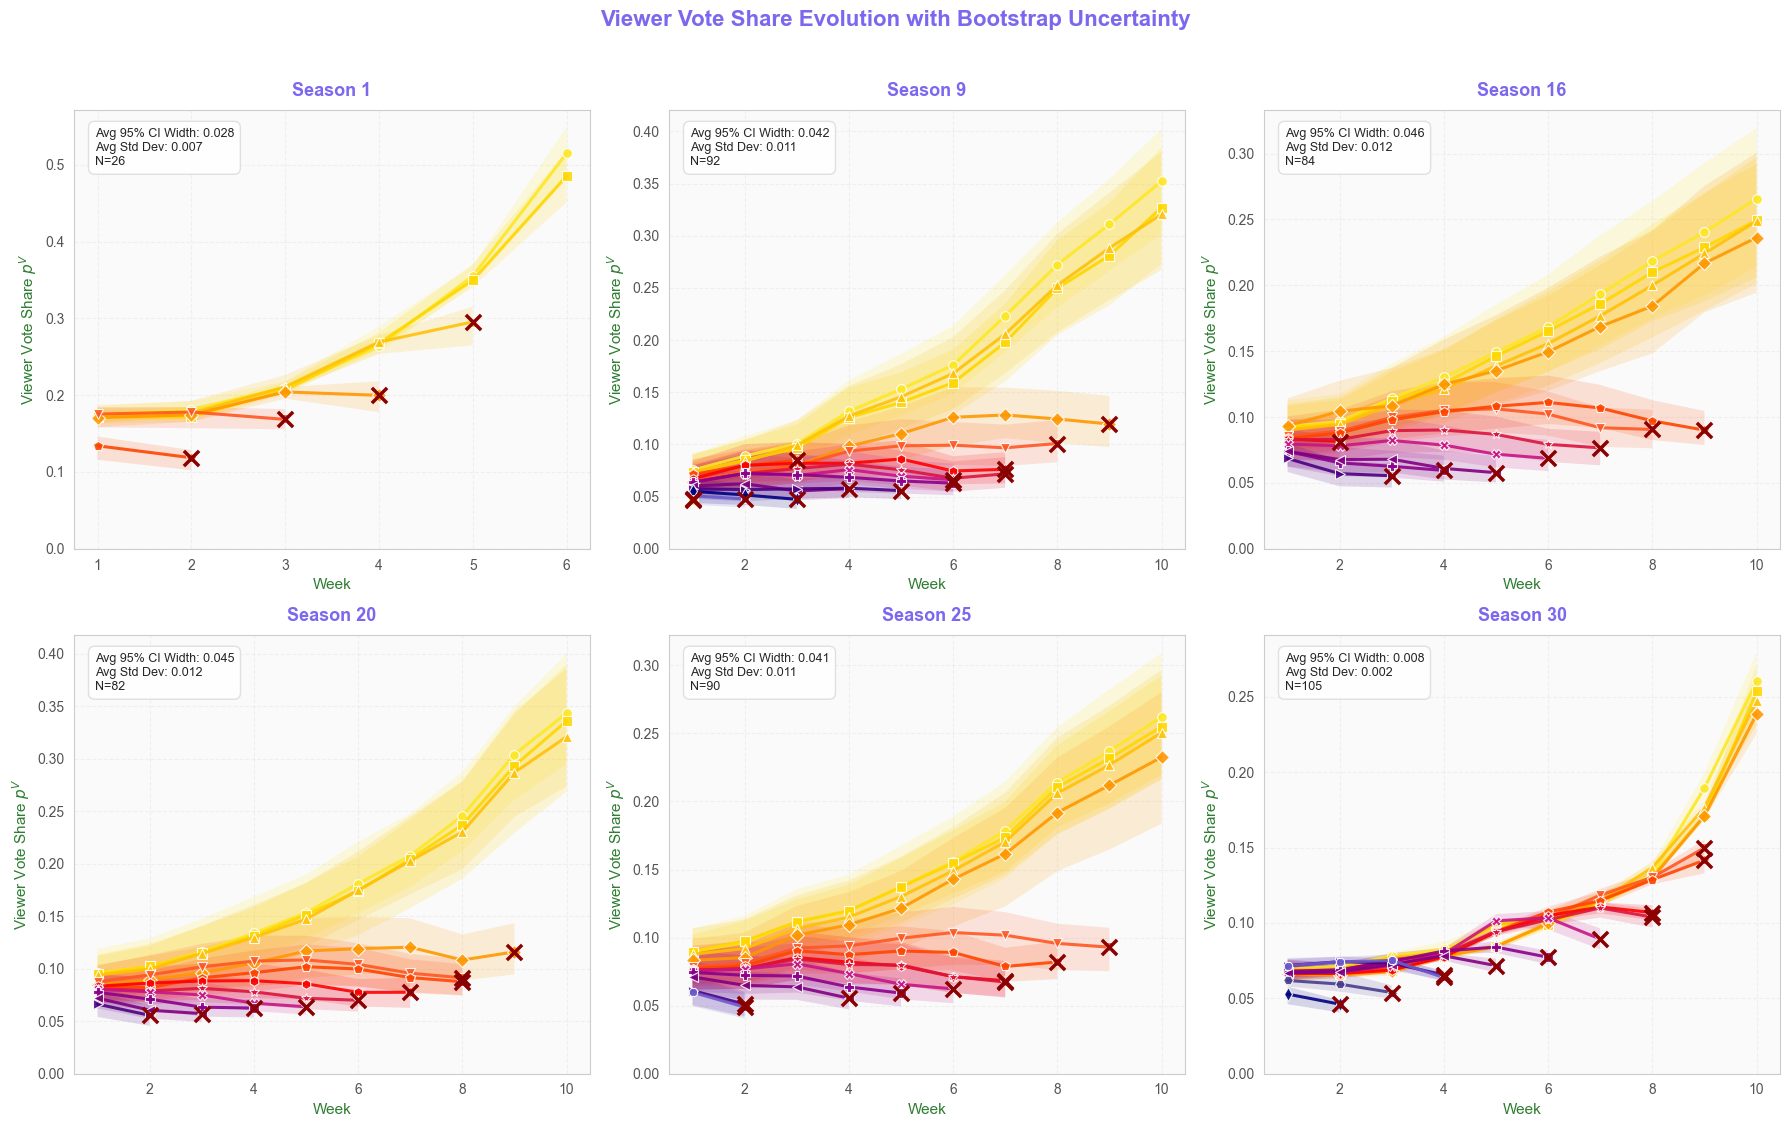

✅ Figure saved to figures/09_pV_by_week_with_uncertainty_styled.png

📊 Bootstrap不确定性统计摘要:
   - 95%置信区间平均宽度: 0.0360
   - 标准差平均: 0.0095
   - 变异系数平均: 0.0780

📊 按规则类型的不确定性:
   R1_Rank: 平均CI宽度=0.0188, n=78
   R2_Percent: 平均CI宽度=0.0462, n=1997
   R3_Bottom2: 平均CI宽度=0.0087, n=702


In [29]:
# =============================================================================
# 9.2 可视化:选手票份额随周变化(带不确定性)- 美化版
# =============================================================================
import pandas as pd
print("\n" + "=" * 70)
print("可视化:选手票份额随周变化(带Bootstrap不确定性)")
print("=" * 70)

# 加载数据(现在 q1_model_results.csv 已包含 Bootstrap 统计量)
df_model = pd.read_csv('../data/q1_model_results.csv')
HAS_TORCH = True
if HAS_TORCH:
    # 检查是否有 Bootstrap 列
    has_bootstrap = 'pV_mean' in df_model.columns and 'pV_ci_2.5' in df_model.columns
    
    if not has_bootstrap:
        print("⚠️ 模型结果中不包含 Bootstrap 统计量,跳过可视化")
    else:
        print(f"✅ 加载数据: {len(df_model)} 行")
        print(f"   Season 范围: {df_model['season'].min()} ~ {df_model['season'].max()}")
        print(f"   有 Bootstrap 数据的行数: {df_model['pV_mean'].notna().sum()}")
        
        # 过滤掉没有 Bootstrap 数据的行
        df_valid = df_model[df_model['pV_mean'].notna()].copy()
        
        # 随机选择6个季进行可视化
        all_available_seasons = sorted(df_valid['season'].unique())
        np.random.seed(42)  # 固定随机种子以便复现
        sample_seasons = np.random.choice(all_available_seasons, size=min(6, len(all_available_seasons)), replace=False)
        sample_seasons = sorted(sample_seasons)  # 按季度排序
        sample_seasons = sorted([9, 16, 20, 25, 30, 1])
        
        # =====================================================================
        # 配色方案:黄色 -> 红色 -> 紫色 渐变
        # =====================================================================
        
        # 扩展调色板: 黄色 -> 橙色 -> 红色 -> 紫色 (从上到下一个自然过渡)
        extended_palette = [
            '#FDE725', # 亮黄
            '#FFD700', # 金黄
            '#FFC107', # 琥珀色
            '#FF9800', # 橙色
            '#FF5722', # 深橙
            '#FF4500', # 橙红
            '#FF0000', # 纯红
            '#DC143C', # 猩红
            '#C71585', # 紫罗兰红
            '#8B008B', # 深洋红
            '#800080', # 紫色
            '#4B0082', # 靛青
            '#6A5ACD', # 板岩蓝
            '#483D8B', # 深板岩蓝
            '#000080', # 海军蓝
        ]
        
        # 不同的标记形状,确保区分度高
        markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*', 'X', 'P', '<', '>', '8', 'H', 'd']
        
        # 设置全局样式
        plt.rcParams.update({
            'font.family': 'sans-serif',
            'axes.facecolor': '#fafafa',
            'figure.facecolor': 'white',
            'axes.edgecolor': '#cccccc',
            'axes.grid': True,
            'grid.alpha': 0.4,
            'grid.color': '#e0e0e0',
            'grid.linestyle': '--',
        })
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 11))
        axes = axes.flatten()
        
        for ax_idx, (ax, season) in enumerate(zip(axes, sample_seasons)):
            season_df = df_valid[df_valid['season'] == season]
            valid_celebs = season_df['celebrity_name'].unique()
            
            print(f"Season {int(season)}: 选手数={len(valid_celebs)}")
            
            # 按最终 pV 均值排序(高->低),让排名靠前的选手颜色更深
            celeb_final_pV = season_df.groupby('celebrity_name')['pV_mean'].last().sort_values(ascending=False)
            sorted_celebs = celeb_final_pV.index.tolist()
            
            # 为每位选手绘制 pV 变化及不确定性
            for celeb_idx, celeb in enumerate(sorted_celebs):
                celeb_data = season_df[season_df['celebrity_name'] == celeb].sort_values('week')
                
                # 选择颜色和标记
                color = extended_palette[celeb_idx % len(extended_palette)]
                marker = markers[celeb_idx % len(markers)]
                
                # 主线:均值 - 使用渐变色系和不同标记
                line, = ax.plot(
                    celeb_data['week'], 
                    celeb_data['pV_mean'], 
                    marker=marker, 
                    markersize=7, 
                    markeredgecolor='white',
                    markeredgewidth=0.8,
                    label=celeb[:15], 
                    alpha=0.9, 
                    linewidth=2.2,
                    color=color
                )
                
                # 不确定性带:95%置信区间 - 使用对应颜色的半透明填充
                ax.fill_between(
                    celeb_data['week'], 
                    celeb_data['pV_ci_2.5'], 
                    celeb_data['pV_ci_97.5'],
                    alpha=0.15, 
                    color=color,
                    edgecolor='none'
                )
            
            # 标记被淘汰的选手 - 使用深色X标记
            elim_data = season_df[season_df['eliminated_end_of_week'] == True]
            ax.scatter(
                elim_data['week'], 
                elim_data['pV_mean'], 
                color='#8B0000',  # 深红色
                s=120, 
                marker='x', 
                zorder=10, 
                linewidths=2.5,
                label='Eliminated'
            )
            
            # 美化坐标轴 - 小标题改为绿色
            ax.set_xlabel('Week', fontsize=11, fontweight='medium', color='#2E7D32')  # 深绿色
            ax.set_ylabel('Viewer Vote Share $p^V$', fontsize=11, fontweight='medium', color='#2E7D32')  # 深绿色
            ax.set_title(f'Season {int(season)}', fontsize=13, fontweight='bold', color='#7B68EE', pad=10)  # 紫色
            
            # 设置刻度样式
            ax.tick_params(axis='both', which='major', labelsize=10, colors='#555555')
            
            # 优化边框
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)
                spine.set_color('#cccccc')
            
            # 设置 y 轴从 0 开始
            ax.set_ylim(bottom=0)
            
            # 添加有关bootstrap和不确定性参数的指标标注
            if 'pV_ci_95_width' in season_df.columns:
                avg_ci_width = season_df['pV_ci_95_width'].mean()
                avg_std = season_df['pV_std'].mean()
                
                text_str = (
                    f"Avg 95% CI Width: {avg_ci_width:.3f}\n"
                    f"Avg Std Dev: {avg_std:.3f}\n"
                    f"N={len(season_df)}"
                )
                ax.text(0.04, 0.96, text_str, transform=ax.transAxes, fontsize=9,
                        verticalalignment='top', 
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#dddddd'))
        
        # 添加总标题 - 改为紫色
        fig.suptitle('Viewer Vote Share Evolution with Bootstrap Uncertainty', 
                    fontsize=16, fontweight='bold', color='#7B68EE', y=1.02)  # 紫色
        
        plt.tight_layout()
        plt.savefig('../figures/09_pV_by_week_with_uncertainty_styled.png', dpi=600, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        plt.show()
        print("✅ Figure saved to figures/09_pV_by_week_with_uncertainty_styled.png")
        
        # 添加不确定性统计摘要
        print("\n📊 Bootstrap不确定性统计摘要:")
        print(f"   - 95%置信区间平均宽度: {df_valid['pV_ci_95_width'].mean():.4f}")
        print(f"   - 标准差平均: {df_valid['pV_std'].mean():.4f}")
        print(f"   - 变异系数平均: {df_valid['pV_cv'].mean():.4f}")
        
        # 按规则类型统计
        print(f"\n📊 按规则类型的不确定性:")
        for rule in sorted(df_valid['rule_type'].dropna().unique()):
            rule_data = df_valid[df_valid['rule_type'] == rule]
            print(f"   {rule}: 平均CI宽度={rule_data['pV_ci_95_width'].mean():.4f}, n={len(rule_data)}")